# 02 - Ablation and Causality

This notebook runs single-head and multi-head ablations, temporal ablations, and downstream reader causal tracing.


In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
# Fix SSL certificates on macOS
import os, ssl, certifi
os.environ['SSL_CERT_FILE'] = certifi.where()
os.environ['REQUESTS_CA_BUNDLE'] = certifi.where()
ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())

import os
from os.path import join
import torch
import torch as th
import torch.nn.functional as F
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle as pkl
from tqdm.auto import trange
from contextlib import redirect_stdout
import sys
sys.path.append("/Users/julianali/Desktop/DiffusionInterp/PixArt-alpha")
from diffusion import IDDPM
from diffusion.data.builder import build_dataset, build_dataloader, set_data_root
from diffusion.model.builder import build_model
from diffusion.utils.misc import set_random_seed, read_config, init_random_seed, DebugUnderflowOverflow
sys.path.append("/Users/julianali/Desktop/DiffusionInterp")
from utils.cv2_eval_utils import evaluate_pipeline_on_prompts, print_evaluation_summary
from utils.relation_shape_dataset_lib import ShapesDataset
from utils.variance_partition_with_effects import variance_partition_with_effects
from utils.pixart_sampling_utils import pipeline_inference_custom, \
    PixArtAlphaPipeline_custom, PixArtAlphaPipeline_custom_CLIP
from utils.pixart_utils import state_dict_convert
from utils.pixart_utils import construct_diffuser_pipeline_from_config, PixArt_model_configs
from utils.text_encoder_control_lib import RandomEmbeddingEncoder_wPosEmb
from utils.image_utils import pil_images_to_grid
from utils.attention_map_store_utils import replace_attn_processor, AttnProcessor2_0_Store, PixArtAttentionVisualizer_Store
from utils.cv2_eval_utils import find_classify_object_masks
from diffusers import AutoencoderKL, Transformer2DModel, PixArtAlphaPipeline, DPMSolverMultistepScheduler
from transformers import T5Tokenizer, T5EncoderModel

# Device selection: CUDA > MPS > CPU
if torch.cuda.is_available():
    device = "cuda"
    compute_dtype = torch.float16
elif torch.backends.mps.is_available():
    device = "mps"
    compute_dtype = torch.float32
else:
    device = "cpu"
    compute_dtype = torch.float32
print(f"Using device: {device}, compute dtype: {compute_dtype}")

def saveallforms(figdir, fname, figh=None, fmts=("png", "pdf")):
    """Local replacement for circuit_toolkit.plot_utils.saveallforms"""
    os.makedirs(figdir, exist_ok=True)
    fig = figh if figh is not None else plt.gcf()
    for fmt in fmts:
        fig.savefig(os.path.join(figdir, f"{fname}.{fmt}"), bbox_inches='tight', dpi=150)

/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/mmcv/__init__.py:20: UserWarning: On January 1, 2023, MMCV will release v2.0.0, in which it will remove components related to the training process and add a data transformation module. In addition, it will rename the package names mmcv to mmcv-lite and mmcv-full to mmcv. See https://github.com/open-mmlab/mmcv/blob/master/docs/en/c

Using device: mps, compute dtype: torch.float32


In [3]:
from itertools import product
def generate_all_prompt_collection(spatial_phrases, 
                               prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",):
    color_list = ['red', 'blue']
    shape_list = ['square', 'triangle', 'circle']
    prompt_collection = []
    scene_info_collection = []
    for color1, color2 in product(color_list, color_list):
        if color1 == color2:      # skip same‐color pairs
            continue
        for shape1, shape2 in product(shape_list, shape_list):
            if shape1 == shape2:
                continue
            for spatial_relationship, rel_text_collection in spatial_phrases.items():
                if spatial_relationship in ["in_front", "behind"]:
                    continue
                for rel_text in rel_text_collection:
                    prompt = prompt_template.format(color1=color1, shape1=shape1, rel_text=rel_text, color2=color2, shape2=shape2)
                    scene_info = {
                        "color1": color1,
                        "shape1": shape1,
                        "color2": color2,
                        "shape2": shape2,
                        "spatial_relationship": spatial_relationship
                    }
                    prompt_collection.append(prompt)
                    scene_info_collection.append(scene_info)
    return prompt_collection, scene_info_collection

In [4]:
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from experimental_scripts.generalization_profile_eval_cli import precompute_embeddings
def find_shape_index(tokens, shape):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = shape.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = shape.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

def find_word_index(tokens, word):
    """Find the token index for a shape in the tokenized text."""
    shape_mask_idx = None
    
    # Look for exact token matches first
    for i, token in enumerate(tokens):
        token_clean = token.strip().lower()
        shape_clean = word.strip().lower()
        
        # Check for exact matches first
        if token_clean == shape_clean or token_clean == f"▁{shape_clean}":
            shape_mask_idx = i
            break
    
    # If exact match not found, look for partial matches
    if shape_mask_idx is None:
        for i, token in enumerate(tokens):
            token_clean = token.strip().lower()
            shape_clean = word.strip().lower()
            
            if shape_clean in token_clean:
                shape_mask_idx = i
                break
    
    return shape_mask_idx

## Section A - Environment Setup and Model Loading

Loads dependencies, resolves project paths, selects device/dtype, and builds the PixArt mini pipeline from checkpoint so later analysis cells can reuse a single initialized model.

### Suggested Notebook Split (Recommended)

For maintainability and faster Colab runs, this workflow is best split into separate notebooks:

1. **`01_setup_and_head_discovery.ipynb`** - environment setup, embedding cache, full head screening, and core visual diagnostics.
2. **`02_ablation_and_causality.ipynb`** - single/multi-head ablations, temporal/step ablations, and downstream reader tracing.
3. **`03_identifiability_and_variance_partition.ipynb`** - identifiability curves, norm tracking, and variance-partition evolution.
4. **`04_prompt_bias_and_attention_maps.ipynb`** - determiner ("the") bias analyses and cross-attention map comparisons.

Each notebook should begin by loading shared utilities and cached artifacts from `results/` to avoid recomputation.

In [ ]:
import time, gc, psutil

def mem_gb():
    m = psutil.virtual_memory()
    return m.available / (1024**3), m.used / (1024**3)

def mem_check(label, min_gb=2.0):
    avail, used = mem_gb()
    print(f"  [{label}] RAM: {avail:.1f} GB free, {used:.1f} GB used")
    if avail < min_gb:
        raise MemoryError(
            f"Only {avail:.1f} GB free — need at least {min_gb} GB. "
            f"Close other apps (browsers, Slack, etc.) and retry."
        )

_t0 = time.time()
mem_check("start", min_gb=3.0)

model_run_name = "objrel_T5_DiT_mini_pilot"
ckpt_name = "epoch_4000_step_160000.pth"
savedir = f"/Users/julianali/Desktop/DiffusionInterp/results/{model_run_name}"
config = read_config(join(savedir, 'config.py'))
print(f"[1/5] Config loaded — Model: {config.model}  ({time.time()-_t0:.1f}s)")

# Build ONLY the mini transformer (~100MB, not the full XL pipeline)
print("[2/5] Building DiT-mini transformer...")
from utils.pixart_utils import construct_diffuser_transformer_from_config
transformer = construct_diffuser_transformer_from_config(config)
print(f"       Transformer built ({time.time()-_t0:.1f}s)")
mem_check("after transformer")

# Load checkpoint into transformer, then free the checkpoint
print("[3/5] Loading trained checkpoint...")
ckptdir = join(savedir, "checkpoints")
ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
del ckpt; gc.collect()
print(f"       Checkpoint loaded ({time.time()-_t0:.1f}s)")
mem_check("after checkpoint")

# Load VAE directly from Stability AI (~300MB, NOT from the huge PixArt-XL bundle)
print("[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...")
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-ema", torch_dtype=compute_dtype)
print(f"       VAE loaded ({time.time()-_t0:.1f}s)")
mem_check("after VAE")

# Assemble pipeline manually — this avoids downloading PixArt-XL-2-512x512 (~10GB+)
print("[5/5] Assembling pipeline (no large downloads)...")
tokenizer = T5Tokenizer.from_pretrained("google/t5-v1_1-xxl")
scheduler = DPMSolverMultistepScheduler()
pipeline = PixArtAlphaPipeline_custom(
    transformer=transformer,
    vae=vae,
    scheduler=scheduler,
    tokenizer=tokenizer,
    text_encoder=None,
)

# Move lightweight components to device
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
pipeline.vae = pipeline.vae.to(device=device, dtype=compute_dtype)

gc.collect()
avail, used = mem_gb()
print(f"\nDone! Pipeline on {device} ({time.time()-_t0:.1f}s)")
print(f"RAM: {avail:.1f} GB free, {used:.1f} GB used")

  [start] RAM: 4.5 GB free, 7.4 GB used
[1/5] Config loaded — Model: PixArt_mini_2  (0.0s)
[2/5] Building DiT-mini transformer...
       Transformer built (0.0s)
  [after transformer] RAM: 4.5 GB free, 7.4 GB used
[3/5] Loading trained checkpoint...
       Checkpoint loaded (0.3s)
  [after checkpoint] RAM: 4.4 GB free, 7.3 GB used
[4/5] Loading VAE from stabilityai/sd-vae-ft-ema...


/Users/julianali/Desktop/DiffusionInterp/.venv/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


       VAE loaded (0.6s)
  [after VAE] RAM: 4.3 GB free, 7.2 GB used
[5/5] Assembling pipeline (no large downloads)...

Done! Pipeline on mps (1.4s)
RAM: 4.1 GB free, 7.5 GB used


In [6]:
# Load pre-computed T5 embeddings from cache.
# If no cache exists, run the script in a SEPARATE PROCESS so T5 never enters this notebook.
import subprocess

cache_path = join(savedir, "t5_embedding_cache.pt")

if not os.path.exists(cache_path):
    avail, used = mem_gb()
    print(f"RAM before subprocess: {avail:.1f} GB free")
    if avail < 6.0:
        print(f"\n*** WARNING: Only {avail:.1f} GB free. The T5 subprocess needs ~6GB. ***")
        print("*** Close browsers, Slack, and other apps, then re-run this cell. ***\n")
    
    print("No embedding cache found. Running precomputation in a separate process...")
    print("(T5-XXL loads in a subprocess — this notebook's memory is unaffected)")
    print("This takes a few minutes the first time.\n")
    
    result = subprocess.run(
        [sys.executable, "/Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"],
    )
    if result.returncode != 0:
        raise RuntimeError(
            "Embedding precomputation failed!\n"
            "Try: 1) Close all other apps  2) Re-run this cell\n"
            "Or run the script directly in terminal:\n"
            f"  {sys.executable} /Users/julianali/Desktop/DiffusionInterp/scripts/precompute_t5_embeddings.py"
        )

print(f"Loading cached embeddings from {cache_path}...")
_cache = torch.load(cache_path, map_location="cpu", weights_only=False)
embedding_allrel_allobj = _cache["embedding_allrel_allobj"]
del _cache; gc.collect()
avail, _ = mem_gb()
print(f"Loaded {len(embedding_allrel_allobj)} embeddings. ({avail:.1f} GB free)")

Loading cached embeddings from /Users/julianali/Desktop/DiffusionInterp/results/objrel_T5_DiT_mini_pilot/t5_embedding_cache.pt...
Loaded 1057 embeddings. (4.1 GB free)


## Section B - Build/Load Embedding Cache and Token Features

Creates (or loads) cached T5 embeddings, extracts token-level vectors for objects/relations, and projects them into model space for head-alignment and downstream causal analysis.

In [7]:
# Extract word vectors from the pre-computed cached embeddings
dataset_tmp = ShapesDataset(num_images=10000)
prompt_collection_all, scene_info_collection_all = generate_all_prompt_collection(dataset_tmp.spatial_phrases,
                                prompt_template="{color1} {shape1} is {rel_text} {color2} {shape2}",)
prompt_scene_info_all_df = pd.DataFrame(scene_info_collection_all)
prompt_scene_info_all_df["prompt"] = prompt_collection_all

wordvec_obj1_col = []
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    token_ids = tokenized['input_ids'][0]
    tokens = [pipeline.tokenizer.decode([token_id]) for token_id in token_ids]
    
    shape1_mask_idx = find_shape_index(tokens, row.shape1)
    shape2_mask_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    if shape1_mask_idx is None or shape2_mask_idx is None:
        print(f"Prompt: {row.prompt}")
        print(f"Shape1 ({row.shape1}) at index: {shape1_mask_idx}")
        print(f"Shape2 ({row.shape2}) at index: {shape2_mask_idx}")
        raise ValueError("Shape index not found")
    wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
    wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
    wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
print(f"Extracted word vectors: obj1={wordvec_obj1_mat.shape}, obj2={wordvec_obj2_mat.shape}")
print(f"Projected: obj1_proj={wordvec_obj1_mat_proj.shape}, obj2_proj={wordvec_obj2_mat_proj.shape}")

Extracted word vectors: obj1=torch.Size([264, 4096]), obj2=torch.Size([264, 4096])
Projected: obj1_proj=torch.Size([264, 384]), obj2_proj=torch.Size([264, 384])


In [8]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
             "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
             "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.753982
Total R² (all features): 0.7540


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,247,4287.382813,517.440110,0.120689,5.174401e+02,1.206890e-01,3.291159e-01,0.009901
1,color2shape2,6,5,247,4287.382813,2478.810885,0.578164,5.403549e+01,1.260338e-02,4.873296e-02,0.009901
2,color1shape1,6,5,247,4287.382813,1051.531256,0.245262,2.134541e+01,4.978657e-03,1.983557e-02,0.514851
3,shape2,3,2,247,4287.382813,2204.805622,0.514254,1.709012e-13,3.986142e-17,1.620266e-16,1.000000
4,color1,2,1,247,4287.382813,200.811887,0.046838,8.054627e-14,1.878682e-17,7.636365e-17,1.000000
5,color2,2,1,247,4287.382813,200.811887,0.046838,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
6,shape1,3,2,247,4287.382813,810.216076,0.188977,-4.825689e-13,-1.125556e-16,-4.575099e-16,1.000000


In [9]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj1_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
             "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.757099
Total R² (all features): 0.7571


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,spatial_relationship,8,7,249,3454.200772,275.282371,0.079695,2.752824e+02,7.969495e-02,2.470428e-01,0.009901
1,shape2,3,2,249,3454.200772,703.267542,0.203598,1.897958e+02,5.494639e-02,1.844784e-01,0.009901
2,color1shape1,6,5,249,3454.200772,2150.094347,0.622458,6.427153e+01,1.860677e-02,7.115195e-02,0.009901
3,color2,2,1,249,3454.200772,226.763259,0.065649,1.121765e-12,3.247538e-16,1.336981e-15,1.000000
4,shape1,3,2,249,3454.200772,1859.059553,0.538203,8.298863e-13,2.402542e-16,9.891042e-16,1.000000


In [10]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]

var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

Total R2 (all features): 0.749004
Total R² (all features): 0.7490


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color2shape2,6,5,249,4287.382813,2478.810885,0.578164,1883.608754,0.439338,0.636413,0.009901
1,spatial_relationship,8,7,249,4287.382813,517.440110,0.120689,517.440110,0.120689,0.324707,0.009901
2,shape1,3,2,249,4287.382813,810.216076,0.188977,215.013945,0.050150,0.166531,0.009901


In [11]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df, intercept, effect_vecs, levels_map, R2_total = variance_partition_with_effects(wordvec_obj2_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
             "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
            #  "shape2": prompt_scene_info_all_df["shape2"],
            #  "color1shape1": prompt_scene_info_all_df["color1shape1"],
             "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df

shape2, T5 embedding, caption projection
Total R2 (all features): 0.619995
Total R² (all features): 0.6200


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color2shape2,6,5,249,11125.028957,3809.018882,0.342383,3340.579401,0.300276,0.441400,0.009901
1,spatial_relationship,8,7,249,11125.028957,2201.632767,0.197899,2201.632767,0.197899,0.342443,0.009901
2,shape1,3,2,249,11125.028957,1355.255459,0.121820,886.815978,0.079714,0.173397,0.009901


## Section C - Head Screening (Alignment Scan)

Scores all cross-attention heads by alignment to relation directions and saves a ranked table used to pick candidate relation heads for visualization and ablation.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def ramp_alignment_metrics(M, dvec, eps=1e-12):
    """
    Returns:
      cosine     : [-1, 1] alignment with spatial direction (scale-free)
      projection : signed magnitude of alignment (units of M)
    """
    H, W = M.shape
    d = np.array(dvec)
    d = d / np.linalg.norm(d)
    
    # coordinate grid
    xs = np.linspace(-1, 1, W)
    ys = np.linspace(-1, 1, H)
    X, Y = np.meshgrid(xs, ys)

    # ramp template
    T = d[0] * X + d[1] * Y
    T = T - T.mean()                      # remove DC (important!)
    T_norm = np.linalg.norm(T) + eps
    T_unit = T / T_norm                   # unit template

    # centered map
    # A = M.astype(float)
    A = M - M.mean()
    A_norm = np.linalg.norm(A) + eps

    # (1) signed projection magnitude
    projection = np.sum(A * T / T_norm)

    # (2) cosine / correlation
    cosine = projection / A_norm

    return dict(
        cosine=cosine,
        projection=projection,
        energy=A_norm,
        template_norm=T_norm,
    )


def visualize_direction_vectors(H=8, W=8):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    # Visualize the template ramps in 2x4 subplots
    H, W = 8, 8  # set the dimensions of the grid (adjust if appropriate)
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for idx, (name, dvec) in enumerate(direction_vector.items()):
        xs = np.linspace(-1, 1, W)
        ys = np.linspace(-1, 1, H)
        X, Y = np.meshgrid(xs, ys)
        d = np.array(dvec)
        d = d / np.linalg.norm(d)
        T = d[0] * X + d[1] * Y
        T = T - T.mean()
        
        ax = axes[idx // 4, idx % 4]
        im = ax.imshow(T, cmap='coolwarm')
        ax.set_title(name)
        ax.axis('off')
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# visualize_direction_vectors()
# inner_prod_mat[:, i_word:i_word+1].view(8, 8)
# plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
# plt.title(f"{levels_map['spatial_relationship'][i_word]}")
def eval_ramp_alignment_all(inner_prod_mat, spatial_relationship_levels, eps=1e-12):
    direction_vector = {
        'above': [0, -1],
        'below': [0, 1],
        'left': [-1, 0],
        'lower_left': [-1, 1],
        'lower_right': [1, 1],
        'right': [1, 0],
        'upper_left': [-1, -1],
        'upper_right': [1, -1]
    }

    i_word = 1
    align_dict_list = []
    for i_word in range(len(spatial_relationship_levels)):
        rel_name = spatial_relationship_levels[i_word]
        dvec = direction_vector[rel_name]
        align_dict = ramp_alignment_metrics(inner_prod_mat[:, i_word:i_word+1].view(8, 8).detach().cpu().numpy(), dvec, eps=1e-12)
        align_dict["rel_name"] = rel_name
        align_dict["dvec"] = (dvec[0], dvec[1])
        align_dict["dir_idx"] = i_word
        align_dict_list.append(align_dict)
    # align_dict_list
    align_df = pd.DataFrame(align_dict_list)
    return align_df

In [13]:
from diffusion.model.nets.PixArt import get_2d_sincos_pos_embed

In [14]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
print(f"Model: {config.model} — {layer_num} layers, {head_num} heads, hidden_size={hidden_size}, head_dim={head_dim}")
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads = pd.concat(align_df_list)

Model: PixArt_mini_2 — 6 layers, 6 heads, hidden_size=384, head_dim=64


0it [00:00, ?it/s]

36it [00:00, 338.77it/s]


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
figroot = "/Users/julianali/Desktop/DiffusionInterp/Figures/DiT_T5_attn_head_finding"
figdir = join(figroot, model_run_name)
os.makedirs(figdir, exist_ok=True)

Top spatial heads (by |cosine| > 0.7):
  Layer 0, Head 0: cosine=0.97, proj=88.1, energy=91
  Layer 1, Head 2: cosine=-0.98, proj=-42.8, energy=44
  Layer 2, Head 0: cosine=-0.78, proj=-12.9, energy=16
  Layer 2, Head 1: cosine=-0.78, proj=-16.9, energy=21
  Layer 2, Head 2: cosine=-0.92, proj=-18.6, energy=20
  Layer 2, Head 5: cosine=-0.77, proj=-9.3, energy=12
  Layer 3, Head 4: cosine=-0.83, proj=-7.8, energy=9
  Layer 3, Head 5: cosine=-0.75, proj=-6.0, energy=8


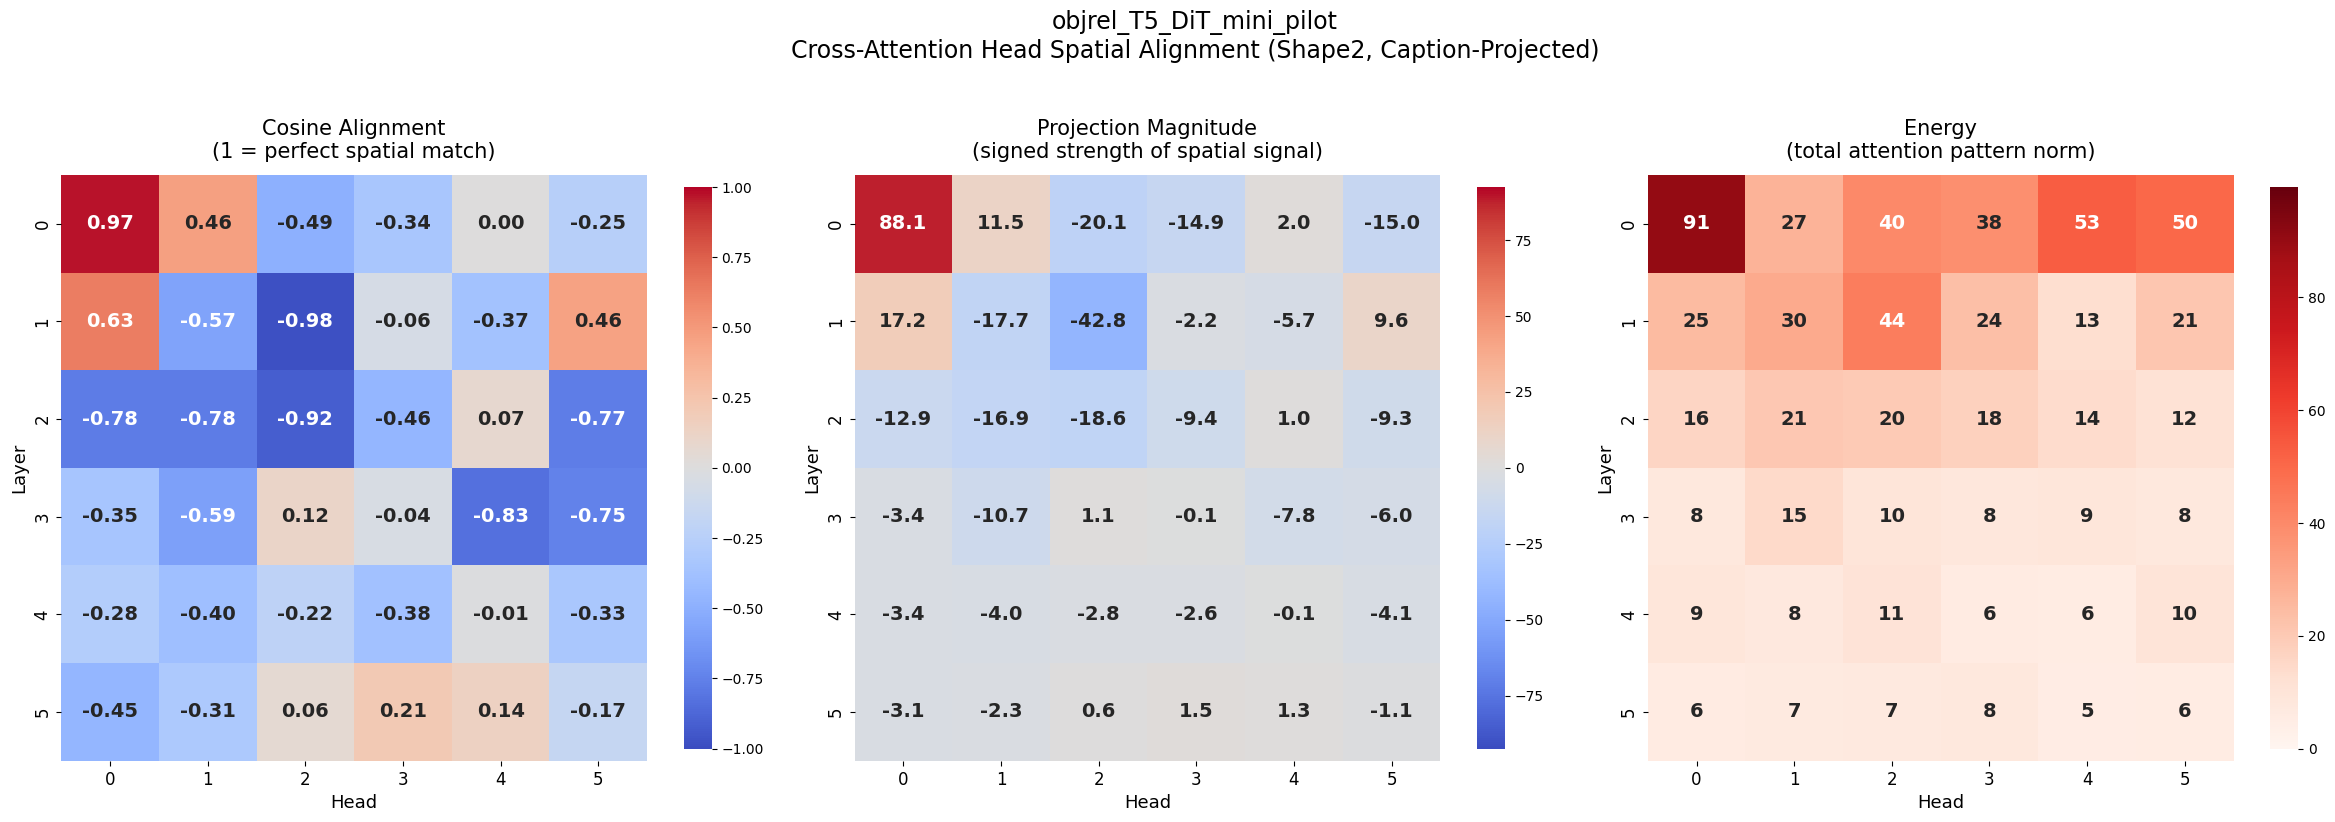

In [16]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape2_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

# Use data-driven color limits for projection so weak heads aren't washed out
proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

# Highlight top spatial heads
print("Top spatial heads (by |cosine| > 0.7):")
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        l, h = row.name
        print(f"  Layer {l}, Head {h}: cosine={row['cosine']:.2f}, proj={row['projection']:.1f}, energy={row['energy']:.0f}")

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape2, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape2_MLP_proj_rel_factor")
plt.show()

### Section C.1 - Shape1/Object1 Alignment Scan

Repeats the head-alignment computation for object1 (shape1) features to compare whether heads encode object identity vs spatial relation.

In [17]:
prompt_scene_info_all_df["color1shape1"] = prompt_scene_info_all_df["color1"] + "_" + prompt_scene_info_all_df["shape1"]
prompt_scene_info_all_df["color2shape2"] = prompt_scene_info_all_df["color2"] + "_" + prompt_scene_info_all_df["shape2"]
print("shape2, T5 embedding, caption projection")
var_part_df_S1, intercept_S1, effect_vecs_S1, levels_map_S1, R2_total_S1 = variance_partition_with_effects(wordvec_obj1_mat_proj.float().cpu().numpy(),
            {"spatial_relationship": prompt_scene_info_all_df["spatial_relationship"],
            #  "color1": prompt_scene_info_all_df["color1"],
            #  "shape1": prompt_scene_info_all_df["shape1"],
            #  "color2": prompt_scene_info_all_df["color2"],
             "shape2": prompt_scene_info_all_df["shape2"],
             "color1shape1": prompt_scene_info_all_df["color1shape1"],
            #  "color2shape2": prompt_scene_info_all_df["color2shape2"],
             },
            metric="euclidean",
            n_perm=100)
var_part_df_S1

shape2, T5 embedding, caption projection
Total R2 (all features): 0.670111
Total R² (all features): 0.6701


,feature,levels,df_effect,df_resid,SS_total,SSR_marginal,R2_marginal,SSR_partial,R2_partial,eta2_partial,p_partial_perm
0,color1shape1,6,5,249,10202.900793,4351.159422,0.426463,3799.699106,0.372414,0.530275,0.009901
1,spatial_relationship,8,7,249,10202.900793,1668.141067,0.163497,1668.141067,0.163497,0.331377,0.009901
2,shape2,3,2,249,10202.900793,1369.238377,0.134201,817.778060,0.080152,0.195472,0.009901


In [18]:
from tqdm import tqdm
from itertools import product
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
align_df_list = []
for layer_idx, head_idx in tqdm(product(range(layer_num), range(head_num))):
    target_embedding_direction = effect_vecs_S1["spatial_relationship"][:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
    inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T
    align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_S1["spatial_relationship"])
    align_df["layer_idx"] = layer_idx
    align_df["head_idx"] = head_idx
    align_df_list.append(align_df)
align_df_allheads_S1 = pd.concat(align_df_list)

0it [00:00, ?it/s]

36it [00:00, 275.40it/s]


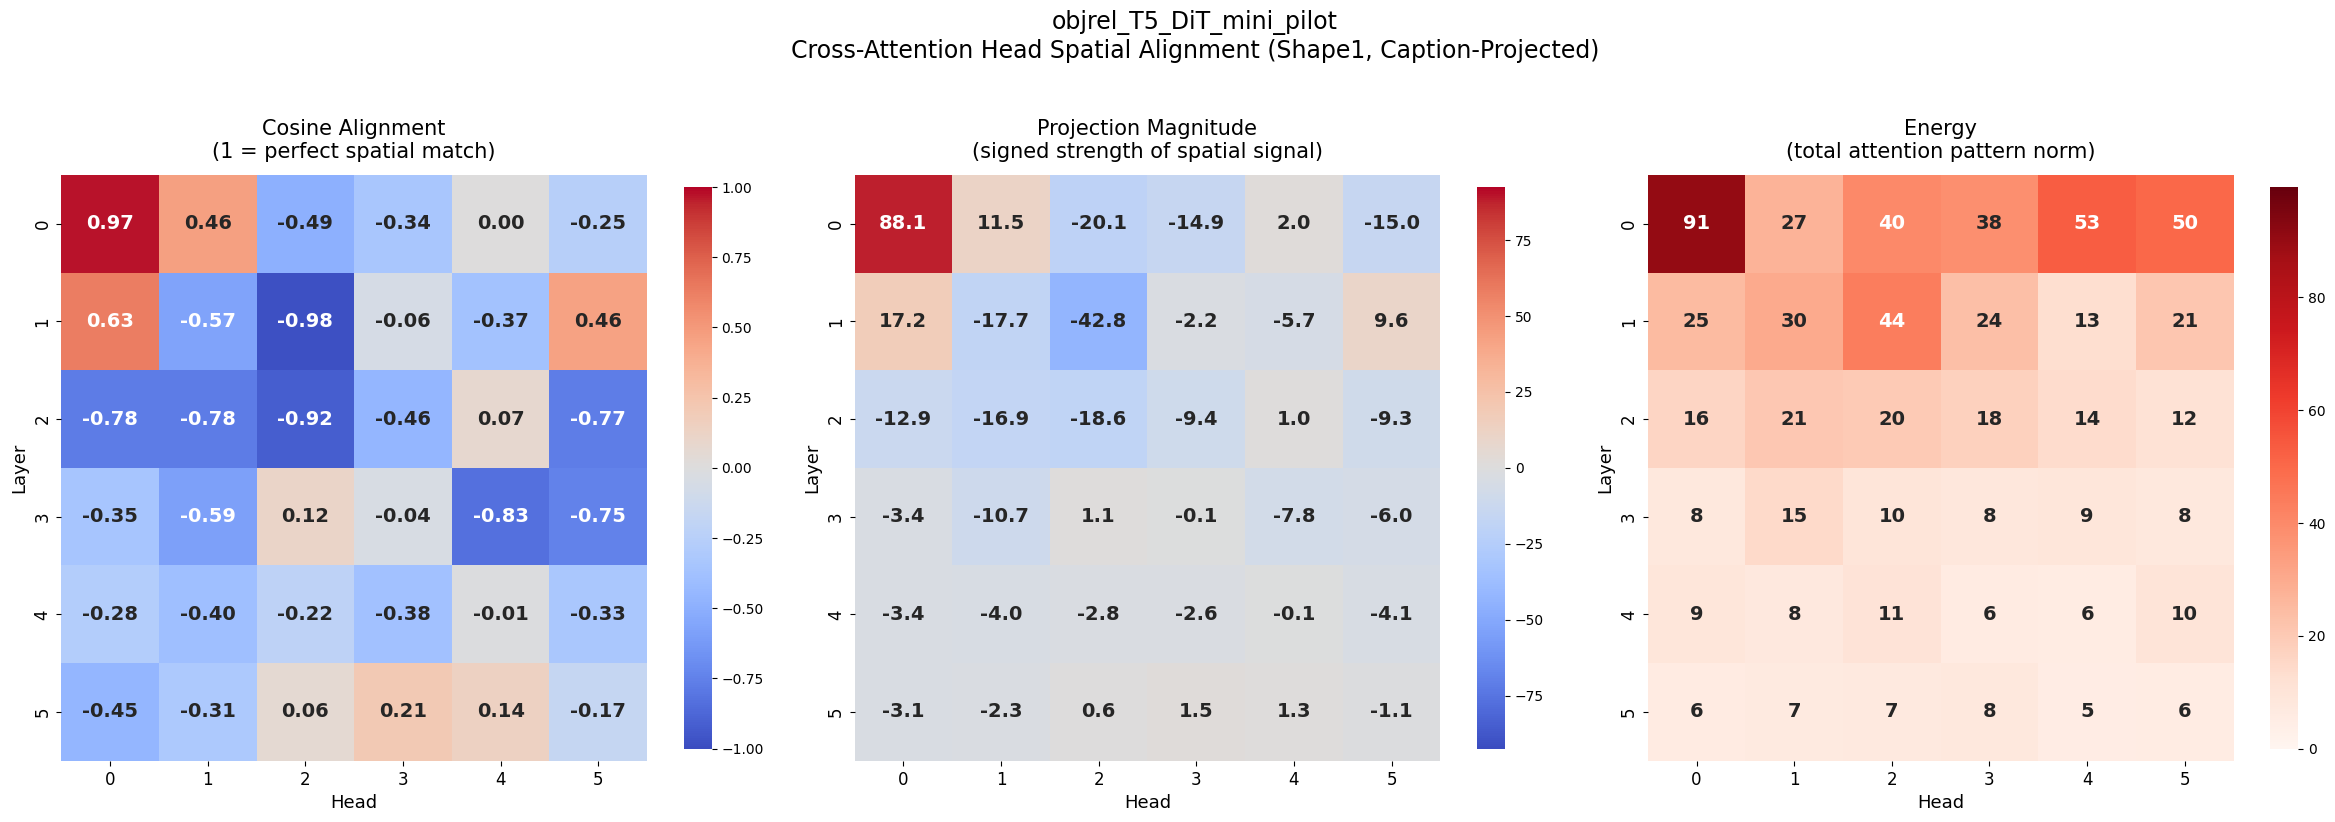

In [19]:
align_df_allheads.to_csv(join(figdir, f"{model_run_name}_align_score_allheads_shape1_MLP_proj_rel_factor.csv"), index=False)
head_align_synopsis = align_df_allheads.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)

metrics = ["cosine", "projection", "energy"]
titles = [
    "Cosine Alignment\n(1 = perfect spatial match)",
    "Projection Magnitude\n(signed strength of spatial signal)",
    "Energy\n(total attention pattern norm)",
]
n_metrics = len(metrics)

proj_max = max(abs(head_align_synopsis["projection"].min()), abs(head_align_synopsis["projection"].max()))
energy_max = head_align_synopsis["energy"].max()

fig, axes = plt.subplots(1, n_metrics, figsize=(8 * n_metrics, 8), squeeze=False)
for idx, metric, clim, fmt, title in zip(
    range(n_metrics), metrics,
    [(-1, 1), (-proj_max * 1.05, proj_max * 1.05), (0, energy_max * 1.1)],
    [".2f", ".1f", ".0f"],
    titles,
):
    heatmap_data = head_align_synopsis[metric].unstack(level="head_idx")
    ax = axes[0, idx]
    cmap = "Reds" if metric == "energy" else "coolwarm"
    sns.heatmap(
        heatmap_data, annot=True, fmt=fmt, cmap=cmap, ax=ax, cbar=True,
        vmin=clim[0], vmax=clim[1],
        annot_kws={"size": 14, "weight": "bold"},
        cbar_kws={"shrink": 0.8},
    )
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.tick_params(labelsize=12)

fig.suptitle(
    f"{model_run_name}\nCross-Attention Head Spatial Alignment (Shape1, Caption-Projected)",
    fontsize=17, y=1.03,
)
plt.tight_layout()
saveallforms(figdir, f"{model_run_name}_all_heads_align_score_synopsis_shape1_MLP_proj_rel_factor")
plt.show()

### Section C.2 - Selective Head Visualization

Generates focused plots for selected high-value heads/layers so you can quickly inspect spatial ramp structure without scanning all heads.

Text(0.5, 0.98, 'objrel_T5_DiT_mini_pilot\nL0H0 pos embed inner product with spatial relation factors in Caption Projection')

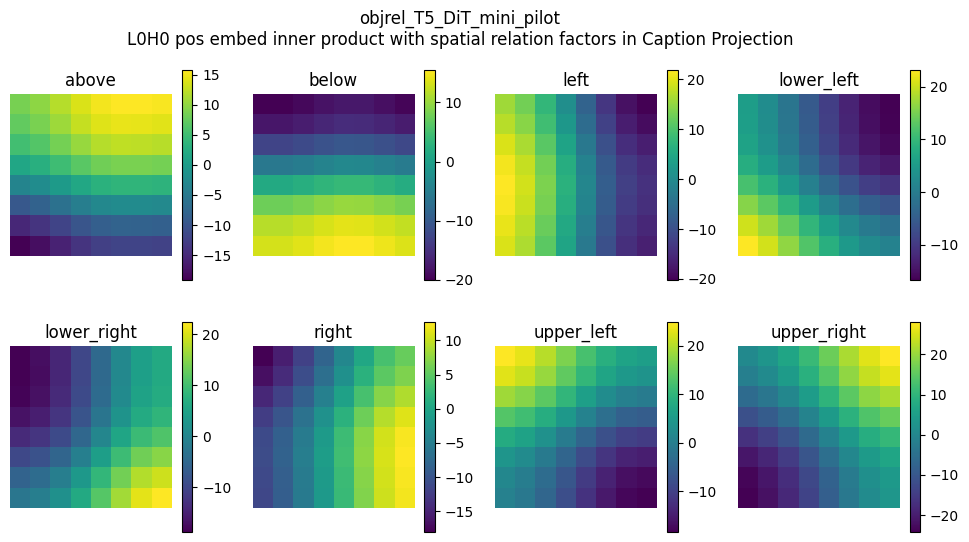

In [20]:
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num
# Pick a layer/head to inspect — update after seeing the heatmaps above
layer_idx, head_idx = 0,0
target_embedding_direction = effect_vecs["spatial_relationship"][:, :]
target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
word_embed_2k_h8 = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
pos_embed_2q_h8 = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
inner_prod_mat = pos_embed_2q_h8 @ word_embed_2k_h8.T

fig, axs = plt.subplots(2, 4, figsize=(12, 6))
axs = axs.flatten()
for i_word in range(len(effect_vecs["spatial_relationship"])):
    plt.sca(axs[i_word])
    attn_score = inner_prod_mat[:, i_word:i_word+1]
    plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
    plt.title(f"{levels_map['spatial_relationship'][i_word]}")
    plt.axis("off")
    plt.colorbar()
plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with spatial relation factors in Caption Projection")

In [21]:
from utils.pixart_utils import PixArt_model_configs
def compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, feature_vecs, levels_names=None, 
                                   model_run_name="model", device=device, visualize=True):
    """
    Visualize the inner product between 2D positional embeddings and target effect vectors for specified head/layer.
    """
    transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
    hidden_size = transformer_config["hidden_size"]
    head_num = transformer_config["num_heads"]
    layer_num = transformer_config["depth"]
    base_size = 16 // 2
    head_dim = hidden_size // head_num

    target_embedding_direction = feature_vecs[:, :]
    target_embedding_direction = torch.from_numpy(target_embedding_direction)[None, :].to(dtype=compute_dtype, device=device)
    word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_embedding_direction)
    word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
    pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
    pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
    pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]

    inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
    if visualize:
        num_levels = len(feature_vecs)
        nrows, ncols = (2, 4) if num_levels == 8 else (1, num_levels)
        fig, axs = plt.subplots(nrows, ncols, figsize=(12, 6))
        axs = axs.flatten() if hasattr(axs, "flatten") else [axs]

        for i_word in range(num_levels):
            plt.sca(axs[i_word])
            attn_score = inner_prod_mat[:, i_word:i_word+1]
            plt.imshow(attn_score.view(8, 8).detach().cpu().numpy())
            if levels_names is not None:
                plt.title(f"{levels_names[i_word]}")
            else:
                plt.title(f"{i_word}")
            plt.axis("off")
            plt.colorbar()
        plt.suptitle(f"{model_run_name}\nL{layer_idx}H{head_idx} pos embed inner product with {len(feature_vecs)} factors in Caption Projection")
        plt.tight_layout()
        plt.show()
    else:
        fig = None
    return inner_prod_mat, fig

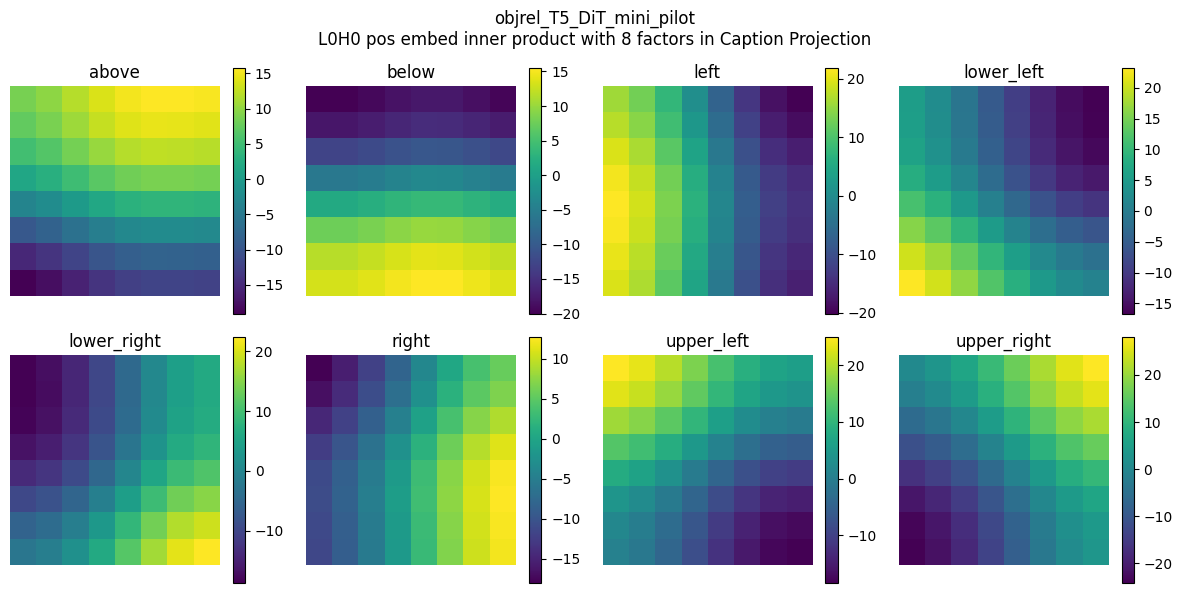

In [22]:
# Example: inspect the strongest spatial head
inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, 0, 0, 
                                 effect_vecs["spatial_relationship"], 
                                 levels_names=levels_map["spatial_relationship"], 
                                 model_run_name=model_run_name, 
                                 device=device, visualize=True);

Visualizing 8 top spatial heads: [(0, 0), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 4), (3, 5)]



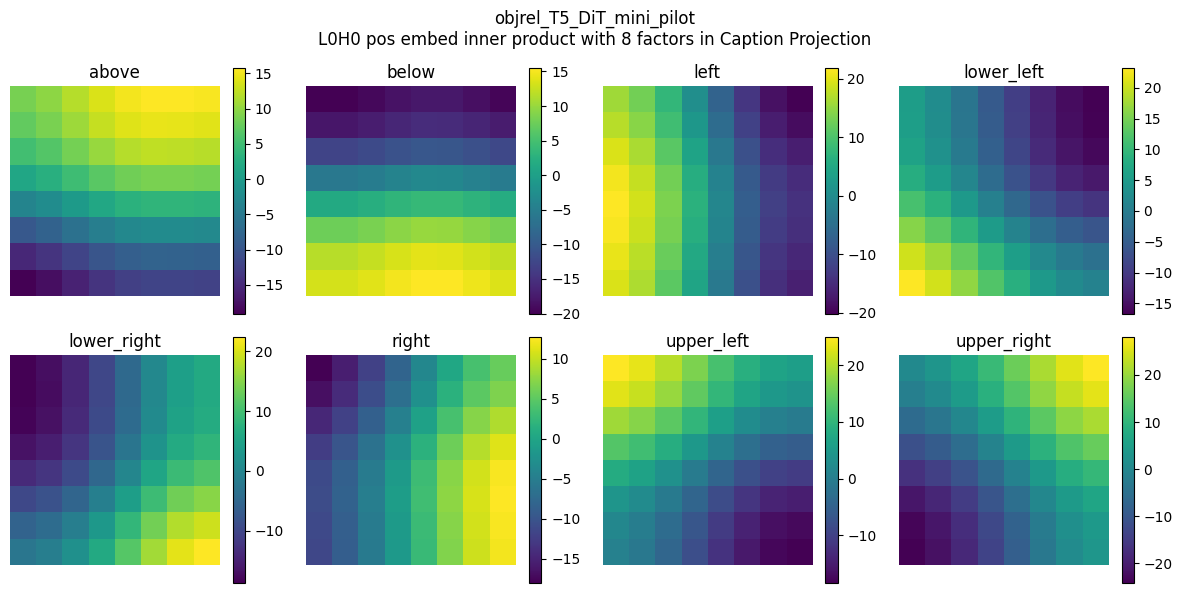

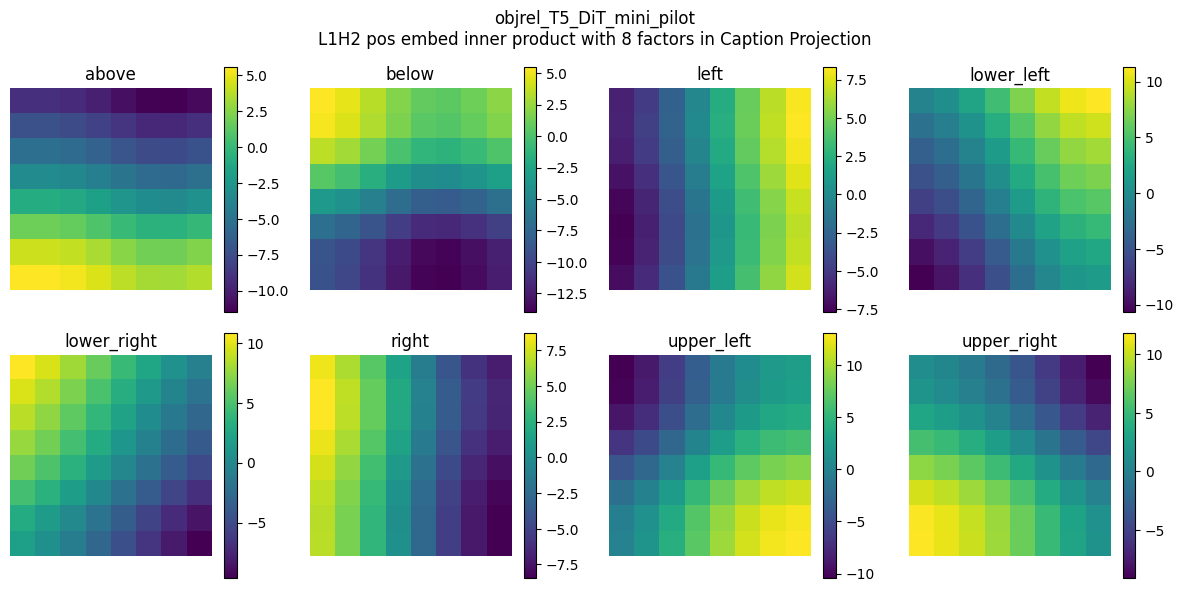

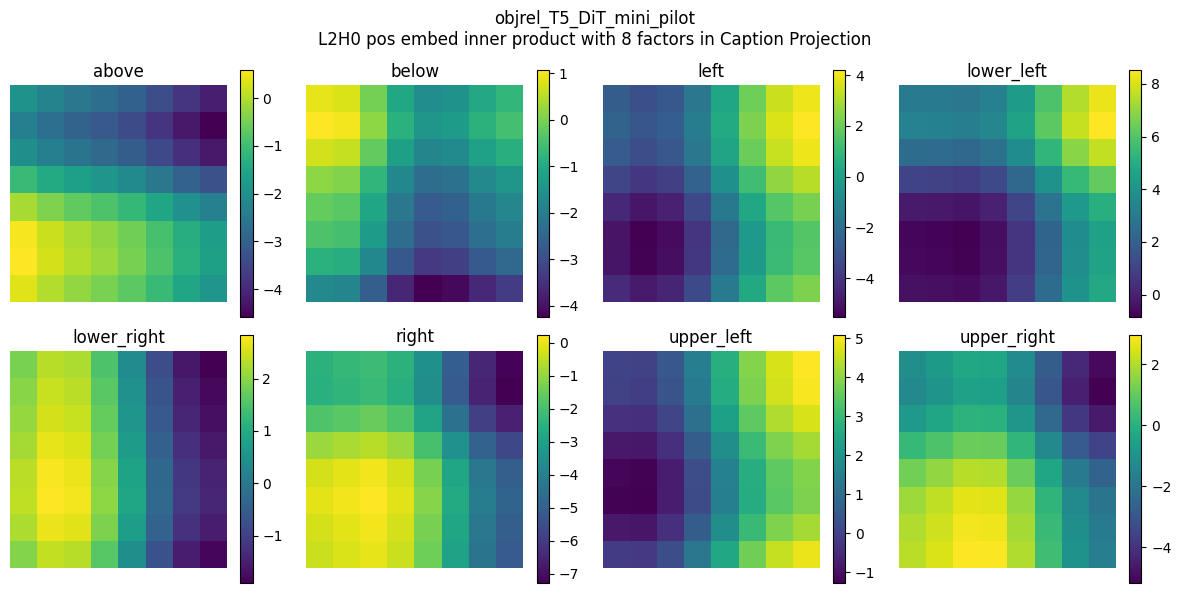

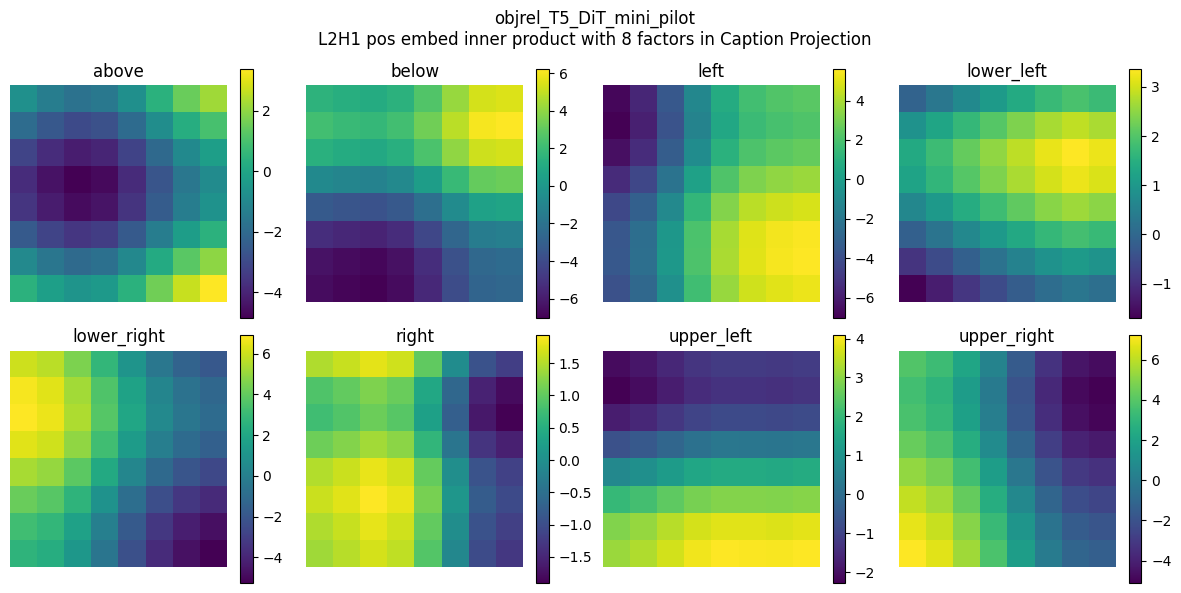

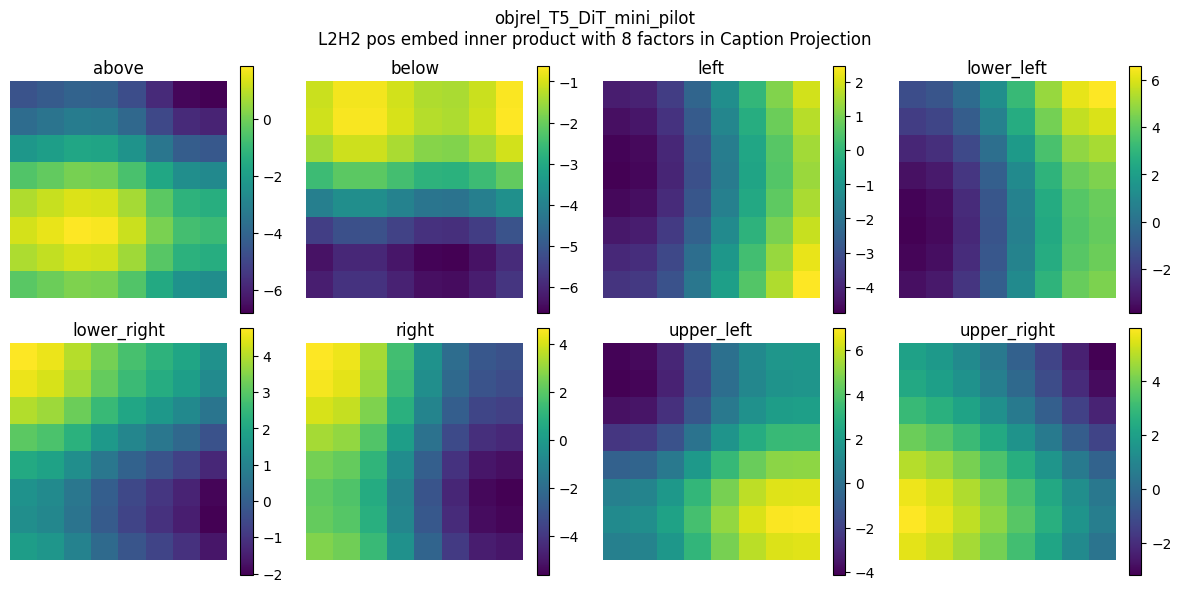

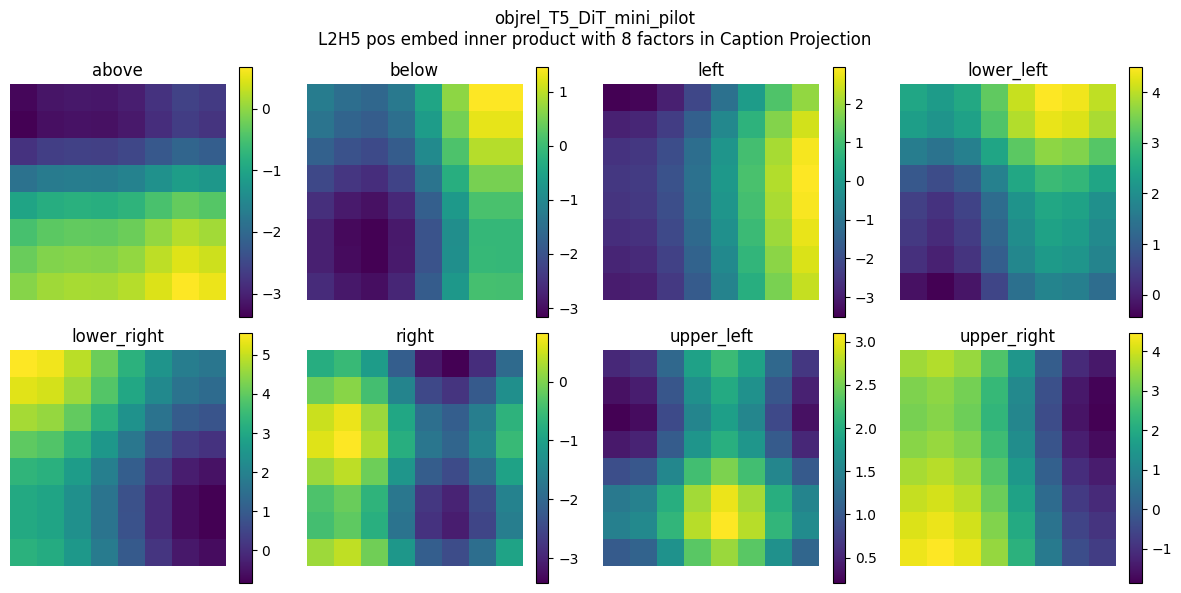

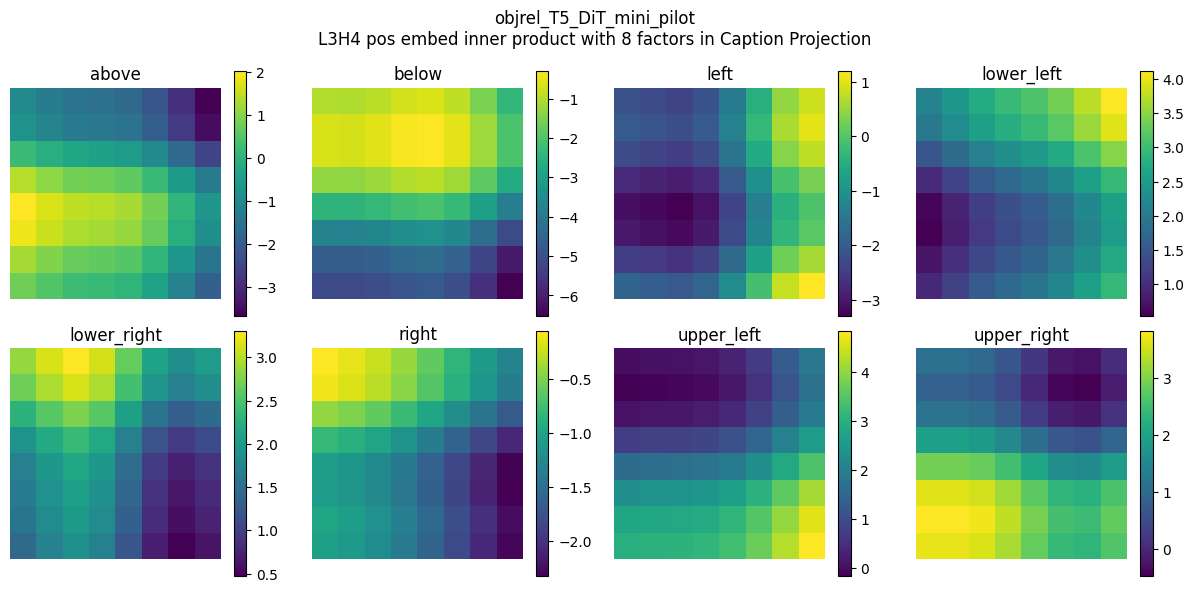

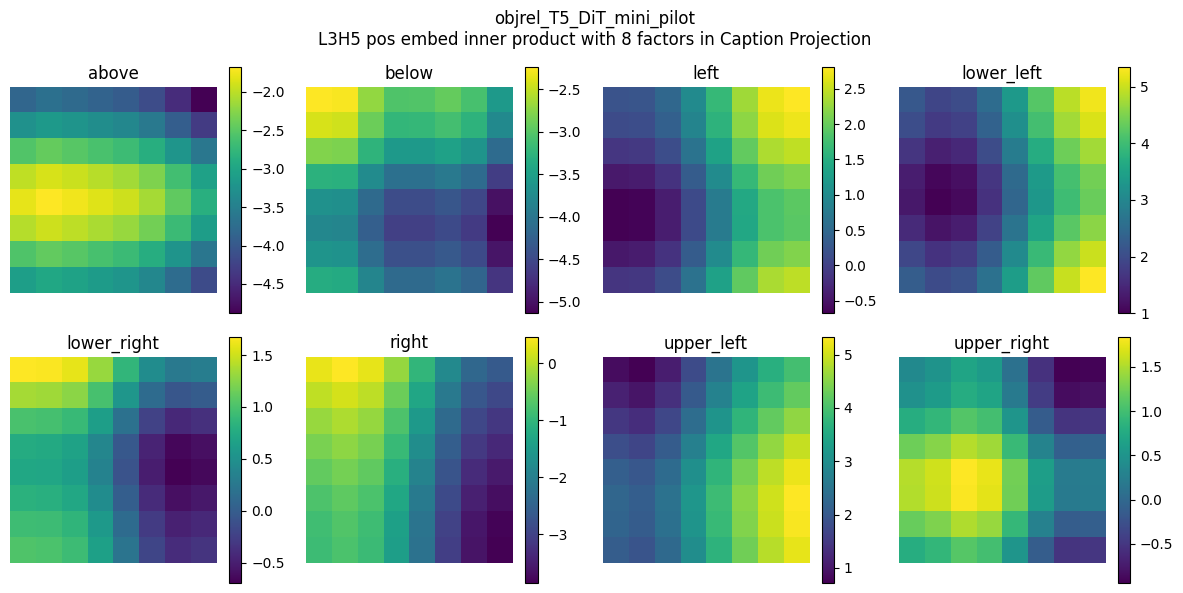

In [23]:
# Visualize the top spatial heads found from the heatmap above
# Pick heads with |cosine| > 0.7 automatically
top_heads = []
for _, row in head_align_synopsis.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append(row.name)  # (layer_idx, head_idx)

if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]  # fallback
    
print(f"Visualizing {len(top_heads)} top spatial heads: {top_heads}\n")
for layer_idx, head_idx in top_heads:
    inner_prod_mat, fig = compute_vis_pos_embed_inner_prod(pipeline, config, layer_idx, head_idx, 
                                     effect_vecs["spatial_relationship"], 
                                     levels_names=levels_map["spatial_relationship"], 
                                     model_run_name=model_run_name, 
                                     device=device, visualize=True);

### Trace spatial heads through training

**Goal:** See how cross-attention head spatial alignment evolves across checkpoints.

**Key insight:** T5 embeddings are frozen → same raw embeddings for all checkpoints.  
But the **caption projection (MLP)** and **cross-attention weights** are trained → we must:
1. Load each checkpoint
2. Project cached T5 embeddings through that checkpoint's caption_projection
3. Run variance partition on projected embeddings (effect_vecs differ per checkpoint)
4. Run head alignment using that checkpoint's attn2 weights + effect_vecs

In [24]:
# Define checkpoints to trace (epoch, step) and load order
ckpt_files = [
    "epoch_100_step_4000.pth",
    "epoch_250_step_10000.pth",
    "epoch_500_step_20000.pth",
    "epoch_1000_step_40000.pth",
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
# Fine-grained checkpoints for 500–1000 (relation head emergence)
ckpt_files_emergence = [
    "epoch_500_step_20000.pth",
    "epoch_600_step_24000.pth",
    "epoch_700_step_28000.pth",
    "epoch_750_step_30000.pth",
    "epoch_800_step_32000.pth",
    "epoch_900_step_36000.pth",
    "epoch_1000_step_40000.pth",
]
# Extended ablation: emergence + later checkpoints (2000, 4000) where relation head should be stronger
ckpt_files_ablation = ckpt_files_emergence + [
    "epoch_2000_step_80000.pth",
    "epoch_4000_step_160000.pth",
]
ckptdir = join(savedir, "checkpoints")
print(f"Full trace: {len(ckpt_files)} checkpoints | Emergence (500–1000): {len(ckpt_files_emergence)} | Ablation sweep: {len(ckpt_files_ablation)}")

Full trace: 6 checkpoints | Emergence (500–1000): 7 | Ablation sweep: 9


In [25]:
# For each checkpoint: load, project embeddings, variance partition, head alignment
# Results stored in evolution_records (list of DataFrames, one per checkpoint)

n_perm_evolution = 50  # Reduce for faster run (original uses 100)
evolution_records = []
var_part_evolution = []
q_norms_evolution = []
transformer_config = PixArt_model_configs[config.model]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

for ckpt_name in tqdm(ckpt_files, desc="Checkpoints"):
    # 1. Load checkpoint into transformer (reuse existing pipeline structure)
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    
    # 2. Project cached T5 embeddings through this checkpoint's caption_projection
    wordvec_obj1_col, wordvec_obj2_col = [], []
    for row in prompt_scene_info_all_df.itertuples():
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([token_id]) for token_id in tokenized['input_ids'][0]]
        shape1_mask_idx = find_shape_index(tokens, row.shape1)
        shape2_mask_idx = find_shape_index(tokens, row.shape2)
        wordvec_obj1_col.append(cap_embeds[0, shape1_mask_idx, :])
        wordvec_obj2_col.append(cap_embeds[0, shape2_mask_idx, :])
    wordvec_obj1_mat = torch.stack(wordvec_obj1_col, dim=0)
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj1_mat_proj = pipeline.transformer.caption_projection(wordvec_obj1_mat.to(dtype=compute_dtype, device=device))
        wordvec_obj2_mat_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    # 3. Variance partition on projected embeddings (Shape2)
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    var_part_df_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, R2_total_ckpt = variance_partition_with_effects(
        wordvec_obj2_mat_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    
    # 4. Head alignment for this checkpoint
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    
    align_df = pd.concat(align_df_list)
    head_synopsis = align_df.groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["checkpoint"] = ckpt_name
    epoch = int(ckpt_name.split("_")[1])
    head_synopsis["epoch"] = epoch
    evolution_records.append(head_synopsis.reset_index())
    
    # Variance partition: R² per factor (MLP-projected embedding)
    var_part_ckpt = var_part_df_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_ckpt["checkpoint"] = ckpt_name
    if ckpt_name == ckpt_files[0]:
        var_part_evolution = [var_part_ckpt]
    else:
        var_part_evolution.append(var_part_ckpt)
    
    # Q weight norms per head (cross-attention projection)
    q_norms_ckpt = []
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_ckpt.append({
                "epoch": epoch, "checkpoint": ckpt_name,
                "layer_idx": layer_idx, "head_idx": head_idx,
                "q_norm": q_heads[head_idx].norm().item(),
            })
    if ckpt_name == ckpt_files[0]:
        q_norms_evolution = q_norms_ckpt
    else:
        q_norms_evolution.extend(q_norms_ckpt)

Checkpoints:  17%|█▋        | 1/6 [00:00<00:03,  1.50it/s]

Total R² (all features): 0.9242


Checkpoints:  33%|███▎      | 2/6 [00:01<00:02,  1.62it/s]

Total R² (all features): 0.9872


Checkpoints:  50%|█████     | 3/6 [00:01<00:01,  1.58it/s]

...

Total R² (all features): 0.9164


Checkpoints:  83%|████████▎ | 5/6 [00:02<00:00,  1.89it/s]

Total R² (all features): 0.7561


Checkpoints: 100%|██████████| 6/6 [00:03<00:00,  1.76it/s]

Total R² (all features): 0.6200


In [26]:
# Combine all checkpoint results into one evolution DataFrame
evolution_df = pd.concat(evolution_records, ignore_index=True)
evolution_df = evolution_df.sort_values(["epoch", "layer_idx", "head_idx"]).reset_index(drop=True)

var_part_evolution = globals().get('var_part_evolution', [])
q_norms_evolution = globals().get('q_norms_evolution', [])
var_part_df_evolution = pd.concat(var_part_evolution, ignore_index=True) if var_part_evolution else pd.DataFrame()
q_norms_df = pd.DataFrame(q_norms_evolution) if q_norms_evolution else pd.DataFrame()

print(evolution_df.head(6))
print(f"\nEvolution: {len(evolution_df)} rows | Var partition: {len(var_part_df_evolution)} rows | Q norms: {len(q_norms_df)} rows")
if var_part_df_evolution.empty or q_norms_df.empty:
    print("\n⚠ Run the evolution loop (cell above) first to populate var_part_evolution and q_norms_evolution.")

   layer_idx  head_idx    cosine  projection    energy  template_norm  \
0          0         0  0.001878    0.002187  0.089832       5.237229   
1          0         1 -0.270953   -0.010534  0.039081       5.237229   
2          0         2 -0.038505   -0.001391  0.043750       5.237229   
3          0         3 -0.064451   -0.002204  0.074277       5.237229   
4          0         4  0.015534    0.005103  0.061470       5.237229   
5          0         5  0.010048   -0.000948  0.068425       5.237229   

   dir_idx               checkpoint  epoch  
0      3.5  epoch_100_step_4000.pth    100  
1      3.5  epoch_100_step_4000.pth    100  
2      3.5  epoch_100_step_4000.pth    100  
3      3.5  epoch_100_step_4000.pth    100  
4      3.5  epoch_100_step_4000.pth    100  
5      3.5  epoch_100_step_4000.pth    100  

Evolution: 216 rows | Var partition: 18 rows | Q norms: 216 rows


#### Evolution of key spatial heads over training

Plot cosine, projection, and energy for the top heads (e.g., L0H0, L1H2) across epochs.

Plotting evolution for: [(0, 0), (1, 2), (2, 0), (2, 1), (2, 2), (2, 5), (3, 4), (3, 5)]


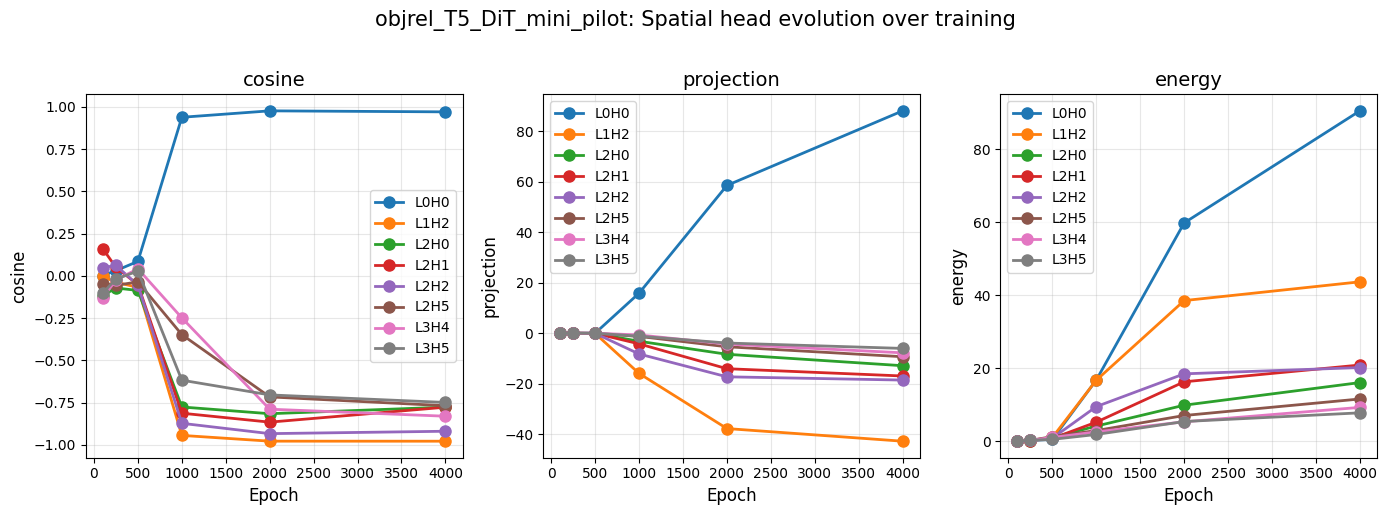

In [27]:
# Plot evolution of top spatial heads (auto-pick from final checkpoint |cosine| > 0.7)
final_ckpt = evolution_df[evolution_df["epoch"] == evolution_df["epoch"].max()]
top_heads = []
for _, row in final_ckpt.iterrows():
    if abs(row["cosine"]) > 0.7:
        top_heads.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_heads:
    top_heads = [(0, 0), (1, 2), (2, 3)]
print(f"Plotting evolution for: {top_heads}")

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["cosine", "projection", "energy"]):
    for layer_idx, head_idx in top_heads:
        subset = evolution_df[(evolution_df["layer_idx"] == layer_idx) & (evolution_df["head_idx"] == head_idx)]
        ax.plot(subset["epoch"], subset[metric], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=8)
    ax.set_xlabel("Epoch", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Spatial head evolution over training", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

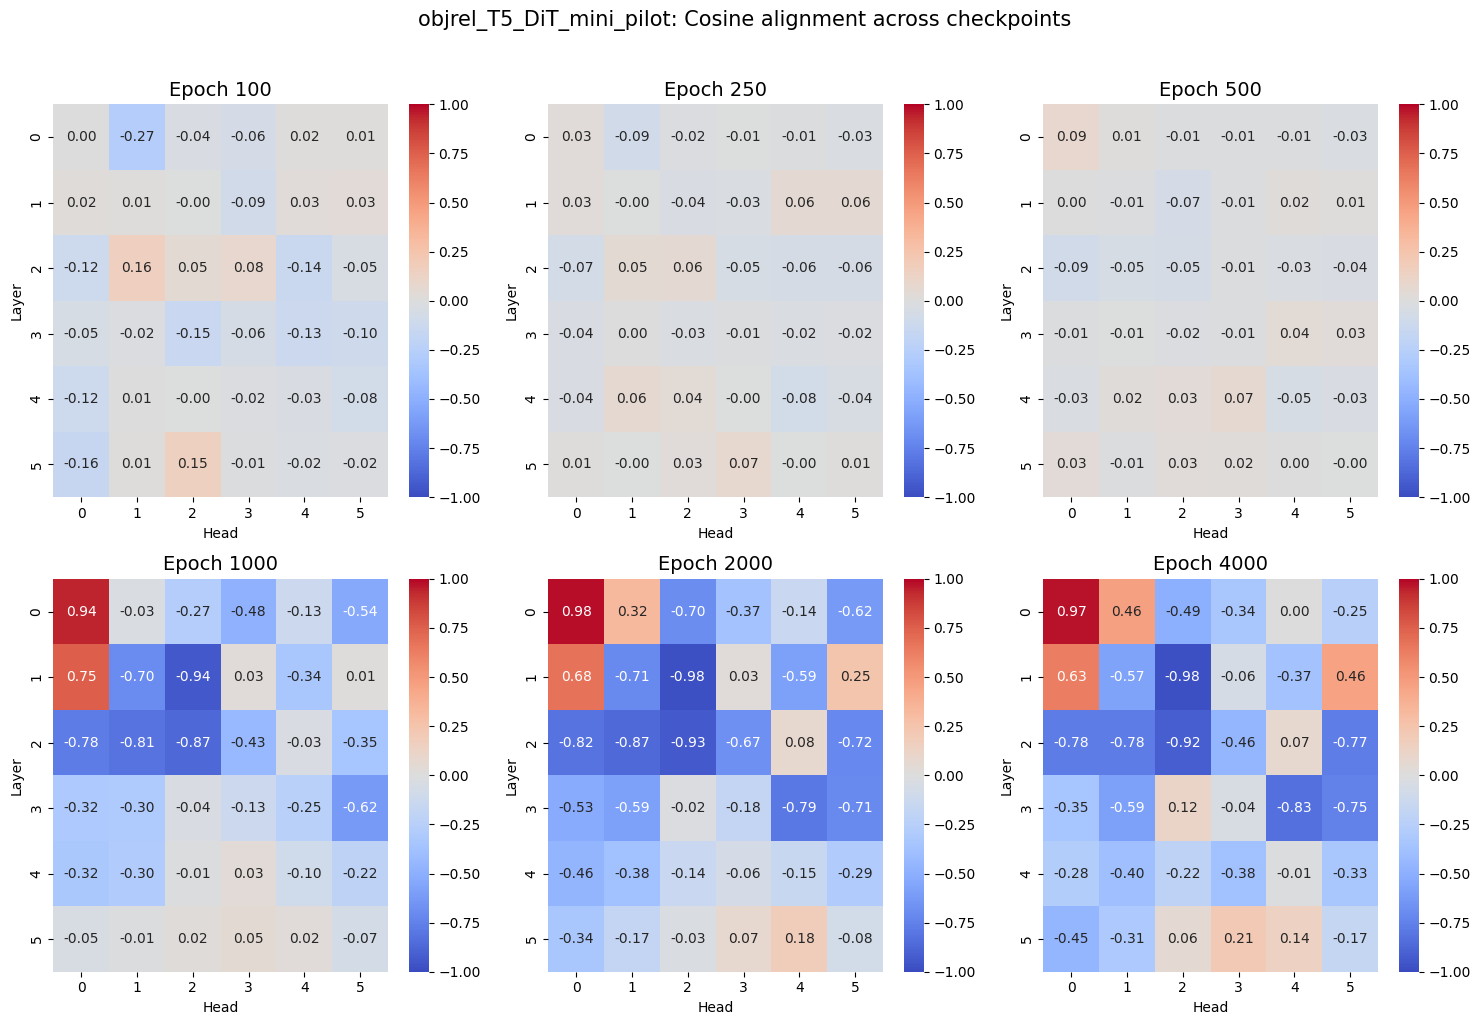

In [28]:
# Cosine alignment heatmaps across all checkpoints
epochs = sorted(evolution_df["epoch"].unique())
n_ckpts = len(epochs)
ncols = 3
nrows = (n_ckpts + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

for idx, epoch in enumerate(epochs):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df[evolution_df["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")

for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)

plt.suptitle(f"{model_run_name}: Cosine alignment across checkpoints", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Heatmap comparison: early vs late checkpoint

Cosine alignment heatmaps at epoch 100 vs epoch 4000.

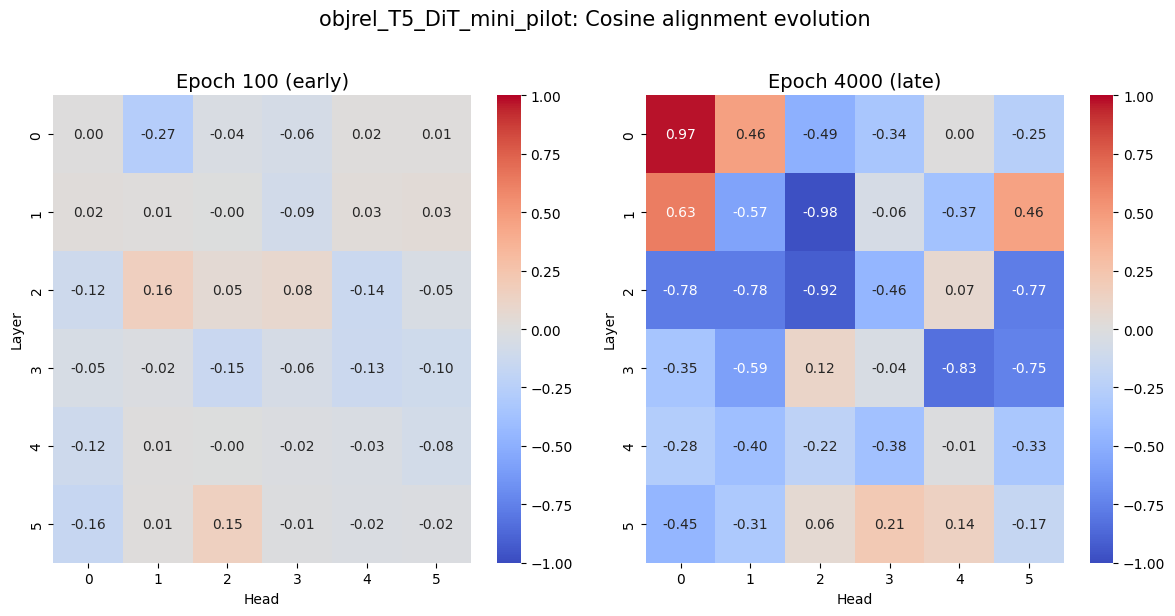

In [29]:
# Early vs late checkpoint — cosine alignment heatmaps
early = evolution_df[evolution_df["epoch"] == 100]
late = evolution_df[evolution_df["epoch"] == 4000]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, df_sub, title in [
    (axes[0], early, "Epoch 100 (early)"),
    (axes[1], late, "Epoch 4000 (late)"),
]:
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
plt.suptitle(f"{model_run_name}: Cosine alignment evolution", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

#### Fixed relation direction (from final checkpoint)

Same cosine alignment, but using the spatial_relationship effect vectors from the **final checkpoint only** — the relation direction is fixed; only the attn2 weights change across checkpoints.

Total R² (all features): 0.6200


Fixed direction: 100%|██████████| 6/6 [00:02<00:00,  2.80it/s]


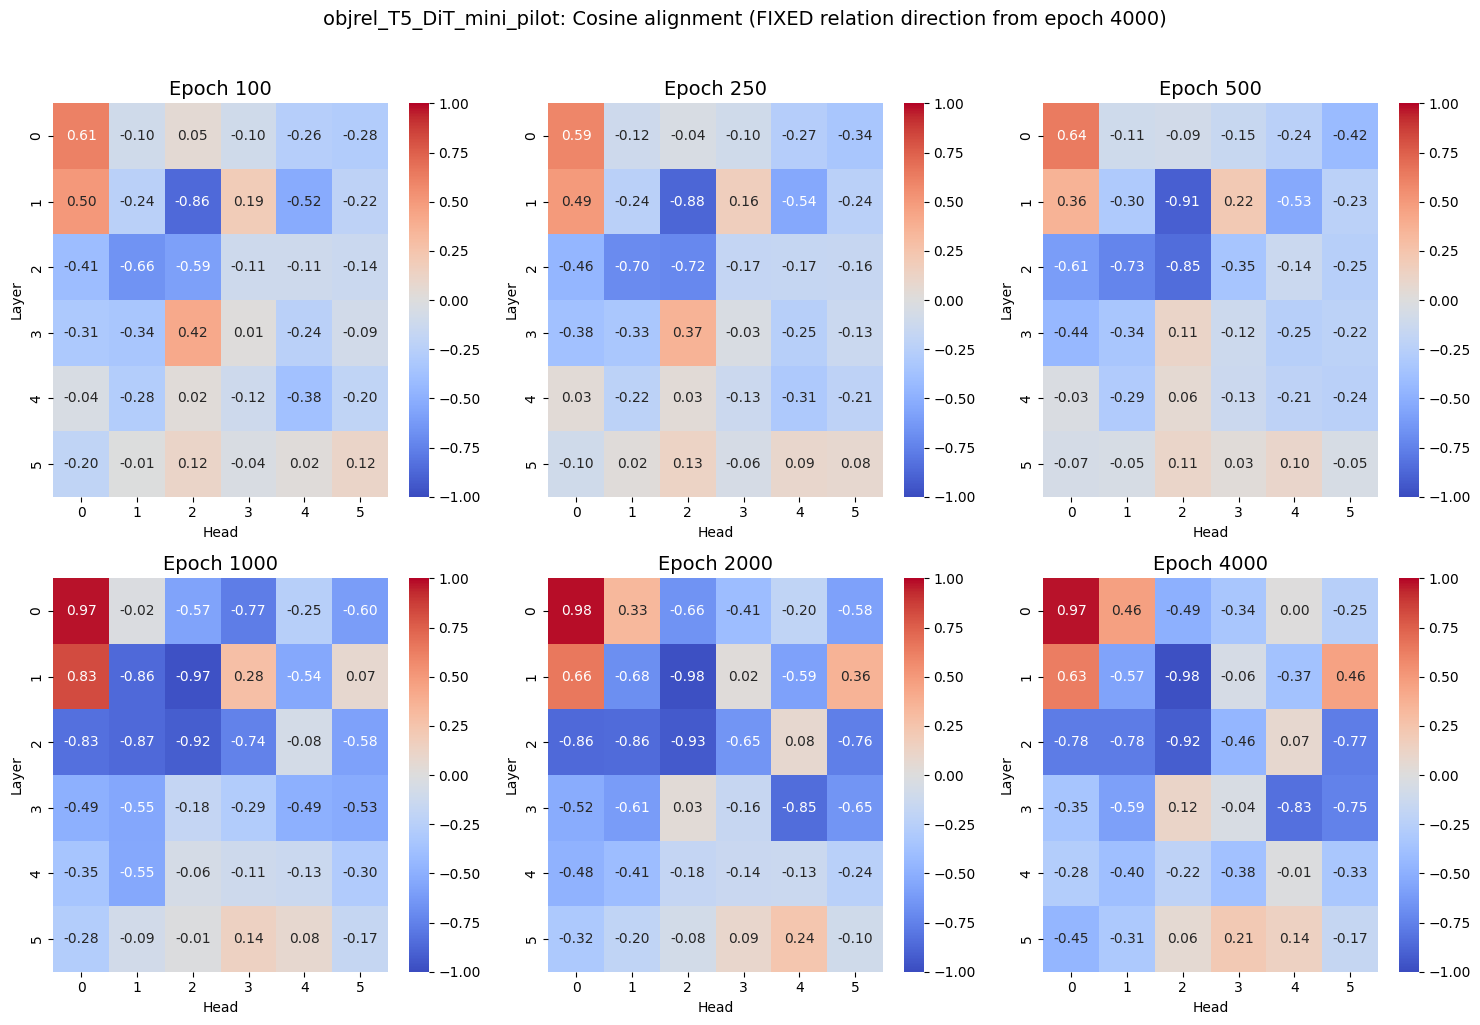

14017

In [30]:
# 1. Get fixed relation direction from final checkpoint
ckpt_final = "epoch_4000_step_160000.pth"
ckpt = torch.load(join(ckptdir, ckpt_final), map_location="cpu", weights_only=False)
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

# Project embeddings, variance partition → fixed effect_vecs
df_tmp = prompt_scene_info_all_df.copy()
df_tmp["color1shape1"] = df_tmp["color1"] + "_" + df_tmp["shape1"]
df_tmp["color2shape2"] = df_tmp["color2"] + "_" + df_tmp["shape2"]
wordvec_obj2_col = []
for row in prompt_scene_info_all_df.itertuples():
    tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
    tokens = [pipeline.tokenizer.decode([t]) for t in tokenized['input_ids'][0]]
    shape2_idx = find_shape_index(tokens, row.shape2)
    cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
    wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
with torch.no_grad():
    wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
_, _, effect_vecs_fixed, levels_map_fixed, _ = variance_partition_with_effects(
    wordvec_obj2_proj.float().cpu().numpy(),
    {"spatial_relationship": df_tmp["spatial_relationship"], "shape1": df_tmp["shape1"], "color2shape2": df_tmp["color2shape2"]},
    metric="euclidean", n_perm=n_perm_evolution, verbose=False)

# 2. For each checkpoint: load attn2, compute alignment with FIXED effect_vecs
evolution_records_fixed = []
for ckpt_name in tqdm(ckpt_files, desc="Fixed direction"):
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    epoch = int(ckpt_name.split("_")[1])
    
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_fixed["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_fixed["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    head_synopsis = pd.concat(align_df_list).groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["epoch"] = epoch
    head_synopsis["checkpoint"] = ckpt_name
    evolution_records_fixed.append(head_synopsis.reset_index())

evolution_df_fixed = pd.concat(evolution_records_fixed, ignore_index=True)

# 3. Plot heatmaps (same layout as above)
epochs_f = sorted(evolution_df_fixed["epoch"].unique())
n_ckpts = len(epochs_f)
ncols, nrows = 3, (n_ckpts + 2) // 3
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)
for idx, epoch in enumerate(epochs_f):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df_fixed[evolution_df_fixed["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment (FIXED relation direction from epoch 4000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Reload final checkpoint for downstream cells
ckpt = torch.load(join(ckptdir, ckpt_final), map_location="cpu", weights_only=False)
pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

### Relation head emergence (epochs 500–1000)

Fine-grained view using checkpoints 500, 600, 700, 750, 800, 900, 1000 — where the spatial relation head becomes identifiable.

In [31]:
# Run evolution for emergence checkpoints only (500–1000)
# Uses same config as main loop (layer_num, head_num, etc. from cell 32)
transformer_config = PixArt_model_configs[config.model] if config is not None else PixArt_model_configs["PixArt_mini_2"]
hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

evo_em_records, var_part_em, q_norms_em = [], [], []
for ckpt_name in tqdm(ckpt_files_emergence, desc="Emergence checkpoints"):
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt['state_dict_ema']))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()
    epoch = int(ckpt_name.split("_")[1])
    df = prompt_scene_info_all_df.copy()
    df["color1shape1"] = df["color1"] + "_" + df["shape1"]
    df["color2shape2"] = df["color2"] + "_" + df["shape2"]
    
    wordvec_obj2_col = []
    for row in prompt_scene_info_all_df.itertuples():
        tokenized = pipeline.tokenizer(row.prompt, max_length=20, padding="max_length", truncation=True, return_tensors="pt")
        tokens = [pipeline.tokenizer.decode([t]) for t in tokenized['input_ids'][0]]
        shape2_idx = find_shape_index(tokens, row.shape2)
        cap_embeds = embedding_allrel_allobj[f"base::{row.prompt}"]['caption_embeds']
        wordvec_obj2_col.append(cap_embeds[0, shape2_idx, :])
    wordvec_obj2_mat = torch.stack(wordvec_obj2_col, dim=0)
    with torch.no_grad():
        wordvec_obj2_proj = pipeline.transformer.caption_projection(wordvec_obj2_mat.to(dtype=compute_dtype, device=device))
    
    var_part_ckpt, _, effect_vecs_ckpt, levels_map_ckpt, _ = variance_partition_with_effects(
        wordvec_obj2_proj.float().cpu().numpy(),
        {"spatial_relationship": df["spatial_relationship"], "shape1": df["shape1"], "color2shape2": df["color2shape2"]},
        metric="euclidean", n_perm=n_perm_evolution, verbose=False)
    var_part_ckpt = var_part_ckpt.copy()
    var_part_ckpt["epoch"] = epoch
    var_part_em.append(var_part_ckpt)
    
    align_df_list = []
    for layer_idx, head_idx in product(range(layer_num), range(head_num)):
        target = torch.from_numpy(effect_vecs_ckpt["spatial_relationship"][:, :])[None, :].to(dtype=compute_dtype, device=device)
        word_embed_2k = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target)
        word_embed_2k_h = word_embed_2k[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        pos_embed = get_2d_sincos_pos_embed(hidden_size, (base_size, base_size), base_size=base_size)
        pos_embed = torch.from_numpy(pos_embed).unsqueeze(0).to(torch.float32).to(device)
        pos_embed_2q = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(pos_embed.to(dtype=compute_dtype, device=device))
        pos_embed_2q_h = pos_embed_2q[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
        inner_prod_mat = pos_embed_2q_h @ word_embed_2k_h.T
        align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_ckpt["spatial_relationship"])
        align_df["layer_idx"] = layer_idx
        align_df["head_idx"] = head_idx
        align_df_list.append(align_df)
    head_synopsis = pd.concat(align_df_list).groupby(["layer_idx", "head_idx"]).mean(numeric_only=True)
    head_synopsis["epoch"] = epoch
    head_synopsis["checkpoint"] = ckpt_name
    evo_em_records.append(head_synopsis.reset_index())
    
    for layer_idx in range(layer_num):
        q_w = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q.weight.float()
        q_heads = q_w.view(head_num, head_dim, -1)
        for head_idx in range(head_num):
            q_norms_em.append({"epoch": epoch, "layer_idx": layer_idx, "head_idx": head_idx, "q_norm": q_heads[head_idx].norm().item()})

evolution_df_em = pd.concat(evo_em_records, ignore_index=True)
var_part_df_em = pd.concat(var_part_em, ignore_index=True)
q_norms_df_em = pd.DataFrame(q_norms_em)
print(f"Emergence data: {len(evolution_df_em)} alignment rows, {len(var_part_df_em)} var partition rows")

Emergence checkpoints:   0%|          | 0/7 [00:00<?, ?it/s]

Emergence checkpoints:  14%|█▍        | 1/7 [00:00<00:02,  2.71it/s]

Total R² (all features): 0.9828


Emergence checkpoints:  29%|██▊       | 2/7 [00:01<00:02,  1.70it/s]

Total R² (all features): 0.9753


...

Total R² (all features): 0.9510


Emergence checkpoints:  86%|████████▌ | 6/7 [00:03<00:00,  1.75it/s]

Total R² (all features): 0.9346


Emergence checkpoints: 100%|██████████| 7/7 [00:03<00:00,  1.81it/s]

Total R² (all features): 0.9164
Emergence data: 252 alignment rows, 21 var partition rows


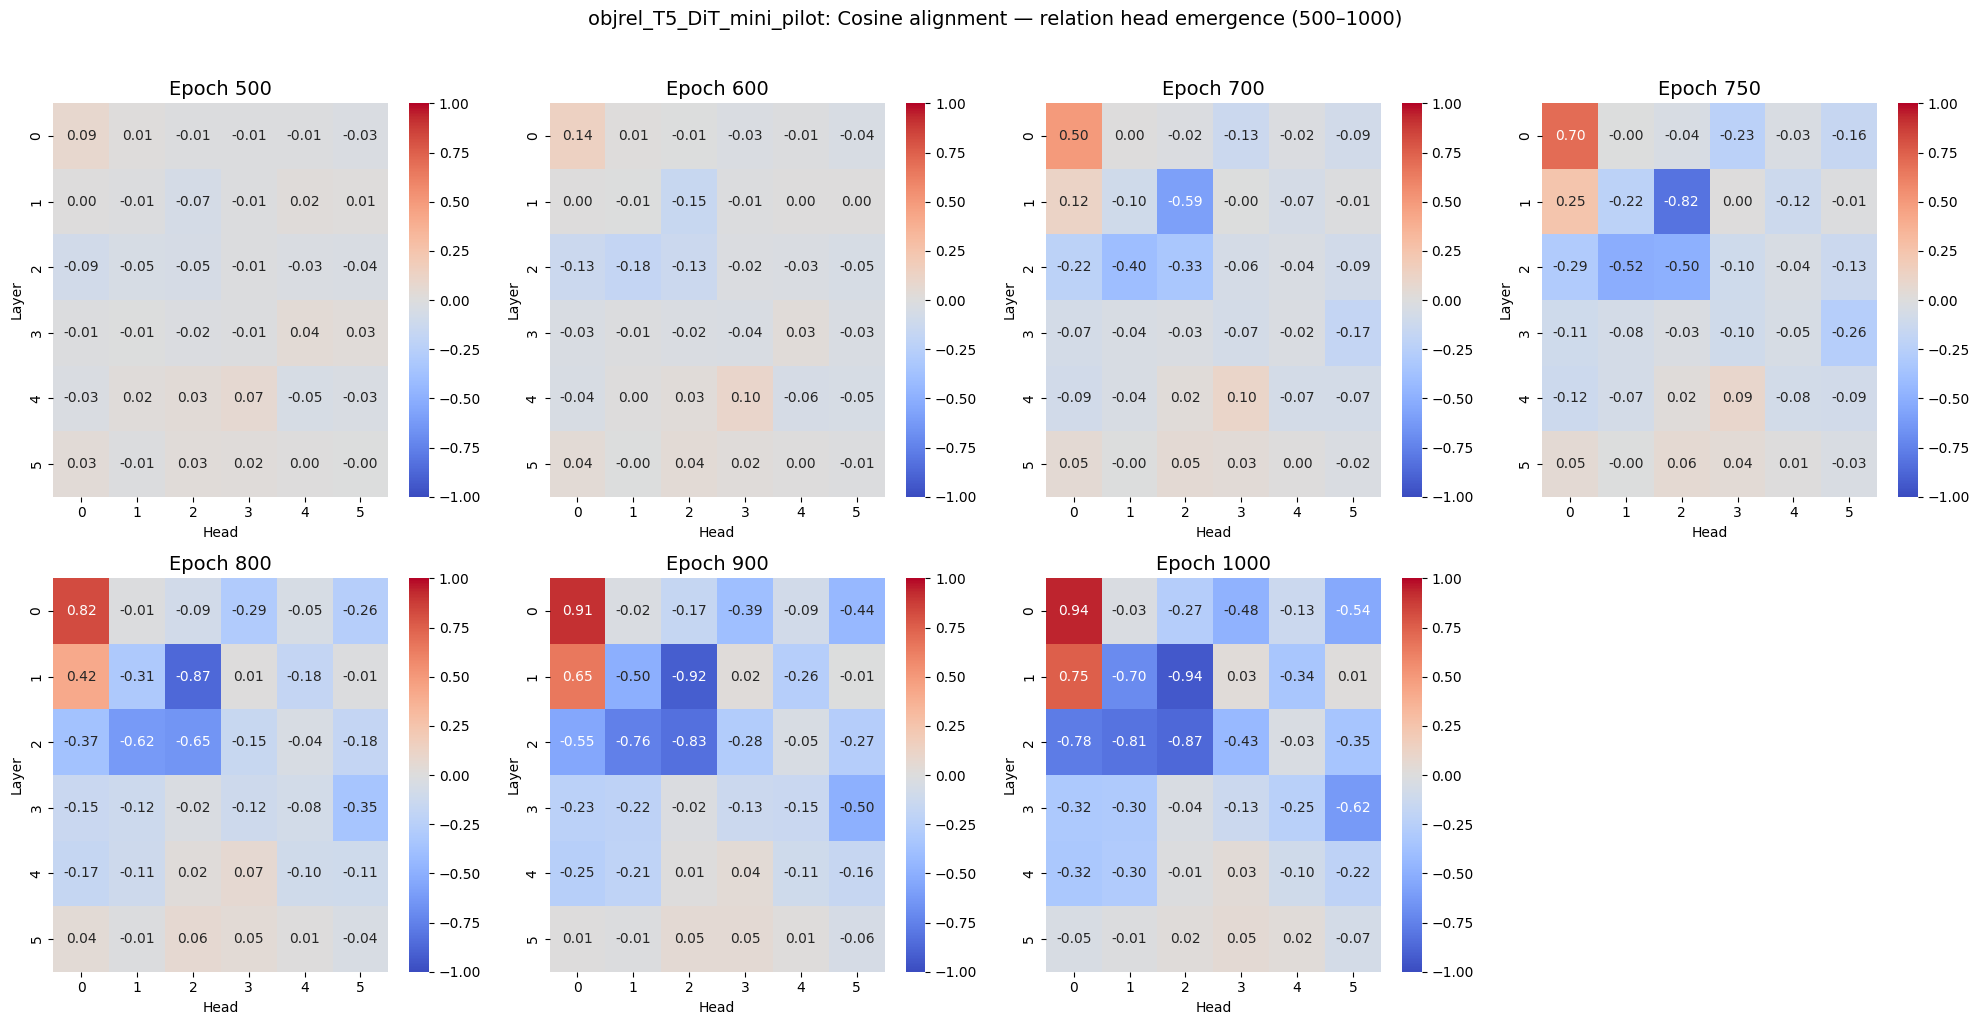

In [32]:
# Cosine alignment heatmaps: 500–1000 (relation head emergence)
epochs_em = sorted(evolution_df_em["epoch"].unique())
n_ckpts = len(epochs_em)
ncols = 4
nrows = (n_ckpts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)
for idx, epoch in enumerate(epochs_em):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")
    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, vmin=-1, vmax=1, cbar=True)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment — relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

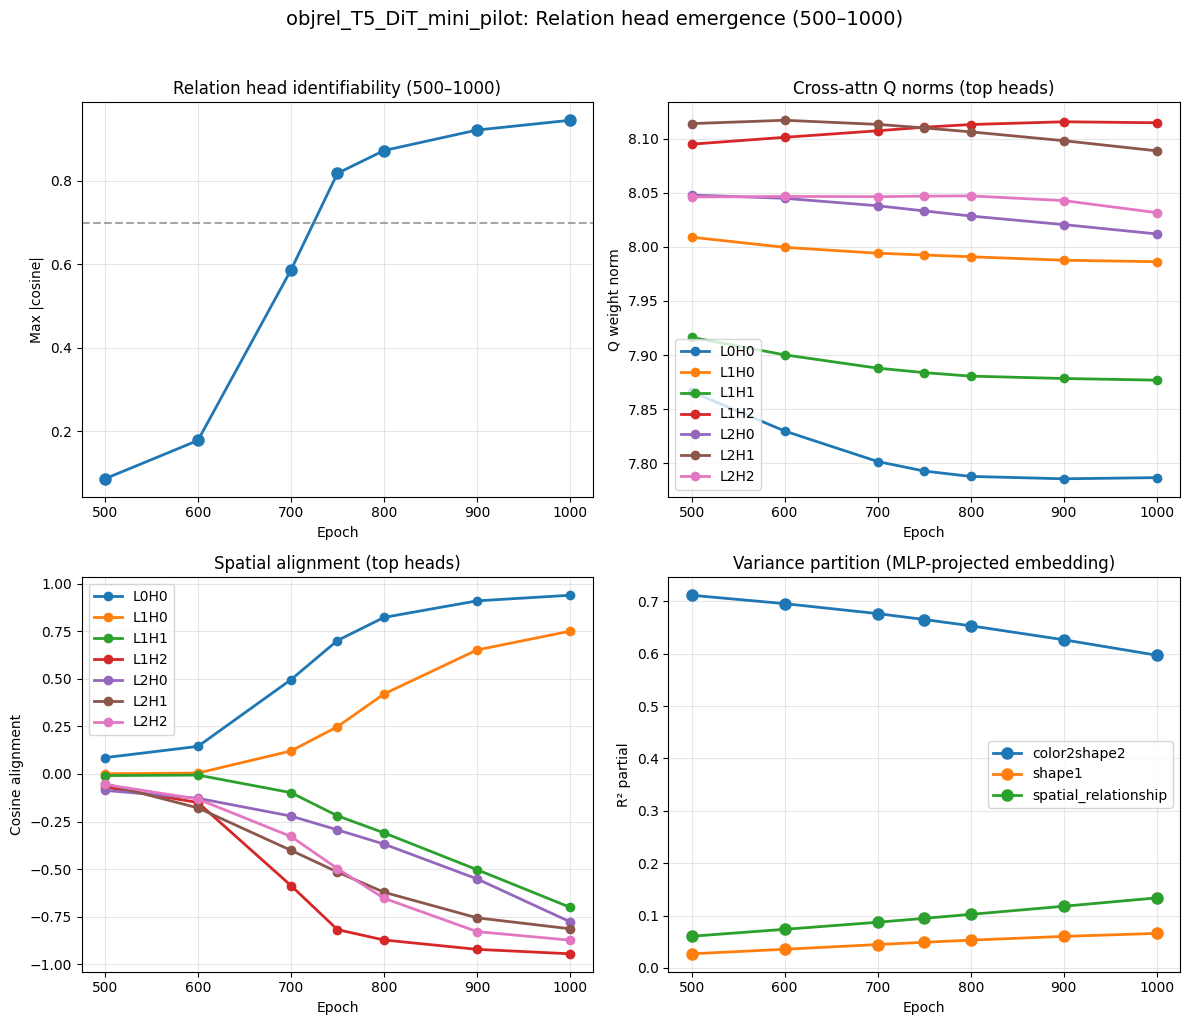

In [33]:
# Emergence: identifiability, projection norms, variance partition
top_em = []
for _, row in evolution_df_em[evolution_df_em["epoch"] == evolution_df_em["epoch"].max()].iterrows():
    if abs(row["cosine"]) > 0.7:
        top_em.append((int(row["layer_idx"]), int(row["head_idx"])))
if not top_em:
    top_em = [(0, 0), (1, 2), (2, 3)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Max |cosine| and gap
id_em = []
for epoch in sorted(evolution_df_em["epoch"].unique()):
    sub = evolution_df_em[evolution_df_em["epoch"] == epoch]
    abs_cos = sub["cosine"].abs()
    max_idx = abs_cos.idxmax()
    row = sub.loc[max_idx]
    top_layer, top_head = int(row["layer_idx"]), int(row["head_idx"])
    mean_other = sub[(sub["layer_idx"] != top_layer) | (sub["head_idx"] != top_head)]["cosine"].abs().mean()
    id_em.append({"epoch": epoch, "max_abs_cosine": abs(row["cosine"]), "gap": abs(row["cosine"]) - mean_other})
id_em = pd.DataFrame(id_em)
axes[0, 0].plot(id_em["epoch"], id_em["max_abs_cosine"], "o-", linewidth=2, markersize=8)
axes[0, 0].axhline(0.7, color="gray", linestyle="--", alpha=0.7)
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Max |cosine|")
axes[0, 0].set_title("Relation head identifiability (500–1000)")
axes[0, 0].grid(True, alpha=0.3)

# (b) Q norms for top heads
for layer_idx, head_idx in top_em:
    sub = q_norms_df_em[(q_norms_df_em["layer_idx"] == layer_idx) & (q_norms_df_em["head_idx"] == head_idx)]
    axes[0, 1].plot(sub["epoch"], sub["q_norm"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Q weight norm")
axes[0, 1].set_title("Cross-attn Q norms (top heads)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# (c) Cosine for top heads
for layer_idx, head_idx in top_em:
    sub = evolution_df_em[(evolution_df_em["layer_idx"] == layer_idx) & (evolution_df_em["head_idx"] == head_idx)]
    axes[1, 0].plot(sub["epoch"], sub["cosine"], "o-", label=f"L{layer_idx}H{head_idx}", linewidth=2, markersize=6)
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Cosine alignment")
axes[1, 0].set_title("Spatial alignment (top heads)")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# (d) Variance partition (R² partial)
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
for col in vp_em.columns:
    axes[1, 1].plot(vp_em.index, vp_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("R² partial")
axes[1, 1].set_title("Variance partition (MLP-projected embedding)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle(f"{model_run_name}: Relation head emergence (500–1000)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

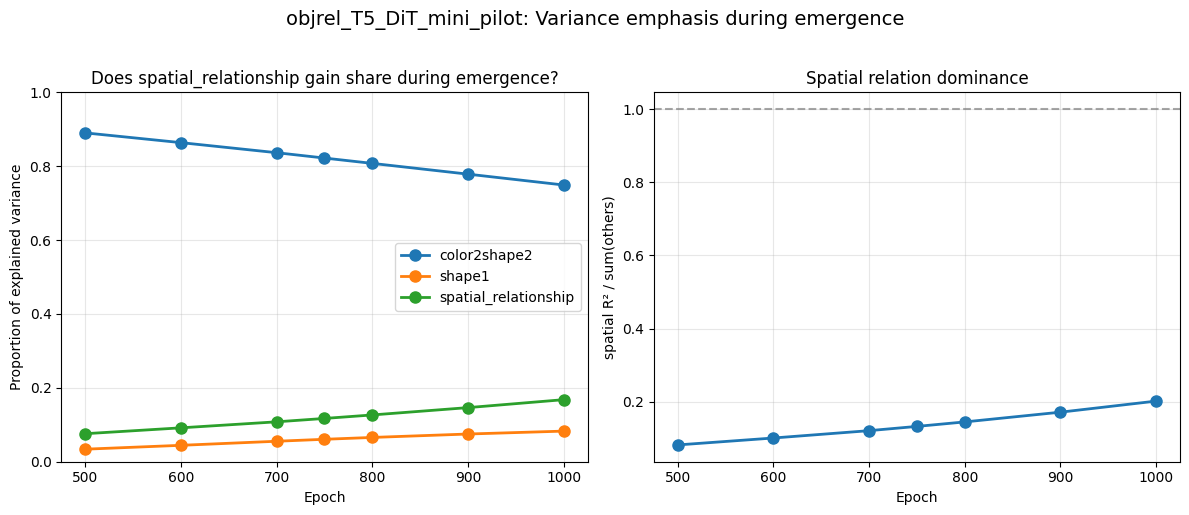

In [34]:
# Emergence: variance proportion and spatial dominance
vp_em = var_part_df_em.pivot_table(index="epoch", columns="feature", values="R2_partial", aggfunc="first").fillna(0)
vp_prop_em = vp_em.div(vp_em.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for col in vp_prop_em.columns:
    axes[0].plot(vp_prop_em.index, vp_prop_em[col], "o-", label=col, linewidth=2, markersize=8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Proportion of explained variance")
axes[0].set_title("Does spatial_relationship gain share during emergence?")
axes[0].legend()
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

if "spatial_relationship" in vp_em.columns:
    others = [c for c in vp_em.columns if c != "spatial_relationship"]
    ratio_em = vp_em["spatial_relationship"] / (vp_em[others].sum(axis=1) + 1e-10)
    axes[1].plot(vp_em.index, ratio_em, "o-", color="C0", linewidth=2, markersize=8)
    axes[1].axhline(1, color="gray", linestyle="--", alpha=0.7)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("spatial R² / sum(others)")
    axes[1].set_title("Spatial relation dominance")
    axes[1].grid(True, alpha=0.3)
plt.suptitle(f"{model_run_name}: Variance emphasis during emergence", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Ablation experiments

**What ablation can reveal:**

1. **Behavioral dependence** — Does ablating the head hurt spatial accuracy? (accuracy drop)
2. **Geometric vs behavioral timing** — Does the head align with spatial direction *before* ablation hurts? If so, geometric specialization precedes behavioral criticality.
3. **Head specificity** — Ablating the best-aligned head vs a random/anti-aligned head: only the relation head should matter.
4. **Control** — Ablating a random head should have minimal effect; ablating an anti-aligned head might *improve* accuracy (if it opposes spatial relations).

**Config below:** Edit `HEAD_SELECTION_MODE`, `ABLATION_LAYER_IX`, `ABLATION_HEAD_IX`, etc. to run different experiments.

**Execution order (cells below, top → bottom):**
1. **Early Ablation Sweep** — run the sweep code cell first (defines `prompts_ablation`, cache, `ablation_df_out`).
2. **Multi-head ablation** — runs *after* the sweep; reuses those variables.
3. **Plots / random-head / qualitative** — use `ablation_df_out` from the sweep.


### Early Ablation Sweep

**Design:** At each emergence checkpoint (500–1000), ablate the candidate relation head and measure spatial relation accuracy.

- **Baseline:** Generate images with no ablation → evaluate spatial correctness.
- **Ablated:** Zero-out the candidate relation head (layer, head from max |cosine| at that epoch) → evaluate.
- **Hypothesis:** Early checkpoints (500–600): ablation has little effect (head not yet specialized). Late checkpoints (800–1000): ablation hurts spatial accuracy (head is critical).

In [35]:
# Ablation sweep — configurable head selection and metrics
from utils.zero_head_ablation_utils import apply_zero_head_ablation, restore_processors
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from utils.ablation_eval_prompts import (
    build_training_template_prompts,
    build_diverse_subset_prompts,
    eval_means_line,
)

# ========== EDIT THESE PARAMETERS ==========
HEAD_SELECTION_MODE = "best_aligned"   # "best_aligned" | "specific_head" | "worst_aligned" | "random"
ABLATION_LAYER_IX = 0                  # used when mode="specific_head" (0–5 for 6 layers)
ABLATION_HEAD_IX = 0                   # used when mode="specific_head" (0–5 for 6 heads)
ABLATION_CHECKPOINTS = None            # None = use ckpt_files_ablation; or list e.g. ["epoch_500_step_20000.pth", ...]
# Prompt set — **major effect on accuracy levels**:
# - "training_template" = blue circle / red square, all relations (same as run_generalization_eval_local --single_prompt_mode). Use this for interpretable %.
# - "diverse" = 12 combinatorial color/shape pairs (much harder; strict spatial often ~0–5% even with a good checkpoint).
ABLATION_PROMPT_MODE = "training_template"
N_ABLATION_PROMPTS = 12                # only used when ABLATION_PROMPT_MODE == "diverse"
N_IMAGES_PER_PROMPT = 5
ABLATION_GUIDANCE_SCALE = 4.5  # match training / local eval; 1.0 often yields ~0% spatial accuracy
# ==========================================

embedding_cache_ablation = dict(embedding_allrel_allobj)
if "" not in embedding_cache_ablation:
    raise ValueError("Embedding cache needs '' key for uncond. Re-run precompute_t5_embeddings.py.")

if ABLATION_PROMPT_MODE == "training_template":
    _ds = ShapesDataset(num_images=100)
    prompts_ablation, scene_infos_ablation = build_training_template_prompts(
        embedding_cache_ablation, _ds.spatial_phrases
    )
    print(f"ABLATION_PROMPT_MODE=training_template: {len(prompts_ablation)} prompts (cached), aligned with generalization eval single-pair template")
elif ABLATION_PROMPT_MODE == "diverse":
    prompts_ablation, scene_infos_ablation = build_diverse_subset_prompts(
        prompt_scene_info_all_df, embedding_cache_ablation, n_prompts=N_ABLATION_PROMPTS
    )
    print(f"ABLATION_PROMPT_MODE=diverse: {len(prompts_ablation)} prompts (harder; expect low strict spatial vs training_template)")
else:
    raise ValueError(f"Unknown ABLATION_PROMPT_MODE: {ABLATION_PROMPT_MODE}")

ckpt_list = ABLATION_CHECKPOINTS if ABLATION_CHECKPOINTS is not None else ckpt_files_ablation
ablation_records = []
n_prompts = len(prompts_ablation)
total_steps = len(ckpt_list) * 2 * n_prompts
pbar = tqdm(total=total_steps, desc=f"Ablation ({HEAD_SELECTION_MODE})", unit="prompt", mininterval=2)

for ckpt_name in ckpt_list:
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    epoch = int(ckpt_name.split("_")[1])
    df_ep = evolution_df_em[evolution_df_em["epoch"] == epoch] if epoch <= 1000 else evolution_df[evolution_df["epoch"] == epoch]
    if df_ep.empty:
        continue

    # Select head to ablate based on mode
    if HEAD_SELECTION_MODE == "specific_head":
        layer_idx, head_idx = ABLATION_LAYER_IX, ABLATION_HEAD_IX
        row_ep = df_ep[(df_ep["layer_idx"] == layer_idx) & (df_ep["head_idx"] == head_idx)]
        cosine_at_epoch = float(row_ep["cosine"].iloc[0]) if not row_ep.empty else np.nan
    elif HEAD_SELECTION_MODE == "best_aligned":
        best = df_ep.loc[df_ep["cosine"].abs().idxmax()]
        layer_idx, head_idx = int(best["layer_idx"]), int(best["head_idx"])
        cosine_at_epoch = float(best["cosine"])
    elif HEAD_SELECTION_MODE == "worst_aligned":
        worst = df_ep.loc[df_ep["cosine"].abs().idxmin()]
        layer_idx, head_idx = int(worst["layer_idx"]), int(worst["head_idx"])
        cosine_at_epoch = float(worst["cosine"])
    elif HEAD_SELECTION_MODE == "random":
        import random
        row = df_ep.sample(1).iloc[0]
        layer_idx, head_idx = int(row["layer_idx"]), int(row["head_idx"])
        cosine_at_epoch = float(row["cosine"])
    else:
        raise ValueError(f"Unknown HEAD_SELECTION_MODE: {HEAD_SELECTION_MODE}")

    # Baseline (no ablation)
    pbar.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="baseline")
    eval_baseline, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar.update(1),
    )
    acc_baseline = eval_baseline["spatial_relationship"].mean() if not eval_baseline.empty and "spatial_relationship" in eval_baseline.columns else np.nan

    # Ablated
    pbar.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="ablated")
    orig_procs = apply_zero_head_ablation(pipeline.transformer, layer_idx, [head_idx])
    eval_abl, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar.update(1),
    )
    restore_processors(pipeline.transformer, orig_procs)
    acc_abl = eval_abl["spatial_relationship"].mean() if not eval_abl.empty and "spatial_relationship" in eval_abl.columns else np.nan

    if epoch == int(ckpt_list[-1].split("_")[1]) or len(ckpt_list) == 1:
        print("Last checkpoint eval (example) — " + eval_means_line(eval_baseline, "baseline: "))
        print("Last checkpoint eval (example) — " + eval_means_line(eval_abl, "ablated: "))

    ablation_records.append({
        "epoch": epoch, "checkpoint": ckpt_name,
        "layer_idx": layer_idx, "head_idx": head_idx, "head_label": f"L{layer_idx}H{head_idx}",
        "cosine_alignment": cosine_at_epoch,
        "acc_baseline": acc_baseline, "acc_ablated": acc_abl,
        "acc_drop": acc_baseline - acc_abl,
        "head_selection_mode": HEAD_SELECTION_MODE,
    })

ablation_df_out = pd.DataFrame(ablation_records)
print(f"Config: prompt_mode={ABLATION_PROMPT_MODE}, head_mode={HEAD_SELECTION_MODE}, n_prompts={len(prompts_ablation)}, n_images={N_IMAGES_PER_PROMPT}")
print(ablation_df_out.to_string())


ABLATION_PROMPT_MODE=training_template: 22 prompts (cached), aligned with generalization eval single-pair template


Ablation (best_aligned):   0%|          | 0/396 [00:00<?, ?prompt/s]

Ablation (best_aligned):  99%|█████████▊| 391/396 [02:18<00:01,  2.83prompt/s, epoch=4000, head=L1H2, status=ablated] 

Last checkpoint eval (example) — baseline: overall=0.745 | unique_binding=0.882 | exist_binding=0.882 | spatial_relationship=0.745 | spatial_relationship_loose=0.882
Last checkpoint eval (example) — ablated: overall=0.773 | unique_binding=0.882 | exist_binding=0.882 | spatial_relationship=0.773 | spatial_relationship_loose=0.864
Config: prompt_mode=training_template, head_mode=best_aligned, n_prompts=22, n_images=5
   epoch                  checkpoint  layer_idx  head_idx head_label  cosine_alignment  acc_baseline  acc_ablated  acc_drop head_selection_mode
0    500    epoch_500_step_20000.pth          2         0       L2H0         -0.086420      0.000000     0.000000  0.000000        best_aligned
1    600    epoch_600_step_24000.pth          2         1       L2H1         -0.178213      0.054545     0.054545  0.000000        best_aligned
2    700    epoch_700_step_28000.pth          1         2       L1H2         -0.586221      0.054545     0.054545  0.000000        best_aligned
3    

### Multi-head ablation (fixed head sets)

Use the same explicit head sets at every checkpoint:
1. **1 head** = `L1H2`
2. **2 heads** = `L1H2 + L0H0`
3. **4 heads** = `L1H2 + L0H0 + L2H2 + L3H4`
4. **all heads** = every cross-attention (`attn2`) head

This removes the cosine-based head selection entirely. The multi-head section now answers a simpler question: how much does performance change over training when we ablate these exact hand-picked sets?

**Important:** Run the **Early Ablation Sweep** cell above (in this section). These cells reuse the sweep's `prompts_ablation`, `scene_infos_ablation`, and `embedding_cache_ablation` — redefining them can cause 0 accuracy if the cache keys don't match.

In [36]:
# Multi-head ablation sweep across training checkpoints (fixed head sets)
# Prerequisite: run the Early Ablation Sweep code cell above (prompts, cache, `ablation_df_out`).
import gc
import glob
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from os.path import join, basename

from utils.zero_head_ablation_utils import (
    apply_zero_head_ablation_multi,
    restore_processors,
    all_cross_attn_head_pairs,
)
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings

ABLATION_GUIDANCE_SCALE = globals().get("ABLATION_GUIDANCE_SCALE", 4.5)
MULTIHEAD_INCLUDE_ALL = globals().get("MULTIHEAD_INCLUDE_ALL", True)
MULTIHEAD_CHECKPOINTS = globals().get("MULTIHEAD_CHECKPOINTS", None)
MULTIHEAD_N_IMAGES_PER_PROMPT = globals().get("MULTIHEAD_N_IMAGES_PER_PROMPT", globals().get("N_IMAGES_PER_PROMPT", 5))
MULTIHEAD_N_STEPS = globals().get("MULTIHEAD_N_STEPS", 14)
MULTIHEAD_FIXED_SETS = globals().get(
    "MULTIHEAD_FIXED_SETS",
    {
        "1h": [(1, 2)],
        "2h": [(1, 2), (0, 0)],
        "4h": [(1, 2), (0, 0), (2, 2), (3, 4)],
    },
)

if "prompts_ablation" not in dir() or len(prompts_ablation) == 0:
    raise RuntimeError("Run the Early Ablation Sweep cell first. It defines prompts_ablation, scene_infos_ablation, embedding_cache_ablation.")

missing = [p for p in prompts_ablation if not any(k != "" and k.endswith(f"::{p}") for k in embedding_cache_ablation)]
if missing:
    raise RuntimeError(f"No cache for prompts: {missing[:3]}... Run the ablation sweep first.")

if "ckpt_files_ablation" not in dir() or not ckpt_files_ablation:
    ckpt_files_ablation = sorted(
        glob.glob(join(ckptdir, "*.pth")),
        key=lambda p: int(basename(p).split("_step_")[-1].split(".pth")[0]) if "_step_" in p else 0,
    )

if MULTIHEAD_CHECKPOINTS is not None:
    ckpt_list = MULTIHEAD_CHECKPOINTS
elif "ABLATION_CHECKPOINTS" in dir() and ABLATION_CHECKPOINTS is not None:
    ckpt_list = ABLATION_CHECKPOINTS
else:
    ckpt_list = ckpt_files_ablation

if not ckpt_list:
    raise RuntimeError("No checkpoints found for multi-head ablation sweep.")


def get_alignment_df_for_epoch(epoch):
    if epoch <= 1000 and "evolution_df_em" in dir():
        return evolution_df_em[evolution_df_em["epoch"] == epoch].copy()
    return evolution_df[evolution_df["epoch"] == epoch].copy()



def head_pairs_to_str(layer_head_pairs):
    return "+".join([f"L{layer}H{head}" for layer, head in layer_head_pairs])



def relation_alignment_strength(df_ep, layer_head_pairs):
    if df_ep is None or df_ep.empty:
        return np.nan
    vals = []
    for layer_idx, head_idx in layer_head_pairs:
        row = df_ep[(df_ep["layer_idx"] == layer_idx) & (df_ep["head_idx"] == head_idx)]
        if not row.empty:
            vals.append(abs(float(row.iloc[0]["cosine"])))
    return float(np.mean(vals)) if vals else np.nan



def spatial_mean(eval_df):
    if eval_df is None or eval_df.empty:
        return np.nan
    if "spatial_relationship" not in eval_df.columns:
        raise KeyError("Expected strict spatial_relationship in eval_df.")
    return float(eval_df["spatial_relationship"].mean())



def run_cached_eval(layer_head_pairs=None, progress_callback=None):
    orig = None
    if layer_head_pairs:
        orig = apply_zero_head_ablation_multi(pipeline.transformer, layer_head_pairs)
    try:
        eval_df, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
            pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
            num_images=MULTIHEAD_N_IMAGES_PER_PROMPT,
            num_inference_steps=MULTIHEAD_N_STEPS,
            guidance_scale=ABLATION_GUIDANCE_SCALE,
            generator_seed=42,
            device=device,
            weight_dtype=compute_dtype,
            show_prompt_progress=False,
            progress_callback=progress_callback,
        )
    finally:
        if orig is not None:
            restore_processors(pipeline.transformer, orig)
    return eval_df


condition_specs_template = [
    {
        "condition_key": "1h",
        "condition_label": "1 head",
        "condition_sort_key": 1,
        "layer_head_pairs": [tuple(x) for x in MULTIHEAD_FIXED_SETS["1h"]],
    },
    {
        "condition_key": "2h",
        "condition_label": "2 heads",
        "condition_sort_key": 2,
        "layer_head_pairs": [tuple(x) for x in MULTIHEAD_FIXED_SETS["2h"]],
    },
    {
        "condition_key": "4h",
        "condition_label": "4 heads",
        "condition_sort_key": 4,
        "layer_head_pairs": [tuple(x) for x in MULTIHEAD_FIXED_SETS["4h"]],
    },
]

records = []
n_conditions = len(condition_specs_template) + (1 if MULTIHEAD_INCLUDE_ALL else 0)
total_steps = len(ckpt_list) * (1 + n_conditions) * len(prompts_ablation)
pbar = tqdm(total=total_steps, desc="Multi-head ablation", unit="prompt", mininterval=2)

for ckpt_name in ckpt_list:
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    epoch = int(basename(ckpt_name).split("_")[1])
    df_ep = get_alignment_df_for_epoch(epoch)
    condition_specs = [dict(spec) for spec in condition_specs_template]
    if MULTIHEAD_INCLUDE_ALL:
        all_pairs = all_cross_attn_head_pairs(pipeline.transformer)
        condition_specs.append(
            {
                "condition_key": "all",
                "condition_label": f"all heads (n={len(all_pairs)})",
                "condition_sort_key": 999,
                "layer_head_pairs": all_pairs,
            }
        )

    pbar.set_postfix(epoch=epoch, condition="baseline")
    eval_baseline = run_cached_eval(progress_callback=lambda: pbar.update(1))
    acc_baseline = spatial_mean(eval_baseline)

    for spec in condition_specs:
        pbar.set_postfix(epoch=epoch, condition=spec["condition_key"])
        eval_abl = run_cached_eval(spec["layer_head_pairs"], progress_callback=lambda: pbar.update(1))
        acc_abl = spatial_mean(eval_abl)
        records.append(
            {
                "epoch": epoch,
                "checkpoint": basename(ckpt_name),
                "condition_key": spec["condition_key"],
                "condition_label": spec["condition_label"],
                "condition_sort_key": spec["condition_sort_key"],
                "n_heads": len(spec["layer_head_pairs"]),
                "layer_head_pairs": repr(spec["layer_head_pairs"]),
                "selected_head_labels": head_pairs_to_str(spec["layer_head_pairs"]),
                "relation_alignment_strength": relation_alignment_strength(df_ep, spec["layer_head_pairs"]),
                "acc_baseline": acc_baseline,
                "acc_ablated": acc_abl,
                "acc_drop": acc_baseline - acc_abl,
            }
        )

multihead_ablation_df_out = pd.DataFrame(records)
if not multihead_ablation_df_out.empty:
    multihead_ablation_df_out = multihead_ablation_df_out.sort_values(["epoch", "condition_sort_key"]).reset_index(drop=True)

print(
    f"Config: n_prompts={len(prompts_ablation)}, n_images={MULTIHEAD_N_IMAGES_PER_PROMPT}, "
    f"n_steps={MULTIHEAD_N_STEPS}, fixed_sets={MULTIHEAD_FIXED_SETS}, include_all={MULTIHEAD_INCLUDE_ALL}"
)
if multihead_ablation_df_out.empty:
    print("No multi-head ablation rows were produced.")
else:
    print(
        multihead_ablation_df_out[
            [
                "epoch", "condition_label", "selected_head_labels", "acc_baseline",
                "acc_ablated", "acc_drop",
            ]
        ].to_string(index=False)
    )


Ablation (best_aligned): 100%|██████████| 396/396 [02:20<00:00,  2.83prompt/s, epoch=4000, head=L1H2, status=ablated]

Config: n_prompts=22, n_images=5, n_steps=14, fixed_sets={'1h': [(1, 2)], '2h': [(1, 2), (0, 0)], '4h': [(1, 2), (0, 0), (2, 2), (3, 4)]}, include_all=True
 epoch  condition_label                                                                                                                                                                selected_head_labels  acc_baseline  acc_ablated  acc_drop
   500           1 head                                                                                                                                                                                L1H2      0.000000     0.000000  0.000000
   500          2 heads                                                                                                                                                                           L1H2+L0H0      0.000000     0.000000  0.000000
   500          4 heads                                                                                                  

In [37]:
# Multi-head ablation sanity-check table
if "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
    print("Run the multi-head ablation sweep cell above first.")
else:
    sanity_df = multihead_ablation_df_out[
        [
            "epoch", "condition_label", "selected_head_labels", "relation_alignment_strength",
            "acc_baseline", "acc_ablated", "acc_drop",
        ]
    ].copy()
    print(sanity_df.to_string(index=False))
    print()
    print("Interpretation:")
    print("- Head sets are fixed by hand, not selected by cosine anymore.")
    print("- relation_alignment_strength is descriptive only: mean |cosine| of those heads to the spatial/object-relation direction at that checkpoint.")
    print("- Compare causal effect by acc_drop = baseline - ablated.")


 epoch  condition_label                                                                                                                                                                selected_head_labels  relation_alignment_strength  acc_baseline  acc_ablated  acc_drop
   500           1 head                                                                                                                                                                                L1H2                     0.068358      0.000000     0.000000  0.000000
   500          2 heads                                                                                                                                                                           L1H2+L0H0                     0.077043      0.000000     0.000000  0.000000
   500          4 heads                                                                                                                                                                 L1H2+L

In [38]:
# Sanity check: direct L1H2 ablation vs recorded single-head / multi-head 1h
import gc
import torch
import numpy as np
import pandas as pd
from os.path import join

from utils.zero_head_ablation_utils import apply_zero_head_ablation_multi, restore_processors
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings

if "ablation_df_out" not in dir() or ablation_df_out is None or ablation_df_out.empty:
    print("Run the Early Ablation Sweep cell first.")
elif "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
    print("Run the multi-head ablation sweep cell first.")
else:
    final_epoch = int(ablation_df_out["epoch"].max())
    single_row = ablation_df_out[ablation_df_out["epoch"] == final_epoch].iloc[-1]
    multi_row = multihead_ablation_df_out[
        (multihead_ablation_df_out["epoch"] == final_epoch) &
        (multihead_ablation_df_out["condition_key"] == "1h")
    ].iloc[-1]

    ckpt_name = single_row["checkpoint"]
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    def strict_spatial_mean(eval_df):
        if eval_df is None or eval_df.empty or "spatial_relationship" not in eval_df.columns:
            return np.nan
        return float(eval_df["spatial_relationship"].mean())

    def run_eval(layer_head_pairs=None):
        orig = None
        if layer_head_pairs:
            orig = apply_zero_head_ablation_multi(pipeline.transformer, layer_head_pairs)
        try:
            eval_df, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
                pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
                num_images=MULTIHEAD_N_IMAGES_PER_PROMPT,
                num_inference_steps=MULTIHEAD_N_STEPS,
                guidance_scale=ABLATION_GUIDANCE_SCALE,
                generator_seed=42,
                device=device,
                weight_dtype=compute_dtype,
                show_prompt_progress=False,
            )
        finally:
            if orig is not None:
                restore_processors(pipeline.transformer, orig)
        return strict_spatial_mean(eval_df)

    direct_base = run_eval()
    direct_l1h2 = run_eval([(1, 2)])

    print(f"Final epoch sanity check (epoch={final_epoch}, ckpt={ckpt_name})")
    print("Recorded single-head sweep:")
    print(f"  head={single_row['head_label']} baseline={single_row['acc_baseline']:.6f} ablated={single_row['acc_ablated']:.6f} drop={single_row['acc_drop']:.6f}")
    print("Recorded multi-head 1h:")
    print(f"  heads={multi_row['selected_head_labels']} baseline={multi_row['acc_baseline']:.6f} ablated={multi_row['acc_ablated']:.6f} drop={multi_row['acc_drop']:.6f}")
    print("Direct recomputation with the multi-head eval settings:")
    print(f"  heads=L1H2 baseline={direct_base:.6f} ablated={direct_l1h2:.6f} drop={direct_base - direct_l1h2:.6f}")


Final epoch sanity check (epoch=4000, ckpt=epoch_4000_step_160000.pth)
Recorded single-head sweep:
  head=L1H2 baseline=0.745455 ablated=0.772727 drop=-0.027273
Recorded multi-head 1h:
  heads=L1H2 baseline=0.745455 ablated=0.772727 drop=-0.027273
Direct recomputation with the multi-head eval settings:
  heads=L1H2 baseline=0.745455 ablated=0.772727 drop=-0.027273


### Multi-head ablation: plots and head-importance heatmaps

These plots mirror the single-head ablation section, but for the fixed head sets above. They show:
1. **Accuracy drop vs training** for `1`, `2`, `4`, and `all` head sets
2. **Baseline vs ablated accuracy** through training
3. **Object-relation alignment strength** through training
4. **Head-importance heatmaps after multi-head ablation**

Here, **alignment strength** is descriptive only: the mean `|cosine|` alignment of the chosen fixed heads to the learned `spatial_relationship` direction at that checkpoint. It is **not** used to choose the heads anymore.

The heatmaps use **strict `spatial_relationship` only**. For a chosen base multi-head ablation set (for example `2h`), they additionally ablate **one more head** at a time and plot the **extra spatial-relation drop**:
`importance(layer, head) = base_spatial_acc - spatial_acc_after_ablating_base_plus_that_head)`

So each cell is a head-wise causal importance score for the spatial-relation task. **Large positive values mean that head was still important / compensating after the base multi-head ablation.** Negative values mean the extra ablation slightly improved strict spatial accuracy on this eval set. Base ablated heads are marked in black.


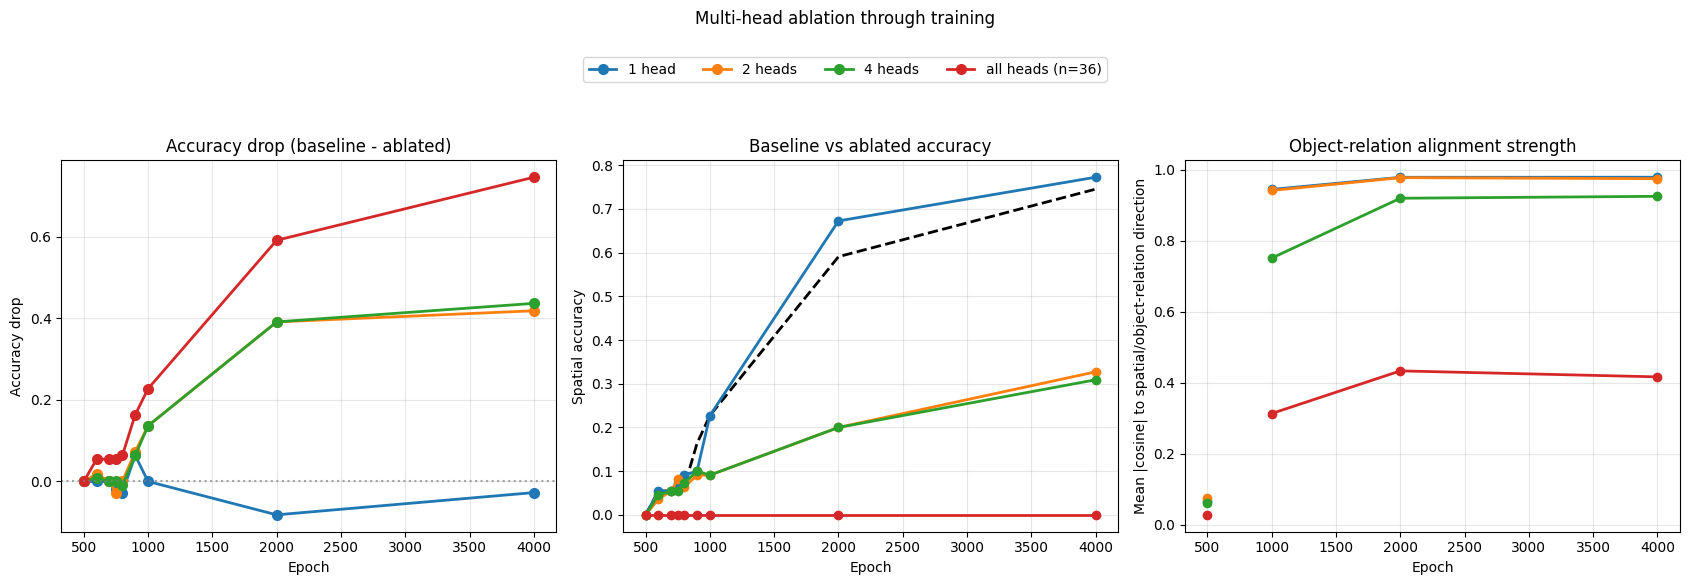

Multi-head importance heatmaps (2h):   4%|▍         | 268/6732 [02:07<4:46:50,  2.66s/prompt, epoch=500, extra_head=L2H2]

KeyboardInterrupt: 

Multi-head importance heatmaps (2h):   4%|▍         | 268/6732 [02:19<4:46:50,  2.66s/prompt, epoch=500, extra_head=L2H2]

In [39]:
# Multi-head ablation visualizations (from multihead_ablation_df_out)
import ast
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from matplotlib.patches import Rectangle
from tqdm.auto import tqdm

from utils.zero_head_ablation_utils import apply_zero_head_ablation_multi, restore_processors
from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings

if "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
    print("Run the multi-head ablation sweep cell above first.")
else:
    df = multihead_ablation_df_out.sort_values(["condition_sort_key", "epoch"]).copy()
    cond_order = (
        df[["condition_label", "condition_sort_key"]]
        .drop_duplicates()
        .sort_values("condition_sort_key")["condition_label"]
        .tolist()
    )
    baseline_df = df.groupby("epoch", as_index=False)["acc_baseline"].first().sort_values("epoch")

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # 1. Accuracy drop vs epoch
    for cond in cond_order:
        dfc = df[df["condition_label"] == cond].sort_values("epoch")
        axes[0].plot(dfc["epoch"], dfc["acc_drop"], "o-", linewidth=2, markersize=7, label=cond)
    axes[0].axhline(0, color="gray", linestyle=":", alpha=0.7)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy drop")
    axes[0].set_title("Accuracy drop (baseline - ablated)")
    axes[0].grid(True, alpha=0.3)

    # 2. Baseline vs ablated accuracy vs epoch
    axes[1].plot(baseline_df["epoch"], baseline_df["acc_baseline"], "k--", linewidth=2, label="Baseline")
    for cond in cond_order:
        dfc = df[df["condition_label"] == cond].sort_values("epoch")
        axes[1].plot(dfc["epoch"], dfc["acc_ablated"], "o-", linewidth=2, markersize=6, label=cond)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Spatial accuracy")
    axes[1].set_title("Baseline vs ablated accuracy")
    axes[1].grid(True, alpha=0.3)

    # 3. Descriptive object-relation alignment strength vs epoch
    for cond in cond_order:
        dfc = df[df["condition_label"] == cond].sort_values("epoch")
        axes[2].plot(dfc["epoch"], dfc["relation_alignment_strength"], "o-", linewidth=2, markersize=6, label=cond)
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Mean |cosine| to spatial/object-relation direction")
    axes[2].set_title("Object-relation alignment strength")
    axes[2].grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 4), bbox_to_anchor=(0.5, 1.08))
    fig.suptitle("Multi-head ablation through training", fontsize=12, y=1.16)
    plt.tight_layout()
    plt.show()

    MULTIHEAD_HEATMAP_CONDITION = globals().get("MULTIHEAD_HEATMAP_CONDITION", "2h")
    MULTIHEAD_HEATMAP_EPOCHS = globals().get("MULTIHEAD_HEATMAP_EPOCHS", sorted(df["epoch"].unique()))
    MULTIHEAD_HEATMAP_N_IMAGES = globals().get("MULTIHEAD_HEATMAP_N_IMAGES", min(globals().get("N_IMAGES_PER_PROMPT", 5), 3))
    MULTIHEAD_HEATMAP_N_STEPS = globals().get("MULTIHEAD_HEATMAP_N_STEPS", globals().get("MULTIHEAD_N_STEPS", 14))

    heat_rows = df[df["condition_key"] == MULTIHEAD_HEATMAP_CONDITION].copy()
    if heat_rows.empty:
        fallback_key = df.sort_values("condition_sort_key").iloc[0]["condition_key"]
        print(f"No rows for MULTIHEAD_HEATMAP_CONDITION={MULTIHEAD_HEATMAP_CONDITION!r}; using {fallback_key!r} instead.")
        MULTIHEAD_HEATMAP_CONDITION = fallback_key
        heat_rows = df[df["condition_key"] == MULTIHEAD_HEATMAP_CONDITION].copy()

    heat_rows = heat_rows[heat_rows["epoch"].isin(MULTIHEAD_HEATMAP_EPOCHS)].sort_values("epoch")
    if heat_rows.empty:
        print("No epochs matched MULTIHEAD_HEATMAP_EPOCHS for the head-importance heatmaps.")
    else:
        layer_num = transformer_config["depth"]
        head_num = transformer_config["num_heads"]

        def spatial_mean(eval_df):
            if eval_df is None or eval_df.empty:
                return np.nan
            if "spatial_relationship" not in eval_df.columns:
                raise KeyError("Expected strict spatial_relationship in eval_df for multi-head importance heatmaps.")
            return float(eval_df["spatial_relationship"].mean())

        def run_cached_eval(layer_head_pairs, progress_callback=None):
            orig = apply_zero_head_ablation_multi(pipeline.transformer, layer_head_pairs)
            try:
                eval_df, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
                    pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
                    num_images=MULTIHEAD_HEATMAP_N_IMAGES,
                    num_inference_steps=MULTIHEAD_HEATMAP_N_STEPS,
                    guidance_scale=ABLATION_GUIDANCE_SCALE,
                    generator_seed=42,
                    device=device,
                    weight_dtype=compute_dtype,
                    show_prompt_progress=False,
                    progress_callback=progress_callback,
                )
            finally:
                restore_processors(pipeline.transformer, orig)
            return eval_df

        total_evals = 0
        for _, row in heat_rows.iterrows():
            base_pairs = ast.literal_eval(row["layer_head_pairs"])
            total_evals += (layer_num * head_num - len(base_pairs)) * len(prompts_ablation)
        pbar = tqdm(total=total_evals, desc=f"Multi-head importance heatmaps ({MULTIHEAD_HEATMAP_CONDITION})", unit="prompt", mininterval=2)

        heatmap_results = []
        for _, row in heat_rows.iterrows():
            epoch = int(row["epoch"])
            ckpt_name = row["checkpoint"]
            base_pairs = [tuple(x) for x in ast.literal_eval(row["layer_head_pairs"])]
            base_set = set(base_pairs)

            ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
            pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
            pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
            del ckpt
            gc.collect()

            heat_acc = np.full((layer_num, head_num), np.nan, dtype=float)
            heat_importance = np.full((layer_num, head_num), np.nan, dtype=float)
            base_acc = float(row["acc_ablated"])
            for layer_idx in range(layer_num):
                for head_idx in range(head_num):
                    if (layer_idx, head_idx) in base_set:
                        continue
                    pairs = list(base_pairs) + [(layer_idx, head_idx)]
                    pbar.set_postfix(epoch=epoch, extra_head=f"L{layer_idx}H{head_idx}")
                    eval_df = run_cached_eval(pairs, progress_callback=lambda: pbar.update(1))
                    extra_acc = spatial_mean(eval_df)
                    heat_acc[layer_idx, head_idx] = extra_acc
                    heat_importance[layer_idx, head_idx] = base_acc - extra_acc

            heatmap_results.append(
                {
                    "epoch": epoch,
                    "condition_label": row["condition_label"],
                    "selected_head_labels": row["selected_head_labels"],
                    "base_pairs": base_pairs,
                    "base_acc": base_acc,
                    "heat_acc": heat_acc,
                    "heat_importance": heat_importance,
                }
            )

        importance_vals = np.concatenate([
            np.ravel(res["heat_importance"][~np.isnan(res["heat_importance"])])
            for res in heatmap_results
            if np.any(~np.isnan(res["heat_importance"]))
        ])
        vmax = float(np.max(np.abs(importance_vals))) if importance_vals.size else 1.0
        vmax = max(vmax, 1e-6)

        n_panels = len(heatmap_results)
        ncols = min(3, n_panels)
        nrows = (n_panels + ncols - 1) // ncols
        fig2, axes2 = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.9 * nrows))
        axes2 = np.atleast_2d(axes2)

        for idx, res in enumerate(heatmap_results):
            ax = axes2[idx // ncols, idx % ncols]
            sns.heatmap(
                res["heat_importance"], annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-vmax, vmax=vmax, ax=ax, cbar=True,
                xticklabels=list(range(head_num)), yticklabels=list(range(layer_num)),
            )
            ax.set_title(
                f"Epoch {res['epoch']} | {res['condition_label']}\n"
                f"strict spatial drop after ablating one extra head (base acc={res['base_acc']:.2f})",
                fontsize=10,
            )
            ax.set_xlabel("Extra ablated head")
            ax.set_ylabel("Layer")
            for layer_idx, head_idx in res["base_pairs"]:
                ax.add_patch(Rectangle((head_idx, layer_idx), 1, 1, fill=True, facecolor="black", edgecolor="white", linewidth=2, zorder=10))
                ax.text(head_idx + 0.5, layer_idx + 0.5, "ABL", ha="center", va="center", fontsize=7, color="white", fontweight="bold", zorder=11)

        for idx in range(n_panels, nrows * ncols):
            axes2.flatten()[idx].set_visible(False)

        plt.suptitle(
            f"Spatial-relation head importance after base multi-head ablation ({MULTIHEAD_HEATMAP_CONDITION})",
            fontsize=12,
            y=1.02,
        )
        plt.tight_layout()
        plt.show()


### Relation head ablation results

Plots below show the ablation sweep results for the best-aligned (relation) head: accuracy drop, baseline vs ablated accuracy, and cosine alignment over epochs.

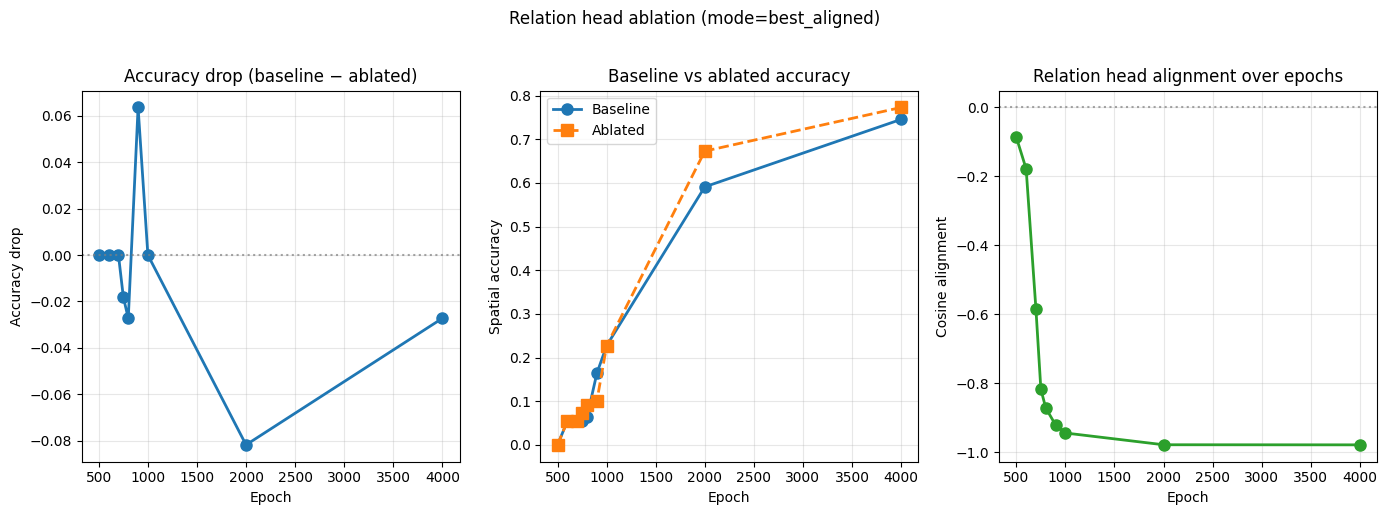

In [ ]:
# Relation head ablation visualizations (from ablation_df_out)
if not ablation_df_out.empty:
    df = ablation_df_out.sort_values("epoch")
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    # 1. Accuracy drop vs epoch
    ax = axes[0]
    ax.plot(df["epoch"], df["acc_drop"], "o-", linewidth=2, markersize=8, color="C0")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.7)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy drop")
    ax.set_title("Accuracy drop (baseline − ablated)")
    ax.grid(True, alpha=0.3)

    # 2. Baseline vs ablated accuracy vs epoch
    ax = axes[1]
    ax.plot(df["epoch"], df["acc_baseline"], "o-", label="Baseline", linewidth=2, markersize=8)
    ax.plot(df["epoch"], df["acc_ablated"], "s--", label="Ablated", linewidth=2, markersize=8)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Spatial accuracy")
    ax.set_title("Baseline vs ablated accuracy")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 3. Cosine alignment vs epoch
    ax = axes[2]
    ax.plot(df["epoch"], df["cosine_alignment"], "o-", linewidth=2, markersize=8, color="C2")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.7)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cosine alignment")
    ax.set_title("Relation head alignment over epochs")
    ax.grid(True, alpha=0.3)

    fig.suptitle(f"Relation head ablation (mode={df['head_selection_mode'].iloc[0]})", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Run the ablation sweep cell above first.")

### Comparison: relation head vs random head ablation

Run the ablation cell above with `HEAD_SELECTION_MODE = "best_aligned"` first. This cell then runs the same ablation with a **random** head per checkpoint and plots accuracy drop: relation head (best-aligned) vs random head.

Multi-head importance heatmaps (2h): 100%|██████████| 6732/6732 [24:40<00:00,  4.72prompt/s, epoch=4000, extra_head=L5H5]

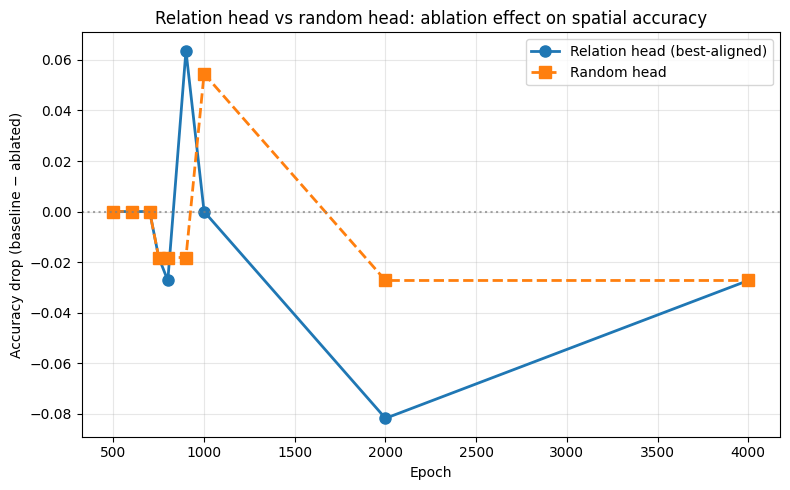

In [ ]:
ABLATION_GUIDANCE_SCALE = globals().get("ABLATION_GUIDANCE_SCALE", 4.5)
# Run random-head ablation and compare to relation-head (run ablation above with best_aligned first)
if not ablation_df_out.empty and ablation_df_out["head_selection_mode"].iloc[0] == "best_aligned":
    ablation_df_best = ablation_df_out.copy()
elif "ablation_df_best" not in dir():
    ablation_df_best = None

ckpt_list_r = ABLATION_CHECKPOINTS if ABLATION_CHECKPOINTS is not None else ckpt_files_ablation
ablation_records_random = []
pbar_r = tqdm(total=len(ckpt_list_r)*2*len(prompts_ablation), desc="Ablation (random)", unit="prompt", mininterval=2)
for ckpt_name in ckpt_list_r:
    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    epoch = int(ckpt_name.split("_")[1])
    df_ep = evolution_df_em[evolution_df_em["epoch"] == epoch] if epoch <= 1000 else evolution_df[evolution_df["epoch"] == epoch]
    if df_ep.empty:
        continue

    import random
    row = df_ep.sample(1).iloc[0]
    layer_idx, head_idx = int(row["layer_idx"]), int(row["head_idx"])
    cosine_at_epoch = float(row["cosine"])

    pbar_r.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="baseline")
    eval_baseline, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar_r.update(1),
    )
    acc_baseline = eval_baseline["spatial_relationship"].mean() if not eval_baseline.empty and "spatial_relationship" in eval_baseline.columns else np.nan

    pbar_r.set_postfix(epoch=epoch, head=f"L{layer_idx}H{head_idx}", status="ablated")
    orig_procs = apply_zero_head_ablation(pipeline.transformer, layer_idx, [head_idx])
    eval_abl, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype,
        show_prompt_progress=False, progress_callback=lambda: pbar_r.update(1),
    )
    restore_processors(pipeline.transformer, orig_procs)
    acc_abl = eval_abl["spatial_relationship"].mean() if not eval_abl.empty and "spatial_relationship" in eval_abl.columns else np.nan

    ablation_records_random.append({
        "epoch": epoch, "checkpoint": ckpt_name,
        "layer_idx": layer_idx, "head_idx": head_idx, "head_label": f"L{layer_idx}H{head_idx}",
        "cosine_alignment": cosine_at_epoch,
        "acc_baseline": acc_baseline, "acc_ablated": acc_abl,
        "acc_drop": acc_baseline - acc_abl,
        "head_selection_mode": "random",
    })

ablation_df_random = pd.DataFrame(ablation_records_random)

# Plot: relation head vs random head accuracy drop
fig, ax = plt.subplots(figsize=(8, 5))
if ablation_df_best is not None and not ablation_df_best.empty:
    ax.plot(ablation_df_best["epoch"], ablation_df_best["acc_drop"], "o-", label="Relation head (best-aligned)", linewidth=2, markersize=8)
if not ablation_df_random.empty:
    ax.plot(ablation_df_random["epoch"], ablation_df_random["acc_drop"], "s--", label="Random head", linewidth=2, markersize=8)
ax.axhline(0, color="gray", linestyle=":", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy drop (baseline − ablated)")
ax.set_title("Relation head vs random head: ablation effect on spatial accuracy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Qualitative image results: baseline vs ablation

Generate images for the same prompts with no intervention (baseline) vs with the relation head zeroed (ablation).

Qualitative prompts: ['blue circle is to the upper left of red square', 'blue circle is above and to the left of red square', 'blue circle is to the upper right of red square']


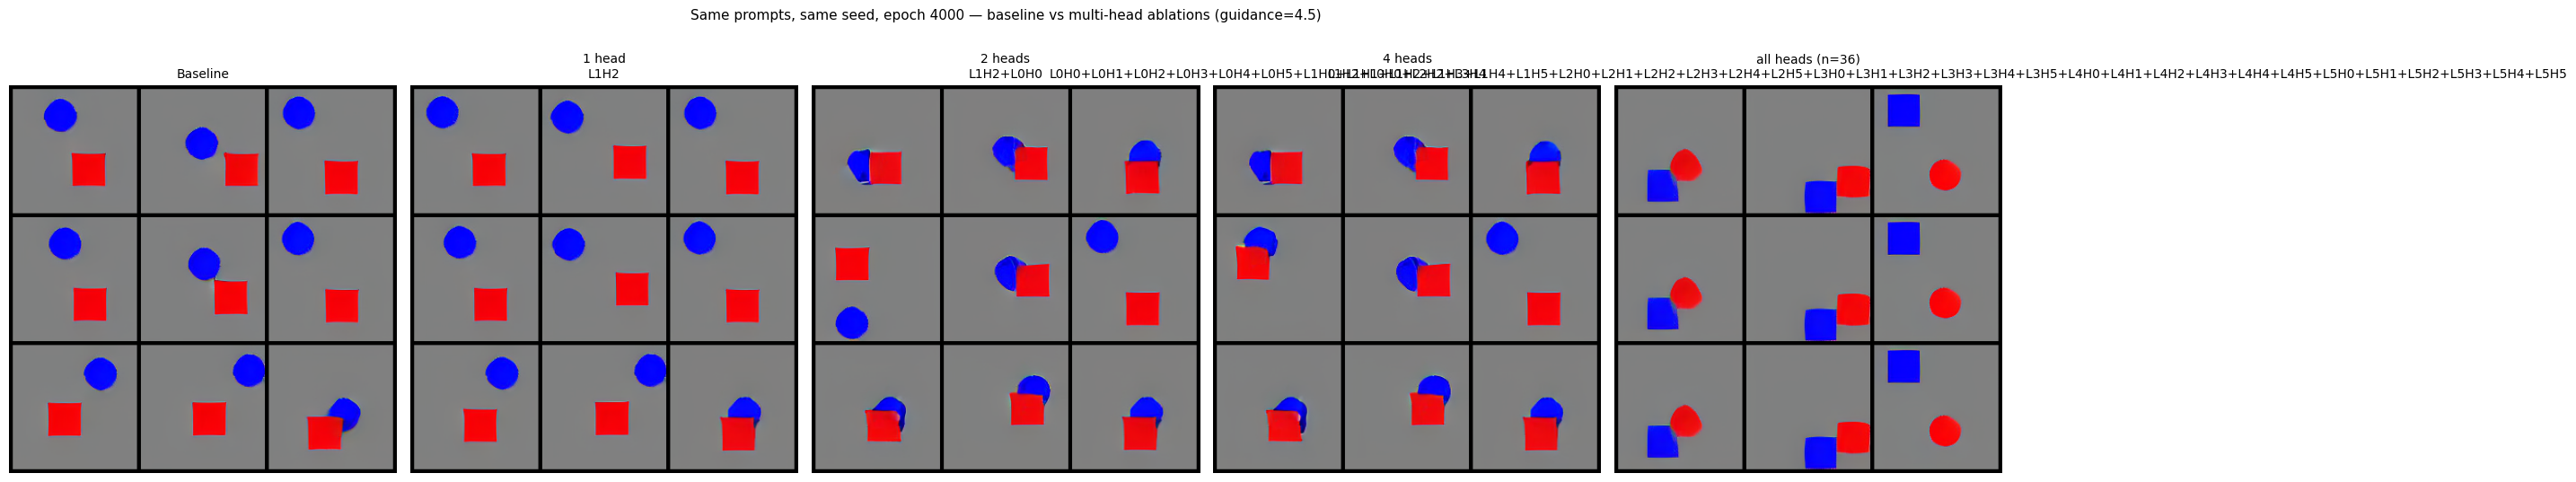

In [ ]:
# Qualitative image grid: baseline vs multi-head ablations
import ast
import gc
import glob
import torch
from os.path import join, basename

from utils.zero_head_ablation_utils import restore_processors, apply_zero_head_ablation_multi
from utils.image_utils import pil_images_to_grid

if "prompts_ablation" not in dir() or len(prompts_ablation) == 0:
    raise RuntimeError("Run the Early Ablation Sweep cell first.")
if "multihead_ablation_df_out" not in dir() or multihead_ablation_df_out is None or multihead_ablation_df_out.empty:
    raise RuntimeError("Run the multi-head ablation sweep cell first.")

qual_prompts = [p for p in prompts_ablation if 'left of' in p or 'right of' in p or ' above ' in p][:3]
if len(qual_prompts) < 3:
    qual_prompts = prompts_ablation[: min(3, len(prompts_ablation))]
print("Qualitative prompts:", qual_prompts)

qual_epoch = int(globals().get("MULTIHEAD_QUAL_EPOCH", multihead_ablation_df_out["epoch"].max()))
qual_guidance_scale = globals().get("MULTIHEAD_QUAL_GUIDANCE_SCALE", globals().get("ABLATION_GUIDANCE_SCALE", 4.5))
qual_n_per_prompt = globals().get("MULTIHEAD_QUAL_N_PER_PROMPT", 3)
qual_n_steps = globals().get("MULTIHEAD_N_STEPS", 14)

if "ckpt_files_ablation" not in dir() or not ckpt_files_ablation:
    ckpt_files_ablation = sorted(
        glob.glob(join(ckptdir, "*.pth")),
        key=lambda p: int(basename(p).split("_step_")[-1].split(".pth")[0]) if "_step_" in p else 0,
    )

rows_epoch = multihead_ablation_df_out[multihead_ablation_df_out["epoch"] == qual_epoch].sort_values("condition_sort_key")
if rows_epoch.empty:
    raise RuntimeError(f"No multi-head rows found for qual epoch {qual_epoch}.")

ckpt_name = rows_epoch.iloc[0]["checkpoint"]
ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt
gc.collect()

uncond = embedding_cache_ablation[""]
uncond_emb = uncond["caption_embeds"].to(device=device, dtype=compute_dtype)
uncond_mask = uncond["emb_mask"].to(device=device)


def gen_images_for_prompts(prompts, n_per_prompt):
    images = []
    for prompt in prompts:
        cached = None
        for k in embedding_cache_ablation:
            if k != "" and k.endswith(f"::{prompt}"):
                cached = embedding_cache_ablation[k]
                break
        if cached is None:
            continue
        cap = cached["caption_embeds"].to(device=device, dtype=compute_dtype)
        mask = cached["emb_mask"].to(device=device)
        gen_dev = "cpu" if str(device) == "mps" else device
        out = pipeline(
            num_inference_steps=qual_n_steps,
            num_images_per_prompt=n_per_prompt,
            generator=torch.Generator(device=gen_dev).manual_seed(42),
            guidance_scale=qual_guidance_scale,
            prompt_embeds=cap,
            prompt_attention_mask=mask,
            negative_prompt=None,
            negative_prompt_embeds=uncond_emb,
            negative_prompt_attention_mask=uncond_mask,
            use_resolution_binning=False,
            prompt_dtype=compute_dtype,
            verbose=False,
        )
        images.extend(out.images)
    return images


conditions = [("Baseline", [])]
for _, row in rows_epoch.iterrows():
    pairs = ast.literal_eval(row["layer_head_pairs"])
    label = row["condition_label"]
    head_str = row["selected_head_labels"]
    conditions.append((f"{label}\n{head_str}", pairs))

fig, axes = plt.subplots(1, len(conditions), figsize=(4.5 * len(conditions), 5.5))
if len(conditions) == 1:
    axes = [axes]

for ax, (label, pairs) in zip(axes, conditions):
    orig_procs = None
    if pairs:
        orig_procs = apply_zero_head_ablation_multi(pipeline.transformer, pairs)
    try:
        imgs = gen_images_for_prompts(qual_prompts, qual_n_per_prompt)
    finally:
        if orig_procs is not None:
            restore_processors(pipeline.transformer, orig_procs)
    grid = pil_images_to_grid(imgs, grid_size=(qual_n_per_prompt, len(qual_prompts)), padding=4)
    ax.imshow(grid)
    ax.axis("off")
    ax.set_title(label, fontsize=10)

plt.suptitle(
    f"Same prompts, same seed, epoch {qual_epoch} — baseline vs multi-head ablations (guidance={qual_guidance_scale})",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()


### Perturbation sensitivity (noise instead of full ablation)

Add small Gaussian noise to the relation head instead of zeroing. Sweep noise scale and plot accuracy drop.

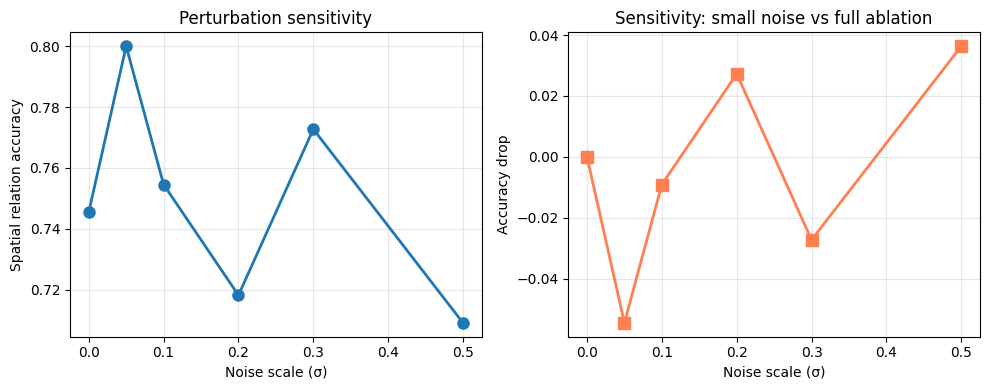

 noise_scale  accuracy      drop
        0.00  0.745455  0.000000
        0.05  0.800000 -0.054545
        0.10  0.754545 -0.009091
        0.20  0.718182  0.027273
        0.30  0.772727 -0.027273
        0.50  0.709091  0.036364


In [ ]:
ABLATION_GUIDANCE_SCALE = globals().get("ABLATION_GUIDANCE_SCALE", 4.5)
# Perturbation sensitivity: accuracy vs noise scale
import importlib
import utils.zero_head_ablation_utils as _zhu
importlib.reload(_zhu)
from utils.zero_head_ablation_utils import apply_noise_head_perturbation, restore_processors

noise_scales = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]
layer_idx = int(ablation_df_out.iloc[-1]['layer_idx']) if not ablation_df_out.empty else 0
head_idx = int(ablation_df_out.iloc[-1]['head_idx']) if not ablation_df_out.empty else 0

# Baseline (noise_scale=0)
eval_base, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
    pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
    num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
    generator_seed=42, device=device, weight_dtype=compute_dtype, show_prompt_progress=False,
)
acc_baseline = eval_base["spatial_relationship"].mean()

perturb_results = []
for ns in noise_scales:
    if ns == 0:
        perturb_results.append({"noise_scale": ns, "accuracy": acc_baseline, "drop": 0.0})
        continue
    orig = apply_noise_head_perturbation(pipeline.transformer, layer_idx, [head_idx], noise_scale=ns)
    eval_p, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=14, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype, show_prompt_progress=False,
    )
    restore_processors(pipeline.transformer, orig)
    acc = eval_p["spatial_relationship"].mean()
    perturb_results.append({"noise_scale": ns, "accuracy": acc, "drop": acc_baseline - acc})

perturb_df = pd.DataFrame(perturb_results)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(perturb_df["noise_scale"], perturb_df["accuracy"], 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Noise scale (σ)')
axes[0].set_ylabel('Spatial relation accuracy')
axes[0].set_title('Perturbation sensitivity')
axes[0].grid(True, alpha=0.3)

axes[1].plot(perturb_df["noise_scale"], perturb_df["drop"], 's-', color='coral', linewidth=2, markersize=8)
axes[1].set_xlabel('Noise scale (σ)')
axes[1].set_ylabel('Accuracy drop')
axes[1].set_title('Sensitivity: small noise vs full ablation')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(perturb_df.to_string(index=False))


### Compensation experiment: heatmaps throughout training

At each checkpoint, ablate the relation head only, then relation head + each other head (same layer). Heatmap: rows = epochs, columns = heads; color = spatial accuracy when that head is also ablated. **Low accuracy (red) = that head was compensating.** If "heat" moves from one head to another over training, compensation is redistributed.

[1/4] Epoch 500  rel_head=L2H0
[2/4] Epoch 1000  rel_head=L1H2
[3/4] Epoch 2000  rel_head=L1H2
[4/4] Epoch 4000  rel_head=L1H2


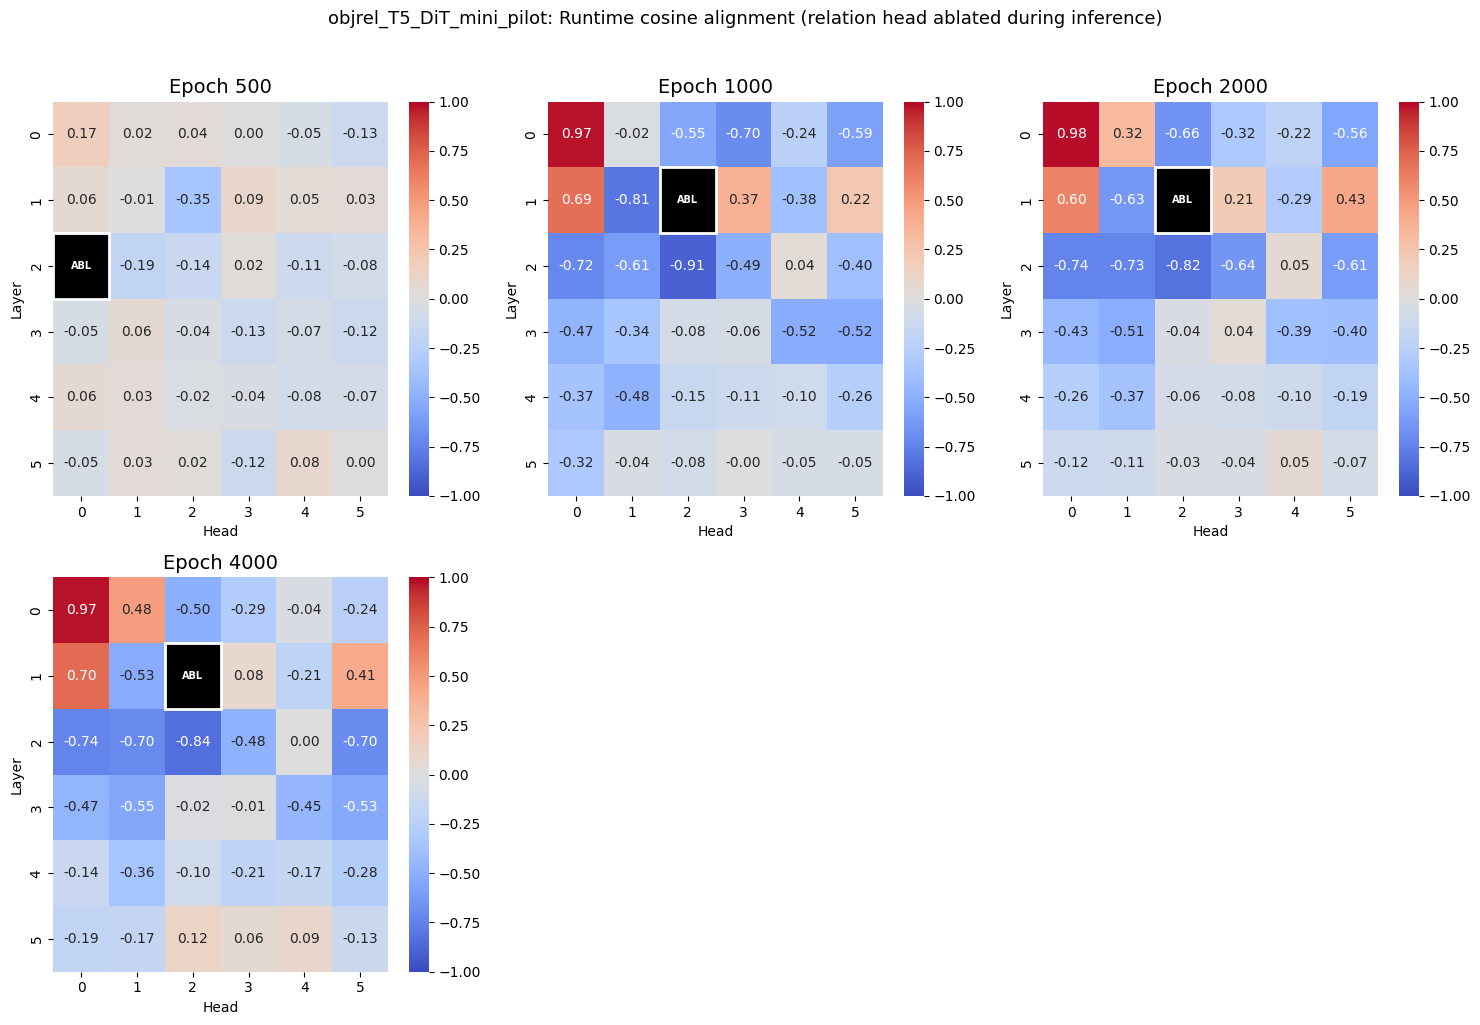

Plotting 9 epochs: [np.int64(500), np.int64(600), np.int64(700), np.int64(750), np.int64(800), np.int64(900), np.int64(1000), np.int64(2000), np.int64(4000)]
  [1/9] Epoch 500  rel_head=L2H0
  [2/9] Epoch 600  rel_head=L2H1
  [3/9] Epoch 700  rel_head=L1H2
  [4/9] Epoch 750  rel_head=L1H2
  [5/9] Epoch 800  rel_head=L1H2
  [6/9] Epoch 900  rel_head=L1H2
  [7/9] Epoch 1000  rel_head=L1H2
  [8/9] Epoch 2000  rel_head=L1H2
  [9/9] Epoch 4000  rel_head=L1H2


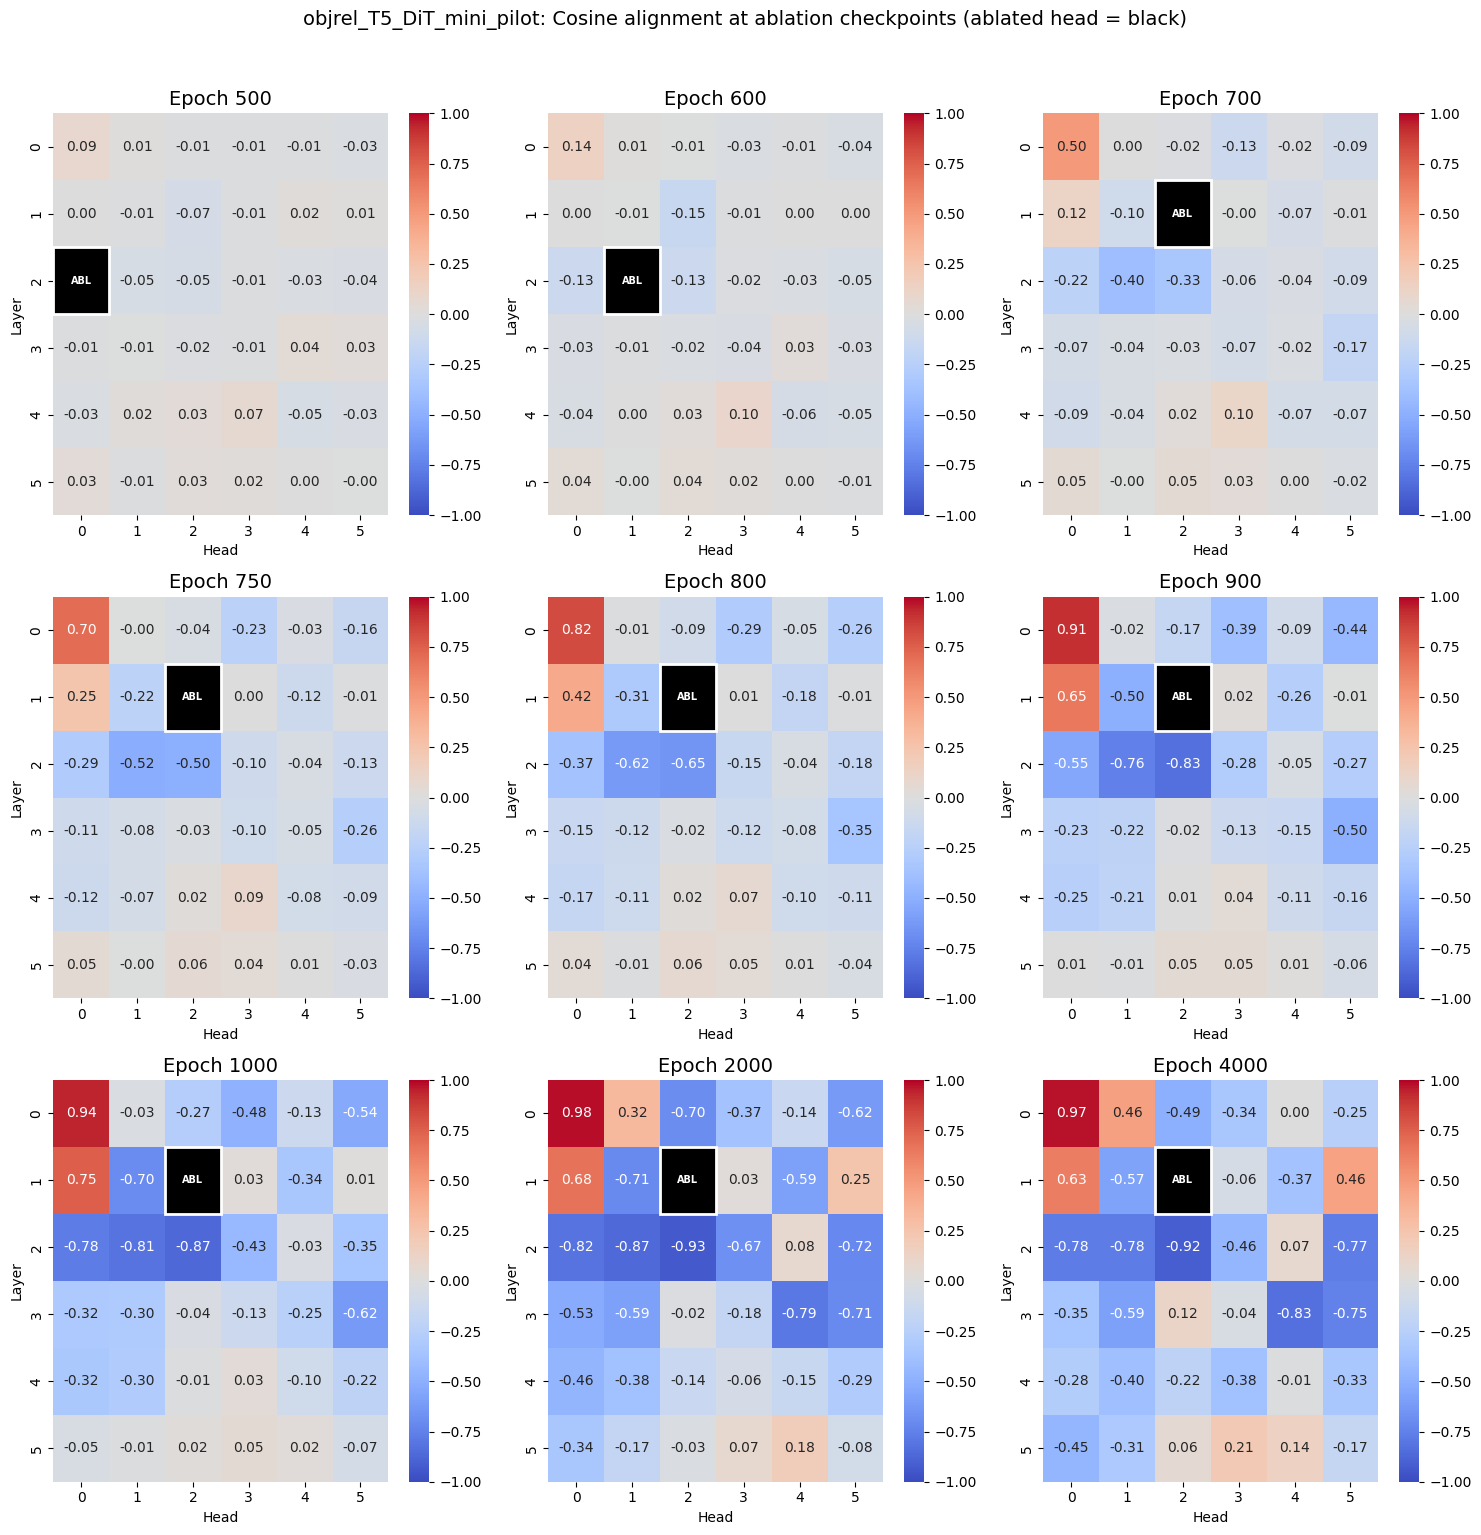

In [ ]:
# Compensation: RUNTIME cosine alignment with relation head ablated.
# Runs ONE forward pass per checkpoint with the relation head zeroed during inference.
# Hooks capture actual hidden_states at each layer's cross-attention, then computes
# alignment from those. Layers AFTER the ablated head get genuinely different Q vectors
# because the residual stream was modified by the ablation.
from itertools import product
from matplotlib.patches import Rectangle
from utils.zero_head_ablation_utils import apply_zero_head_ablation, restore_processors
import gc

comp_epochs_to_show = [500, 1000, 2000, 4000]

hidden_size = transformer_config["hidden_size"]
head_num = transformer_config["num_heads"]
layer_num = transformer_config["depth"]
base_size = 16 // 2
head_dim = hidden_size // head_num

rel_head_per_epoch = {}
for _, r in ablation_df_out.iterrows():
    rel_head_per_epoch[int(r["epoch"])] = (int(r["layer_idx"]), int(r["head_idx"]))

ablation_rows = ablation_df_out[ablation_df_out["epoch"].isin(comp_epochs_to_show)].reset_index(drop=True)
if ablation_rows.empty:
    all_ep = sorted(ablation_df_out["epoch"].unique())
    ablation_rows = ablation_df_out[ablation_df_out["epoch"].isin(
        [all_ep[i] for i in [0, len(all_ep)//3, 2*len(all_ep)//3, -1]])].reset_index(drop=True)

# Grab one prompt's embeddings for the forward pass
prompt_for_fwd = prompts_ablation[0]
cached_emb = None
for k in embedding_cache_ablation:
    if k != "" and k.endswith(f"::{prompt_for_fwd}"):
        cached_emb = embedding_cache_ablation[k]
        break
assert cached_emb is not None, f"No cached embedding for {prompt_for_fwd}"
uncond_data = embedding_cache_ablation[""]

# K side: relation direction (same as FIXED direction cell)
target_np = effect_vecs_fixed["spatial_relationship"][:, :]
target_tensor = torch.from_numpy(target_np)[None, :].to(dtype=compute_dtype, device=device)

n_total = len(ablation_rows)
comp_records = []

for row_i, abl_row in ablation_rows.iterrows():
    epoch = int(abl_row["epoch"])
    ckpt_name = abl_row["checkpoint"]
    rel_layer, rel_head_idx = int(abl_row["layer_idx"]), int(abl_row["head_idx"])
    print(f"[{row_i+1}/{n_total}] Epoch {epoch}  rel_head=L{rel_layer}H{rel_head_idx}")

    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt; gc.collect()

    captured_hs = {}
    hooks = []
    for name, block in pipeline.transformer.transformer_blocks.named_children():
        lidx = int(name)
        def _make_hook(layer_idx):
            def _hook(module, inp, out):
                captured_hs[layer_idx] = inp[0].detach().clone()
            return _hook
        hooks.append(block.attn2.register_forward_hook(_make_hook(lidx)))

    orig_procs = apply_zero_head_ablation(pipeline.transformer, rel_layer, [rel_head_idx])

    cap = cached_emb["caption_embeds"].to(device=device, dtype=compute_dtype)
    emb_mask = cached_emb["emb_mask"].to(device=device)
    uc_emb = uncond_data["caption_embeds"].to(device=device, dtype=compute_dtype)
    uc_mask = uncond_data["emb_mask"].to(device=device)
    gen_dev = "cpu" if str(device) == "mps" else device
    with torch.no_grad():
        _ = pipeline(
            num_inference_steps=2, num_images_per_prompt=1,
            generator=torch.Generator(device=gen_dev).manual_seed(42),
            guidance_scale=1.0, prompt_embeds=cap, prompt_attention_mask=emb_mask,
            negative_prompt=None, negative_prompt_embeds=uc_emb,
            negative_prompt_attention_mask=uc_mask,
            use_resolution_binning=False, prompt_dtype=compute_dtype, verbose=False,
        )

    for h in hooks:
        h.remove()
    restore_processors(pipeline.transformer, orig_procs)

    with torch.no_grad():
        for layer_idx in range(layer_num):
            if layer_idx not in captured_hs:
                continue
            hs = captured_hs[layer_idx]
            Q_all = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_q(hs)
            K_all = pipeline.transformer.transformer_blocks[layer_idx].attn2.to_k(target_tensor)
            for head_idx in range(head_num):
                Q_h = Q_all[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
                K_h = K_all[0, :, head_idx*head_dim:(head_idx+1)*head_dim]
                inner_prod_mat = Q_h @ K_h.T
                align_df = eval_ramp_alignment_all(inner_prod_mat, levels_map_fixed["spatial_relationship"])
                comp_records.append({
                    "epoch": epoch, "layer_idx": layer_idx, "head_idx": head_idx,
                    "cosine": align_df["cosine"].mean(),
                })

comp_df = pd.DataFrame(comp_records)

epochs_plot = sorted(comp_df["epoch"].unique())
n_ckpts = len(epochs_plot)
ncols = min(3, n_ckpts)
nrows = (n_ckpts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

for idx, epoch in enumerate(epochs_plot):
    r, c = idx // ncols, idx % ncols
    ax = axes[r, c]
    df_sub = comp_df[comp_df["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")

    mask_arr = np.zeros_like(heatmap_data.values, dtype=bool)
    rly, rhd = rel_head_per_epoch.get(epoch, (None, None))
    if rly is not None and rly < mask_arr.shape[0] and rhd < mask_arr.shape[1]:
        mask_arr[rly, rhd] = True

    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax,
                vmin=-1, vmax=1, cbar=True, mask=mask_arr)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")
    if rly is not None:
        ax.add_patch(Rectangle((rhd, rly), 1, 1, fill=True, facecolor="black",
                               edgecolor="white", linewidth=2, zorder=10))
        ax.text(rhd + 0.5, rly + 0.5, "ABL", ha="center", va="center",
                fontsize=7, color="white", fontweight="bold", zorder=11)

for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Runtime cosine alignment (relation head ablated during inference)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

ckpt = torch.load(join(ckptdir, ablation_rows.iloc[-1]["checkpoint"]),
                  map_location="cpu", weights_only=False)
pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
del ckpt; gc.collect()
rel_head_per_epoch = {}
for _, r in ablation_df_out.iterrows():
    rel_head_per_epoch[int(r["epoch"])] = (int(r["layer_idx"]), int(r["head_idx"]))

# Build combined alignment df for ablation epochs, using same source as ablation sweep
ablation_epochs = sorted(ablation_df_out["epoch"].unique())
comp_df_parts = []
for epoch in ablation_epochs:
    if epoch <= 1000 and "evolution_df_em" in dir():
        df_ep = evolution_df_em[evolution_df_em["epoch"] == epoch]
    else:
        df_ep = evolution_df[evolution_df["epoch"] == epoch]
    if not df_ep.empty:
        comp_df_parts.append(df_ep)
comp_df = pd.concat(comp_df_parts, ignore_index=True)
epochs_to_plot = sorted(comp_df["epoch"].unique())

print(f"Plotting {len(epochs_to_plot)} epochs: {list(epochs_to_plot)}")

# Plot — same style as first cosine alignment heatmap cell
n_ckpts = len(epochs_to_plot)
ncols = 3
nrows = (n_ckpts + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes)

for idx, epoch in enumerate(epochs_to_plot):
    row, col = idx // ncols, idx % ncols
    ax = axes[row, col]
    df_sub = comp_df[comp_df["epoch"] == epoch]
    heatmap_data = df_sub.set_index(["layer_idx", "head_idx"])["cosine"].unstack(level="head_idx")

    # Mask the ablated head
    mask = np.zeros_like(heatmap_data.values, dtype=bool)
    rel_ly, rel_hd = None, None
    if epoch in rel_head_per_epoch:
        rel_ly, rel_hd = rel_head_per_epoch[epoch]
        if rel_ly < mask.shape[0] and rel_hd < mask.shape[1]:
            mask[rel_ly, rel_hd] = True

    sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", ax=ax,
                vmin=-1, vmax=1, cbar=True, mask=mask)
    ax.set_title(f"Epoch {epoch}", fontsize=14)
    ax.set_xlabel("Head")
    ax.set_ylabel("Layer")

    if rel_ly is not None:
        ax.add_patch(Rectangle((rel_hd, rel_ly), 1, 1, fill=True, facecolor="black",
                               edgecolor="white", linewidth=2, zorder=10))
        ax.text(rel_hd + 0.5, rel_ly + 0.5, "ABL", ha="center", va="center",
                fontsize=7, color="white", fontweight="bold", zorder=11)
    print(f"  [{idx+1}/{n_ckpts}] Epoch {epoch}  rel_head=L{rel_ly}H{rel_hd}")

for idx in range(n_ckpts, nrows * ncols):
    axes.flatten()[idx].set_visible(False)
plt.suptitle(f"{model_run_name}: Cosine alignment at ablation checkpoints (ablated head = black)",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Step-dependent ablation (per-step temporal causality)

Ablate the relation head **only at step i** (i=0..13). Plot accuracy vs step to see when the head matters most during denoising.

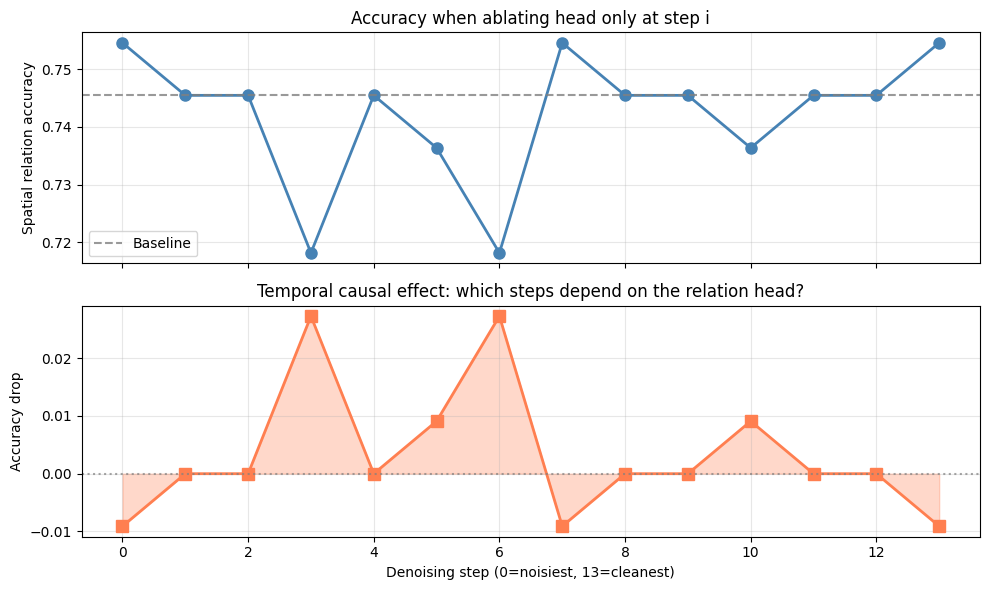

In [ ]:
ABLATION_GUIDANCE_SCALE = globals().get("ABLATION_GUIDANCE_SCALE", 4.5)
# Step-dependent ablation: per-step accuracy (when does the head matter?)
# Ablate relation head ONLY at step i (step_range=(i,i)) for each i in 0..13
from utils.zero_head_ablation_utils import apply_zero_head_ablation, restore_processors

num_steps = 14
layer_idx = int(ablation_df_out.iloc[-1]['layer_idx']) if not ablation_df_out.empty else 0
head_idx = int(ablation_df_out.iloc[-1]['head_idx']) if not ablation_df_out.empty else 0

# Baseline
eval_baseline, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
    pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
    num_images=N_IMAGES_PER_PROMPT, num_inference_steps=num_steps, guidance_scale=ABLATION_GUIDANCE_SCALE,
    generator_seed=42, device=device, weight_dtype=compute_dtype, show_prompt_progress=False,
)
acc_baseline = eval_baseline["spatial_relationship"].mean()

# Per-step ablation: ablate only at step i
step_accs, step_drops = [], []
for step_i in range(num_steps):
    orig_procs = apply_zero_head_ablation(
        pipeline.transformer, layer_idx, [head_idx], step_range=(step_i, step_i)
    )
    eval_abl, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline, prompts_ablation, scene_infos_ablation, embedding_cache_ablation,
        num_images=N_IMAGES_PER_PROMPT, num_inference_steps=num_steps, guidance_scale=ABLATION_GUIDANCE_SCALE,
        generator_seed=42, device=device, weight_dtype=compute_dtype, show_prompt_progress=False,
    )
    restore_processors(pipeline.transformer, orig_procs)
    acc = eval_abl["spatial_relationship"].mean()
    step_accs.append(acc)
    step_drops.append(acc_baseline - acc)

# Line plot: accuracy drop vs denoising step (temporal causal curve)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
steps = np.arange(num_steps)
axes[0].plot(steps, step_accs, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axhline(acc_baseline, color='gray', linestyle='--', alpha=0.8, label='Baseline')
axes[0].set_ylabel('Spatial relation accuracy')
axes[0].set_title('Accuracy when ablating head only at step i')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(steps, step_drops, 's-', color='coral', linewidth=2, markersize=8)
axes[1].axhline(0, color='gray', linestyle=':', alpha=0.7)
axes[1].fill_between(steps, 0, step_drops, alpha=0.3, color='coral')
axes[1].set_xlabel('Denoising step (0=noisiest, 13=cleanest)')
axes[1].set_ylabel('Accuracy drop')
axes[1].set_title('Temporal causal effect: which steps depend on the relation head?')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Trace downstream relation-head readers: candidate discovery

Screen later heads by how their training trajectories covary with the source relation head and with checkpoint-level behavior metrics. This is the low-cost candidate-discovery stage before causal tests.





















































Trace behavior trajectories: 100%|██████████| 198/198 [00:53<00:00,  3.69prompt/s, epoch=4000, stage=eval]

Rank downstream candidates: 100%|██████████| 24/24 [00:00<00:00, 447.43head/s]

Source relation head: L1H2
Behavior trajectory summary:


,epoch,checkpoint,step,spatial_relationship,spatial_relationship_loose,overall,overall_loose,unique_binding,exist_binding,Dx_abs_mean,Dy_abs_mean,Dx_mean,Dy_mean
0,500,epoch_500_step_20000.pth,20000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
1,600,epoch_600_step_24000.pth,24000,0.045455,0.121212,0.045455,0.121212,0.333333,0.333333,43.090909,67.909091,-43.090909,-67.909091
2,700,epoch_700_step_28000.pth,28000,0.045455,0.121212,0.045455,0.121212,0.333333,0.333333,43.681818,67.954545,-43.681818,-67.954545
3,750,epoch_750_step_30000.pth,30000,0.045455,0.121212,0.045455,0.121212,0.333333,0.333333,43.772727,68.318182,-43.772727,-68.318182
4,800,epoch_800_step_32000.pth,32000,0.045455,0.121212,0.045455,0.121212,0.333333,0.333333,43.363636,68.772727,-43.363636,-68.772727
5,900,epoch_900_step_36000.pth,36000,0.151515,0.242424,0.151515,0.242424,0.500000,0.500000,36.484848,52.757576,-32.181818,-47.909091
6,1000,epoch_1000_step_40000.pth,40000,0.196970,0.333333,0.196970,0.333333,0.651515,0.651515,27.558140,40.906977,-21.837209,-31.837209
7,2000,epoch_2000_step_80000.pth,80000,0.515152,0.818182,0.515152,0.818182,0.833333,0.833333,34.400000,51.327273,1.090909,0.018182
8,4000,epoch_4000_step_160000.pth,160000,0.742424,0.878788,0.742424,0.878788,0.878788,0.878788,31.603448,43.534483,-0.810345,5.017241


Correlation table: source head vs all downstream candidates


,head_label,corr_source_alignment,corr_spatial_relationship,corr_unique_binding,corr_exist_binding,corr_Dx_abs_mean,corr_Dy_abs_mean,candidate_turn_on_epoch,turn_on_delay,composite_score
0,L3H5,0.876082,0.833127,0.929882,0.929882,-0.858137,-0.882341,1000.0,250.0,0.587585
1,L2H2,0.948189,0.704283,0.874269,0.874269,-0.796387,-0.817424,900.0,150.0,0.587172
2,L2H1,0.967757,0.644521,0.861415,0.861415,-0.772960,-0.786408,900.0,150.0,0.584367
3,L2H0,0.836620,0.802840,0.931428,0.931428,-0.913440,-0.920692,1000.0,250.0,0.578862
4,L4H1,0.769940,0.896509,0.932782,0.932782,-0.871612,-0.895062,1000.0,250.0,0.558563
5,L4H5,0.747100,0.942962,0.957985,0.957985,-0.832287,-0.863452,2000.0,1250.0,0.552678
6,L4H0,0.798603,0.726640,0.880059,0.880059,-0.785833,-0.783407,2000.0,1250.0,0.536601
7,L3H0,0.761628,0.816462,0.912041,0.912041,-0.778030,-0.784943,2000.0,1250.0,0.534111
8,L2H3,0.739634,0.820898,0.910110,0.910110,-0.814726,-0.819151,2000.0,1250.0,0.531544
9,L3H1,0.694341,0.953249,0.935977,0.935977,-0.766688,-0.799335,2000.0,1250.0,0.524195


Top 8 ranked candidates


,layer_idx,head_idx,head_label,n_epochs,candidate_mean_alignment,candidate_max_alignment,corr_source_alignment,source_turn_on_epoch,candidate_turn_on_epoch,turn_on_delay,corr_spatial_relationship,corr_unique_binding,corr_exist_binding,corr_Dx_abs_mean,corr_Dy_abs_mean,behavior_corr_score,composite_score
0,3,5,L3H5,9,0.379182,0.749653,0.876082,750.0,1000.0,250.0,0.833127,0.929882,0.929882,-0.858137,-0.882341,0.886674,0.587585
1,2,2,L2H2,9,0.580118,0.934349,0.948189,750.0,900.0,150.0,0.704283,0.874269,0.874269,-0.796387,-0.817424,0.813326,0.587172
2,2,1,L2H1,9,0.553419,0.866310,0.967757,750.0,900.0,150.0,0.644521,0.861415,0.861415,-0.772960,-0.786408,0.785344,0.584367
3,2,0,L2H0,9,0.446511,0.816343,0.836620,750.0,1000.0,250.0,0.802840,0.931428,0.931428,-0.913440,-0.920692,0.899966,0.578862
4,4,1,L4H1,9,0.169848,0.397118,0.769940,750.0,1000.0,250.0,0.896509,0.932782,0.932782,-0.871612,-0.895062,0.905749,0.558563
5,4,5,L4H5,9,0.149832,0.330521,0.747100,750.0,2000.0,1250.0,0.942962,0.957985,0.957985,-0.832287,-0.863452,0.910934,0.552678
6,4,0,L4H0,9,0.196321,0.464187,0.798603,750.0,2000.0,1250.0,0.726640,0.880059,0.880059,-0.785833,-0.783407,0.811200,0.536601
7,3,0,L3H0,9,0.200026,0.526868,0.761628,750.0,2000.0,1250.0,0.816462,0.912041,0.912041,-0.778030,-0.784943,0.840704,0.534111


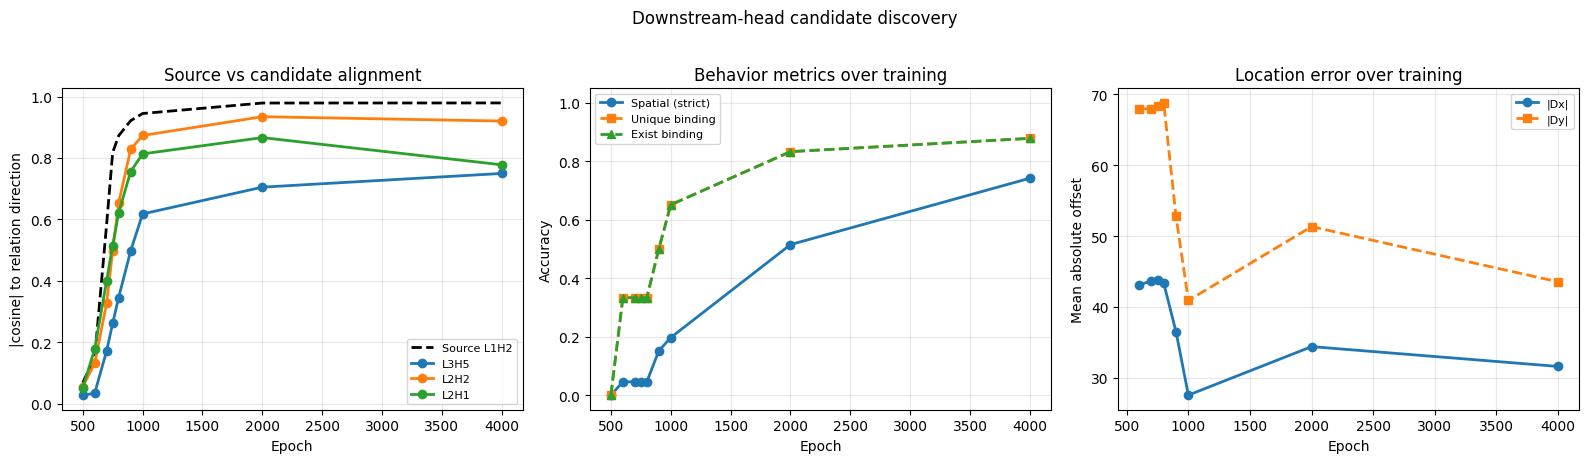

In [45]:
# Candidate discovery via training-trajectory correlation (Method B)
import gc
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from os.path import join, basename
from IPython.display import display
from tqdm.auto import tqdm

from utils.eval_cached_embeddings import evaluate_pipeline_on_prompts_with_cached_embeddings
from utils.downstream_head_tracing import (
    build_head_metric_trajectory_df,
    rank_downstream_candidates_by_correlation,
)

SOURCE_REL_HEAD = globals().get("SOURCE_REL_HEAD", (1, 2))
TRACE_CANDIDATE_LAYERS = globals().get("TRACE_CANDIDATE_LAYERS", "later_only")
TRACE_DEV_CHECKPOINTS = globals().get(
    "TRACE_DEV_CHECKPOINTS",
    ABLATION_CHECKPOINTS if "ABLATION_CHECKPOINTS" in dir() and ABLATION_CHECKPOINTS is not None else ckpt_files_ablation,
)
TRACE_N_IMAGES_PER_PROMPT = globals().get("TRACE_N_IMAGES_PER_PROMPT", min(globals().get("N_IMAGES_PER_PROMPT", 5), 3))
TRACE_N_STEPS = globals().get("TRACE_N_STEPS", 14)
TRACE_GUIDANCE_SCALE = globals().get("TRACE_GUIDANCE_SCALE", globals().get("ABLATION_GUIDANCE_SCALE", 4.5))
TRACE_TOP_CANDIDATES = globals().get("TRACE_TOP_CANDIDATES", 8)

if "prompts_ablation" not in dir() or len(prompts_ablation) == 0:
    raise RuntimeError("Run the Early Ablation Sweep section first so prompts_ablation / scene_infos_ablation are defined.")
if "evolution_df" not in dir() or evolution_df is None or evolution_df.empty:
    raise RuntimeError("Run the alignment evolution cells first so evolution_df is available.")

if "ckpt_files_ablation" not in dir() or not ckpt_files_ablation:
    ckpt_files_ablation = sorted(
        glob.glob(join(ckptdir, "*.pth")),
        key=lambda p: int(basename(p).split("_step_")[-1].split(".pth")[0]) if "_step_" in p else 0,
    )


def summarize_behavior_eval(eval_df):
    out = {}
    for col in [
        "spatial_relationship", "spatial_relationship_loose", "overall", "overall_loose",
        "unique_binding", "exist_binding",
    ]:
        out[col] = float(eval_df[col].mean()) if col in eval_df.columns and not eval_df.empty else np.nan
    out["Dx_abs_mean"] = float(eval_df["Dx"].abs().mean()) if "Dx" in eval_df.columns and not eval_df.empty else np.nan
    out["Dy_abs_mean"] = float(eval_df["Dy"].abs().mean()) if "Dy" in eval_df.columns and not eval_df.empty else np.nan
    out["Dx_mean"] = float(eval_df["Dx"].mean()) if "Dx" in eval_df.columns and not eval_df.empty else np.nan
    out["Dy_mean"] = float(eval_df["Dy"].mean()) if "Dy" in eval_df.columns and not eval_df.empty else np.nan
    return out


trace_behavior_records = []
trace_eval_pbar = tqdm(
    total=len(TRACE_DEV_CHECKPOINTS) * len(prompts_ablation),
    desc="Trace behavior trajectories",
    unit="prompt",
    mininterval=1,
)
for ckpt_name in TRACE_DEV_CHECKPOINTS:
    epoch = int(basename(ckpt_name).split("_")[1])
    trace_eval_pbar.set_postfix(epoch=epoch, stage="eval")

    ckpt = torch.load(join(ckptdir, ckpt_name), map_location="cpu", weights_only=False)
    pipeline.transformer.load_state_dict(state_dict_convert(ckpt["state_dict_ema"]))
    pipeline.transformer = pipeline.transformer.to(device=device, dtype=compute_dtype)
    del ckpt
    gc.collect()

    eval_df, _ = evaluate_pipeline_on_prompts_with_cached_embeddings(
        pipeline,
        prompts_ablation,
        scene_infos_ablation,
        embedding_cache_ablation,
        num_images=TRACE_N_IMAGES_PER_PROMPT,
        num_inference_steps=TRACE_N_STEPS,
        guidance_scale=TRACE_GUIDANCE_SCALE,
        generator_seed=42,
        device=device,
        weight_dtype=compute_dtype,
        show_prompt_progress=False,
        progress_callback=lambda: trace_eval_pbar.update(1),
    )
    trace_behavior_records.append(
        {
            "epoch": epoch,
            "checkpoint": basename(ckpt_name),
            "step": int(basename(ckpt_name).split("_step_")[-1].split(".pth")[0]) if "_step_" in basename(ckpt_name) else np.nan,
            **summarize_behavior_eval(eval_df),
        }
    )
trace_eval_pbar.close()

trace_behavior_df = pd.DataFrame(trace_behavior_records).sort_values("epoch").reset_index(drop=True)

align_parts = []
for df_name in ["evolution_df_em", "evolution_df"]:
    if df_name in dir() and globals()[df_name] is not None and not globals()[df_name].empty:
        align_parts.append(globals()[df_name].copy())
if not align_parts:
    raise RuntimeError("Need evolution_df and/or evolution_df_em for downstream-head tracing.")
trace_alignment_df = pd.concat(align_parts, ignore_index=True).drop_duplicates(subset=["epoch", "layer_idx", "head_idx"]).sort_values(["epoch", "layer_idx", "head_idx"])
trace_alignment_df = trace_alignment_df[trace_alignment_df["epoch"].isin(trace_behavior_df["epoch"].unique())].copy()


trace_head_metric_df = build_head_metric_trajectory_df(
    trace_alignment_df,
    trace_behavior_df,
    SOURCE_REL_HEAD,
    candidate_layers=TRACE_CANDIDATE_LAYERS,
    alignment_col="cosine",
    behavior_cols=[
        "spatial_relationship", "spatial_relationship_loose", "overall", "overall_loose",
        "unique_binding", "exist_binding", "Dx_abs_mean", "Dy_abs_mean",
    ],
)
trace_candidate_rank_df = rank_downstream_candidates_by_correlation(
    trace_head_metric_df,
    source_alignment_col="source_abs_cosine",
    candidate_alignment_col="alignment_abs",
    behavior_cols=["spatial_relationship", "unique_binding", "exist_binding", "Dx_abs_mean", "Dy_abs_mean"],
    show_progress=True,
    progress_desc="Rank downstream candidates",
)
trace_candidate_corr_table_df = trace_candidate_rank_df[
    [
        "head_label",
        "corr_source_alignment",
        "corr_spatial_relationship",
        "corr_unique_binding",
        "corr_exist_binding",
        "corr_Dx_abs_mean",
        "corr_Dy_abs_mean",
        "candidate_turn_on_epoch",
        "turn_on_delay",
        "composite_score",
    ]
].copy()

print(f"Source relation head: L{SOURCE_REL_HEAD[0]}H{SOURCE_REL_HEAD[1]}")
print("Behavior trajectory summary:")
display(trace_behavior_df)
print("Correlation table: source head vs all downstream candidates")
display(trace_candidate_corr_table_df)
print(f"Top {min(TRACE_TOP_CANDIDATES, len(trace_candidate_rank_df))} ranked candidates")
display(trace_candidate_rank_df.head(TRACE_TOP_CANDIDATES))

plot_candidates = trace_candidate_rank_df.head(min(3, len(trace_candidate_rank_df)))
if not plot_candidates.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    source_curve = (
        trace_head_metric_df[["epoch", "source_abs_cosine"]]
        .drop_duplicates()
        .sort_values("epoch")
    )

    axes[0].plot(source_curve["epoch"], source_curve["source_abs_cosine"], "k--", linewidth=2, label=f"Source L{SOURCE_REL_HEAD[0]}H{SOURCE_REL_HEAD[1]}")
    for _, cand in plot_candidates.iterrows():
        sub = trace_head_metric_df[
            (trace_head_metric_df["layer_idx"] == int(cand["layer_idx"])) &
            (trace_head_metric_df["head_idx"] == int(cand["head_idx"]))
        ].sort_values("epoch")
        axes[0].plot(sub["epoch"], sub["alignment_abs"], "o-", linewidth=2, label=cand["head_label"])
    axes[0].set_title("Source vs candidate alignment")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("|cosine| to relation direction")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].plot(trace_behavior_df["epoch"], trace_behavior_df["spatial_relationship"], "o-", linewidth=2, label="Spatial (strict)")
    axes[1].plot(trace_behavior_df["epoch"], trace_behavior_df["unique_binding"], "s--", linewidth=2, label="Unique binding")
    axes[1].plot(trace_behavior_df["epoch"], trace_behavior_df["exist_binding"], "^--", linewidth=2, label="Exist binding")
    axes[1].set_title("Behavior metrics over training")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=8)

    axes[2].plot(trace_behavior_df["epoch"], trace_behavior_df["Dx_abs_mean"], "o-", linewidth=2, label="|Dx|")
    axes[2].plot(trace_behavior_df["epoch"], trace_behavior_df["Dy_abs_mean"], "s--", linewidth=2, label="|Dy|")
    axes[2].set_title("Location error over training")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Mean absolute offset")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend(fontsize=8)

    plt.suptitle("Downstream-head candidate discovery", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


### Trace downstream relation-head readers: causal verification

Take the top candidate heads from the trajectory screen and test whether they causally matter with source-only, candidate-only, and source+candidate ablations.

In [50]:
# Causal verification with single-head and pair ablations (Method C)
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from utils.downstream_head_tracing import run_pair_ablation_grid

TRACE_PAIR_TOP_N = globals().get("TRACE_PAIR_TOP_N", 2)
TRACE_PAIR_CHECKPOINTS = globals().get(
    "TRACE_PAIR_CHECKPOINTS",
    [TRACE_DEV_CHECKPOINTS[-1]] if len(TRACE_DEV_CHECKPOINTS) > 0 else TRACE_DEV_CHECKPOINTS,
)
TRACE_PAIR_N_IMAGES = globals().get("TRACE_PAIR_N_IMAGES", min(TRACE_N_IMAGES_PER_PROMPT, 2))
TRACE_PAIR_N_STEPS = globals().get("TRACE_PAIR_N_STEPS", TRACE_N_STEPS)
TRACE_PAIR_GUIDANCE_SCALE = globals().get("TRACE_PAIR_GUIDANCE_SCALE", TRACE_GUIDANCE_SCALE)
TRACE_PAIR_MAX_PROMPTS = globals().get("TRACE_PAIR_MAX_PROMPTS", 12)

if "trace_candidate_rank_df" not in dir() or trace_candidate_rank_df is None or trace_candidate_rank_df.empty:
    raise RuntimeError("Run the candidate discovery cell first.")

trace_candidate_heads = [
    (int(row.layer_idx), int(row.head_idx))
    for row in trace_candidate_rank_df.head(TRACE_PAIR_TOP_N).itertuples()
]
trace_pair_prompts = prompts_ablation[:TRACE_PAIR_MAX_PROMPTS]
trace_pair_scene_infos = scene_infos_ablation[:TRACE_PAIR_MAX_PROMPTS]
print("Candidate heads for causal verification:", trace_candidate_heads)
print(f"Quick verification config: {len(TRACE_PAIR_CHECKPOINTS)} checkpoint(s), {len(trace_pair_prompts)} prompt(s), {TRACE_PAIR_N_IMAGES} image(s)/prompt")

trace_pair_summary_df, trace_pair_eval_df = run_pair_ablation_grid(
    pipeline=pipeline,
    ckptdir=ckptdir,
    ckpt_list=TRACE_PAIR_CHECKPOINTS,
    prompts=trace_pair_prompts,
    scene_infos=trace_pair_scene_infos,
    embedding_cache=embedding_cache_ablation,
    source_head=SOURCE_REL_HEAD,
    candidate_heads=trace_candidate_heads,
    state_dict_convert=state_dict_convert,
    device=device,
    weight_dtype=compute_dtype,
    num_images=TRACE_PAIR_N_IMAGES,
    num_inference_steps=TRACE_PAIR_N_STEPS,
    guidance_scale=TRACE_PAIR_GUIDANCE_SCALE,
    generator_seed=42,
    metric_cols=[
        "spatial_relationship", "spatial_relationship_loose", "overall",
        "unique_binding", "exist_binding",
    ],
    show_prompt_progress=False,
    progress_mode="print",
)

show_cols = [
    "epoch", "condition_label", "candidate_head", "spatial_relationship",
    "unique_binding", "exist_binding", "overall",
    "spatial_relationship_delta_from_baseline", "unique_binding_delta_from_baseline",
]
display(trace_pair_summary_df[show_cols])

if not trace_pair_summary_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for cand_head, dfc in trace_pair_summary_df[trace_pair_summary_df["candidate_head"].notna()].groupby("candidate_head"):
        src = dfc[dfc["condition_key"].str.startswith("src__")].sort_values("epoch")
        cand = dfc[dfc["condition_key"].str.startswith("cand__")].sort_values("epoch")
        pair = dfc[dfc["condition_key"].str.startswith("pair__")].sort_values("epoch")
        axes[0].plot(src["epoch"], src["spatial_relationship_delta_from_baseline"], "o-", alpha=0.9, label=f"source only | {cand_head}")
        axes[0].plot(cand["epoch"], cand["spatial_relationship_delta_from_baseline"], "s--", alpha=0.9, label=f"candidate only | {cand_head}")
        axes[0].plot(pair["epoch"], pair["spatial_relationship_delta_from_baseline"], "^-", linewidth=2, alpha=0.9, label=f"pair | {cand_head}")

        axes[1].plot(pair["epoch"], pair["unique_binding_delta_from_baseline"], "o-", alpha=0.9, label=f"binding | {cand_head}")
        axes[1].plot(pair["epoch"], pair["exist_binding_delta_from_baseline"], "s--", alpha=0.9, label=f"exist | {cand_head}")

    axes[0].axhline(0, color="gray", linestyle=":", alpha=0.7)
    axes[0].set_title("Strict spatial drop: source vs candidate vs pair")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Baseline - ablated")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=7, ncol=2)

    axes[1].axhline(0, color="gray", linestyle=":", alpha=0.7)
    axes[1].set_title("Pair-ablation binding effects")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Baseline - ablated")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=7, ncol=2)

    plt.tight_layout()
    plt.show()

Candidate heads for causal verification: [(3, 5), (2, 2), (2, 1)]


Pair ablations:  19%|█▉        | 378/1980 [08:50<37:27,  1.40s/prompt, condition=src__2_1, epoch=600]  


KeyboardInterrupt: 

### Trace downstream relation-head readers: functional characterization and validation

Classify verified downstream heads by whether they affect binding vs placement, then validate the strongest ones on a broader held-out/generalization prompt set.

In [46]:
# Functional characterization (Method E) + held-out/generalization validation
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

from utils.downstream_head_tracing import run_pair_ablation_grid, summarize_functional_effects

TRACE_VALIDATION_TOP_N = globals().get("TRACE_VALIDATION_TOP_N", 2)
TRACE_VALIDATION_N_IMAGES = globals().get("TRACE_VALIDATION_N_IMAGES", min(TRACE_N_IMAGES_PER_PROMPT, 2))
TRACE_VALIDATION_N_STEPS = globals().get("TRACE_VALIDATION_N_STEPS", TRACE_N_STEPS)
TRACE_VALIDATION_GUIDANCE_SCALE = globals().get("TRACE_VALIDATION_GUIDANCE_SCALE", TRACE_GUIDANCE_SCALE)
TRACE_GENERALIZATION_MAX_PROMPTS = globals().get("TRACE_GENERALIZATION_MAX_PROMPTS", 44)
TRACE_VALIDATION_CHECKPOINTS = globals().get(
    "TRACE_VALIDATION_CHECKPOINTS",
    [TRACE_DEV_CHECKPOINTS[-1]] if len(TRACE_DEV_CHECKPOINTS) > 0 else ckpt_files_ablation[-1:],
)

if "trace_pair_summary_df" not in dir() or trace_pair_summary_df is None or trace_pair_summary_df.empty:
    raise RuntimeError("Run the causal verification cell first.")

trace_role_df = summarize_functional_effects(
    trace_pair_summary_df,
    show_progress=True,
    progress_desc="Summarize functional roles",
)
display(trace_role_df)

if not trace_role_df.empty:
    top_role_df = trace_role_df.head(min(TRACE_VALIDATION_TOP_N, len(trace_role_df))).copy()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    axes[0].bar(top_role_df["candidate_head"], top_role_df["binding_reader_score"], label="binding score")
    axes[0].bar(top_role_df["candidate_head"], top_role_df["location_reader_score"], alpha=0.6, label="location score")
    axes[0].set_title("Role scores")
    axes[0].set_ylabel("Mean delta score")
    axes[0].grid(True, axis="y", alpha=0.3)
    axes[0].legend(fontsize=8)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha="right")

    delta_cols = [c for c in top_role_df.columns if c.startswith("candidate_only_") and c.endswith("_delta_mean")]
    plot_df = top_role_df[["candidate_head", *delta_cols]].set_index("candidate_head").T
    plot_df.plot(kind="bar", ax=axes[1], width=0.8)
    axes[1].set_title("Candidate-only functional deltas")
    axes[1].set_ylabel("Baseline - ablated")
    axes[1].grid(True, axis="y", alpha=0.3)
    axes[1].legend(fontsize=7)
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def build_generalization_prompt_subset(prompt_scene_df, embedding_cache, max_prompts=None):
    prompts = []
    scene_infos = []
    subset_pbar = tqdm(prompt_scene_df.itertuples(), total=len(prompt_scene_df), desc="Build validation prompt subset", unit="prompt", mininterval=1)
    for r in subset_pbar:
        prompt = r.prompt
        if not any(k != "" and k.endswith(f"::{prompt}") for k in embedding_cache):
            continue
        prompts.append(prompt)
        scene_infos.append(
            {
                "color1": r.color1,
                "shape1": r.shape1,
                "color2": r.color2,
                "shape2": r.shape2,
                "spatial_relationship": r.spatial_relationship,
            }
        )
        if max_prompts is not None and len(prompts) >= max_prompts:
            break
    subset_pbar.close()
    return prompts, scene_infos


validation_candidate_heads = []
for row in trace_role_df.head(min(TRACE_VALIDATION_TOP_N, len(trace_role_df))).itertuples():
    lay = int(row.candidate_head.split("H")[0][1:])
    hd = int(row.candidate_head.split("H")[1])
    validation_candidate_heads.append((lay, hd))
print("Validation candidate heads:", validation_candidate_heads)

trace_generalization_prompts, trace_generalization_scene_infos = build_generalization_prompt_subset(
    prompt_scene_info_all_df,
    embedding_cache_ablation,
    max_prompts=TRACE_GENERALIZATION_MAX_PROMPTS,
)
print(f"Generalization validation prompts: {len(trace_generalization_prompts)}")

trace_pair_validation_df, _ = run_pair_ablation_grid(
    pipeline=pipeline,
    ckptdir=ckptdir,
    ckpt_list=TRACE_VALIDATION_CHECKPOINTS,
    prompts=trace_generalization_prompts,
    scene_infos=trace_generalization_scene_infos,
    embedding_cache=embedding_cache_ablation,
    source_head=SOURCE_REL_HEAD,
    candidate_heads=validation_candidate_heads,
    state_dict_convert=state_dict_convert,
    device=device,
    weight_dtype=compute_dtype,
    num_images=TRACE_VALIDATION_N_IMAGES,
    num_inference_steps=TRACE_VALIDATION_N_STEPS,
    guidance_scale=TRACE_VALIDATION_GUIDANCE_SCALE,
    generator_seed=42,
    metric_cols=[
        "spatial_relationship", "spatial_relationship_loose", "overall",
        "unique_binding", "exist_binding",
    ],
    show_prompt_progress=False,
)

validation_show_cols = [
    "epoch", "condition_label", "candidate_head", "spatial_relationship",
    "unique_binding", "exist_binding", "overall",
    "spatial_relationship_delta_from_baseline", "unique_binding_delta_from_baseline",
]
display(trace_pair_validation_df[validation_show_cols])


RuntimeError: Run the causal verification cell first.